In [1]:
import sys
import torch

print("Python executable:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python executable: /home/btech02_06/pytorch_env/bin/python3
Torch version: 2.9.1+cu128
CUDA available: True
GPU: NVIDIA RTX 4000 Ada Generation


In [2]:
!pip install timm kornia seaborn tabulate scikit-learn pandas matplotlib opencv-python

In [1]:
import sys
print(sys.executable)

/home/btech02_06/pytorch_env/bin/python3


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset, WeightedRandomSampler
import timm
import kornia.augmentation as K
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
from tabulate import tabulate
from collections import Counter
from tqdm.notebook import tqdm
import os
import json
import time

/home/btech02_06/pytorch_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

FER2013_TRAIN = "/home/btech02_06/emotion_project/datasets/fer2013/train"
FER2013_TEST  = "/home/btech02_06/emotion_project/datasets/fer2013/test"

RAFDB_TRAIN   = "/home/btech02_06/emotion_project/datasets/raf-db-dataset/DATASET/train"
RAFDB_TEST    = "/home/btech02_06/emotion_project/datasets/raf-db-dataset/DATASET/test"

FERPLUS_TRAIN = "/home/btech02_06/emotion_project/datasets/ferplus/train"
FERPLUS_TEST  = "/home/btech02_06/emotion_project/datasets/ferplus/test"

CLASSES     = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = 7

print("Classes:", CLASSES)
print("Paths set")

Device: cuda
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Paths set


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224),
        interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224),
        interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

print("Transforms ready")

Transforms ready


In [5]:
class RAFDBDataset(ImageFolder):
    RAFDB_TO_IDX = {
        '1': 6,
        '2': 2,
        '3': 1,
        '4': 3,
        '5': 5,
        '6': 0,
        '7': 4,
    }

    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)
        remapped = []
        for path, _ in self.samples:
            folder_name = os.path.basename(os.path.dirname(path))
            new_label   = self.RAFDB_TO_IDX[folder_name]
            remapped.append((path, new_label))
        self.samples = remapped
        self.targets = [s[1] for s in remapped]

rafdb_train = RAFDBDataset(RAFDB_TRAIN, transform=train_transform)
rafdb_test  = RAFDBDataset(RAFDB_TEST,  transform=test_transform)

print("RAF-DB train:", len(rafdb_train))
print("RAF-DB test :", len(rafdb_test))

RAF-DB train: 12271
RAF-DB test : 3068


In [6]:
class FERPlusDataset(ImageFolder):
    FERPLUS_TO_IDX = {
        'angry':    0,
        'disgust':  1,
        'fear':     2,
        'happy':    3,
        'neutral':  4,
        'sad':      5,
        'suprise':  6,
        'surprise': 6,
    }

    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)
        remapped = []
        skipped  = 0
        for path, label in self.samples:
            folder_name = os.path.basename(os.path.dirname(path))
            if folder_name == 'contempt':
                skipped += 1
                continue
            new_label = self.FERPLUS_TO_IDX.get(folder_name, None)
            if new_label is None:
                skipped += 1
                continue
            remapped.append((path, new_label))
        self.samples = remapped
        self.targets = [s[1] for s in remapped]
        print(f"FERPlus loaded: {len(self.samples)} samples ({skipped} contempt removed)")

ferplus_train = FERPlusDataset(FERPLUS_TRAIN, transform=train_transform)
ferplus_test  = FERPlusDataset(FERPLUS_TEST,  transform=test_transform)

print("FERPlus train:", len(ferplus_train))
print("FERPlus test :", len(ferplus_test))

FERPlus loaded: 58379 samples (8000 contempt removed)
FERPlus loaded: 3543 samples (30 contempt removed)
FERPlus train: 58379
FERPlus test : 3543


In [7]:
fer2013_train = ImageFolder(FER2013_TRAIN, transform=train_transform)
fer2013_test  = ImageFolder(FER2013_TEST,  transform=test_transform)

print("FER2013 train:", len(fer2013_train))
print("FER2013 test :", len(fer2013_test))
print("Classes      :", fer2013_train.classes)

FER2013 train: 28709
FER2013 test : 7178
Classes      : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [8]:
def check_distribution(dataset, name):
    counts = Counter(dataset.targets)
    print(f"\n{name}:")
    for idx in sorted(counts.keys()):
        bar = "█" * (counts[idx] // 100)
        print(f"  {CLASSES[idx]:10s}: {counts[idx]:5d}  {bar}")

check_distribution(rafdb_train,   "RAF-DB   train")
check_distribution(rafdb_test,    "RAF-DB   test")
check_distribution(ferplus_train, "FERPlus  train")
check_distribution(ferplus_test,  "FERPlus  test")
check_distribution(fer2013_train, "FER2013  train")
check_distribution(fer2013_test,  "FER2013  test")


RAF-DB   train:
  angry     :   705  ███████
  disgust   :   717  ███████
  fear      :   281  ██
  happy     :  4772  ███████████████████████████████████████████████
  neutral   :  2524  █████████████████████████
  sad       :  1982  ███████████████████
  surprise  :  1290  ████████████

RAF-DB   test:
  angry     :   162  █
  disgust   :   160  █
  fear      :    74  
  happy     :  1185  ███████████
  neutral   :   680  ██████
  sad       :   478  ████
  surprise  :   329  ███

FERPlus  train:
  angry     :  8000  ████████████████████████████████████████████████████████████████████████████████
  disgust   :  8000  ████████████████████████████████████████████████████████████████████████████████
  fear      :  8000  ████████████████████████████████████████████████████████████████████████████████
  happy     :  8000  ████████████████████████████████████████████████████████████████████████████████
  neutral   : 10379  ████████████████████████████████████████████████████████████████████

In [9]:
combined_train = ConcatDataset([rafdb_train, ferplus_train])

print("Combined train size:", len(combined_train))
print("  RAF-DB  :", len(rafdb_train))
print("  FERPlus :", len(ferplus_train))

all_labels = (
    [s[1] for s in rafdb_train.samples] +
    [s[1] for s in ferplus_train.samples]
)

class_counts  = np.bincount(all_labels, minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1e-6)
sample_weights = torch.tensor(
    [class_weights[l] for l in all_labels],
    dtype=torch.float
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("\nClass counts in combined train:")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:10s}: {class_counts[i]:5d}")
print("\nWeighted sampler ready")

Combined train size: 70650
  RAF-DB  : 12271
  FERPlus : 58379

Class counts in combined train:
  angry     :  8705
  disgust   :  8717
  fear      :  8281
  happy     : 12772
  neutral   : 12903
  sad       :  9982
  surprise  :  9290

Weighted sampler ready


In [20]:
train_loader = DataLoader(
    combined_train,
    batch_size=64,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

rafdb_test_loader = DataLoader(
    rafdb_test,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

ferplus_test_loader = DataLoader(
    ferplus_test,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

fer2013_test_loader = DataLoader(
    fer2013_test,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

print("DataLoaders ready")
print(f"Train batches   : {len(train_loader)}")
print(f"RAF-DB test     : {len(rafdb_test_loader)}")
print(f"FERPlus test    : {len(ferplus_test_loader)}")
print(f"FER2013 test    : {len(fer2013_test_loader)}")

DataLoaders ready
Train batches   : 1104
RAF-DB test     : 48
FERPlus test    : 56
FER2013 test    : 113


In [11]:
images, labels = next(iter(train_loader))
print("Images:", images.shape)
print("Labels:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images: torch.Size([64, 3, 224, 224])
Labels: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64


In [12]:
images, labels = next(iter(train_loader))
print("Images:", images.shape)
print("Labels:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)
print("Min pixel:", images.min().item(), "Max pixel:", images.max().item())

Images: torch.Size([64, 3, 224, 224])
Labels: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64
Min pixel: 0.0 Max pixel: 1.0


In [13]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(
            self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x))
        )


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

print("CBAM defined")

CBAM defined


In [14]:
class EmotionModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.backbone = timm.create_model(
            "convnext_small",
            pretrained=True,
            num_classes=0
        )

        for p in list(self.backbone.parameters())[:40]:
            p.requires_grad = False

        self.cbam = CBAM(768)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        self.embedding_dim = 768

    def get_embedding(self, x):
        x = self.backbone.forward_features(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        return self.classifier(self.get_embedding(x))


model = EmotionModel(num_classes=NUM_CLASSES).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("EmotionModel ready")
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Frozen params   : {total - trainable:,}")
print(f"Device          : {next(model.parameters()).device}")

EmotionModel ready
Total params    : 50,056,905
Trainable params: 49,729,833
Frozen params   : 327,072
Device          : cuda:0


In [21]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW([
    {"params": [p for p in model.backbone.parameters()
                if p.requires_grad], "lr": 1e-5},
    {"params": model.cbam.parameters(),       "lr": 3e-4},
    {"params": model.classifier.parameters(), "lr": 3e-4},
], weight_decay=1e-4)

EPOCHS = 30

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[1e-5, 3e-4, 3e-4],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.1
)

scaler = torch.amp.GradScaler("cuda")

print(f"Training for {EPOCHS} epochs")
print(f"Steps per epoch : {len(train_loader)}")
print(f"Device          : {device}")

Training for 30 epochs
Steps per epoch : 1104
Device          : cuda


In [22]:
images, labels = next(iter(train_loader))
images = images[:4].to(device)

with torch.no_grad():
    out = model(images)

print("Output shape:", out.shape)

Output shape: torch.Size([4, 7])


In [23]:
from tqdm import tqdm

gpu_train_transform = nn.Sequential(
    K.RandomHorizontalFlip(p=0.5),
    K.RandomRotation(degrees=15.0),
    K.Normalize(mean=torch.tensor(IMAGENET_MEAN),
                std=torch.tensor(IMAGENET_STD)),
).to(device)

gpu_test_transform = K.Normalize(
    mean=torch.tensor(IMAGENET_MEAN),
    std=torch.tensor(IMAGENET_STD)
).to(device)


def train_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training", total=len(loader))

    for batch_idx, (images, labels) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        images = gpu_train_transform(images)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{running_loss / (batch_idx + 1):.4f}",
            "acc": f"{correct / total:.4f}"
        })

    return running_loss / len(loader), correct / total


def evaluate(model, loader, desc="Evaluating"):
    model.eval()
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=desc, total=len(loader))

    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            images = gpu_test_transform(images)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix({"acc": f"{correct / total:.4f}"})

    return correct / total

print("Functions ready")

Functions ready


In [24]:
best_rafdb_acc = 0

history = {
    "train_loss":   [],
    "train_acc":    [],
    "rafdb_acc":    [],
    "ferplus_acc":  [],
    "fer2013_acc":  []
}

total_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    print(f"\n⏳ EPOCH {epoch+1}/{EPOCHS} — Training...")

    train_loss, train_acc = train_epoch(model, train_loader)

    rafdb_acc = evaluate(model, rafdb_test_loader, desc="RAF-DB")

    if (epoch + 1) % 5 == 0 or epoch == EPOCHS - 1:
        ferplus_acc = evaluate(model, ferplus_test_loader, desc="FERPlus")
        fer2013_acc = evaluate(model, fer2013_test_loader, desc="FER2013")
    else:
        ferplus_acc = history["ferplus_acc"][-1] if history["ferplus_acc"] else 0.0
        fer2013_acc = history["fer2013_acc"][-1] if history["fer2013_acc"] else 0.0

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["rafdb_acc"].append(rafdb_acc)
    history["ferplus_acc"].append(ferplus_acc)
    history["fer2013_acc"].append(fer2013_acc)

    is_best = False
    if rafdb_acc > best_rafdb_acc:
        best_rafdb_acc = rafdb_acc
        torch.save(model.state_dict(), "best_emotion_model.pth")
        is_best = True

    epoch_time = time.time() - epoch_start
    total_time = time.time() - total_start
    remaining = (total_time / (epoch + 1)) * (EPOCHS - epoch - 1)

    best_mark = "🏆 NEW BEST!" if is_best else ""
    print(f"\n{'─'*70}")
    print(f"📊 Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {train_loss:.4f} | "
          f"Train: {train_acc*100:.2f}% | "
          f"RAF-DB: {rafdb_acc*100:.2f}% | "
          f"FERPlus: {ferplus_acc*100:.2f}% | "
          f"FER2013: {fer2013_acc*100:.2f}% {best_mark}")
    print(f"⏱️  Epoch: {epoch_time/60:.1f}m | "
          f"Total: {total_time/60:.1f}m | "
          f"Left: ~{remaining/60:.1f}m | "
          f"Best: {best_rafdb_acc*100:.2f}%")
    print(f"{'─'*70}")

print(f"\n🎉 TRAINING COMPLETE!")
print(f"Best RAF-DB accuracy: {best_rafdb_acc*100:.2f}%")
print(f"Total time: {(time.time()-total_start)/60:.1f} min")


⏳ EPOCH 1/30 — Training...


Training:   0%|                                        | 0/1104 [00:00<?, ?it/s]/home/btech02_06/pytorch_env/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
RAF-DB: 100%|███████████████████████| 48/48 [00:16<00:00,  2.93it/s, acc=0.7497]



──────────────────────────────────────────────────────────────────────
📊 Epoch 01/30 | Loss: 1.3098 | Train: 58.78% | RAF-DB: 74.97% | FERPlus: 0.00% | FER2013: 0.00% 🏆 NEW BEST!
⏱️  Epoch: 6.5m | Total: 6.5m | Left: ~189.7m | Best: 74.97%
──────────────────────────────────────────────────────────────────────

⏳ EPOCH 2/30 — Training...


RAF-DB: 100%|███████████████████████| 48/48 [00:10<00:00,  4.68it/s, acc=0.8132]



──────────────────────────────────────────────────────────────────────
📊 Epoch 02/30 | Loss: 0.8187 | Train: 83.65% | RAF-DB: 81.32% | FERPlus: 0.00% | FER2013: 0.00% 🏆 NEW BEST!
⏱️  Epoch: 6.2m | Total: 12.7m | Left: ~178.0m | Best: 81.32%
──────────────────────────────────────────────────────────────────────

⏳ EPOCH 3/30 — Training...


...


──────────────────────────────────────────────────────────────────────
📊 Epoch 28/30 | Loss: 0.4604 | Train: 99.63% | RAF-DB: 87.48% | FERPlus: 83.91% | FER2013: 59.61% 🏆 NEW BEST!
⏱️  Epoch: 6.2m | Total: 175.7m | Left: ~12.6m | Best: 87.48%
──────────────────────────────────────────────────────────────────────

⏳ EPOCH 29/30 — Training...


RAF-DB: 100%|███████████████████████| 48/48 [00:10<00:00,  4.70it/s, acc=0.8748]



──────────────────────────────────────────────────────────────────────
📊 Epoch 29/30 | Loss: 0.4610 | Train: 99.60% | RAF-DB: 87.48% | FERPlus: 83.91% | FER2013: 59.61% 
⏱️  Epoch: 6.2m | Total: 181.9m | Left: ~6.3m | Best: 87.48%
──────────────────────────────────────────────────────────────────────

⏳ EPOCH 30/30 — Training...


FER2013: 100%|████████████████████| 113/113 [00:23<00:00,  4.78it/s, acc=0.5947]


──────────────────────────────────────────────────────────────────────
📊 Epoch 30/30 | Loss: 0.4607 | Train: 99.61% | RAF-DB: 87.42% | FERPlus: 83.69% | FER2013: 59.47% 
⏱️  Epoch: 6.8m | Total: 188.6m | Left: ~0.0m | Best: 87.48%
──────────────────────────────────────────────────────────────────────

🎉 TRAINING COMPLETE!
Best RAF-DB accuracy: 87.48%
Total time: 188.6 min


In [25]:
model.eval()

torch.save(model.state_dict(), "emotion_model_final_weights.pth")
torch.save(model, "emotion_model_full.pth")

dummy = torch.randn(1, 3, 224, 224).to(device)
traced = torch.jit.trace(model, dummy)
traced.save("emotion_model_scripted.pt")

config = {
    "classes":       CLASSES,
    "num_classes":   NUM_CLASSES,
    "embedding_dim": 768,
    "input_size":    224,
    "mean":          IMAGENET_MEAN,
    "std":           IMAGENET_STD,
    "best_rafdb_acc": best_rafdb_acc
}
with open("emotion_model_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("All files saved:")
print("  best_emotion_model.pth")
print("  emotion_model_final_weights.pth")
print("  emotion_model_full.pth")
print("  emotion_model_scripted.pt")
print("  emotion_model_config.json")

All files saved:
  best_emotion_model.pth
  emotion_model_final_weights.pth
  emotion_model_full.pth
  emotion_model_scripted.pt
  emotion_model_config.json


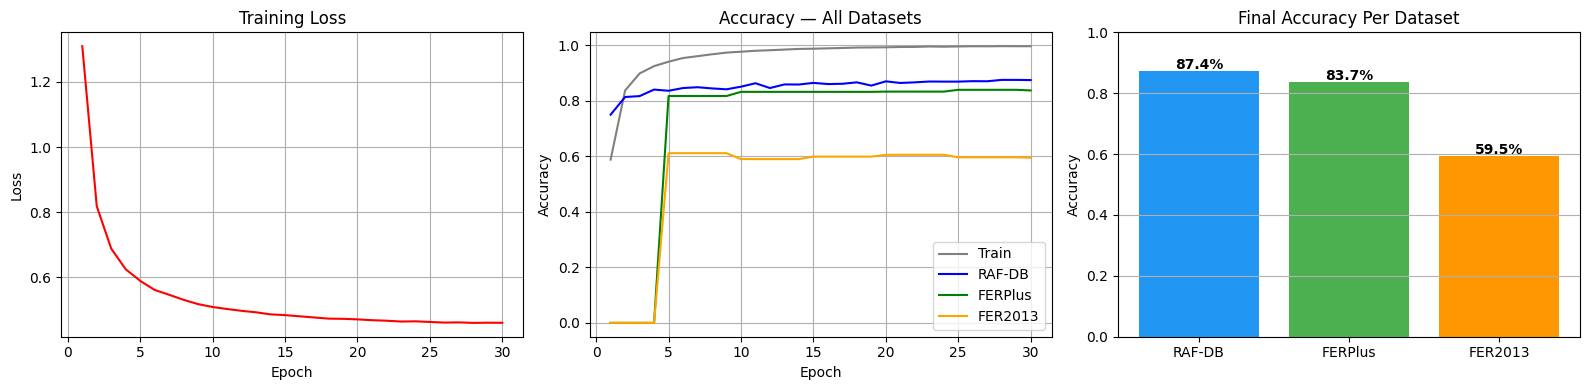

In [26]:
epochs_x = range(1, EPOCHS + 1)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs_x, history["train_loss"], color='red')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs_x, history["train_acc"],   label="Train",   color='gray')
plt.plot(epochs_x, history["rafdb_acc"],   label="RAF-DB",  color='blue')
plt.plot(epochs_x, history["ferplus_acc"], label="FERPlus", color='green')
plt.plot(epochs_x, history["fer2013_acc"], label="FER2013", color='orange')
plt.title("Accuracy — All Datasets")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
final_accs = [
    history["rafdb_acc"][-1],
    history["ferplus_acc"][-1],
    history["fer2013_acc"][-1]
]
dataset_names = ["RAF-DB", "FERPlus", "FER2013"]
colors = ["#2196F3", "#4CAF50", "#FF9800"]

bars = plt.bar(dataset_names, final_accs, color=colors)
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{acc*100:.1f}%", ha='center', fontweight='bold')

plt.title("Final Accuracy Per Dataset")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True, axis='y')

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


DATASET: RAF-DB
Accuracy: 87.48%
+--------------+-------------+----------+------------+-------------+
|              |   precision |   recall |   f1-score |     support |
|--------------+-------------+----------+------------+-------------|
| angry        |    0.825    | 0.814815 |   0.819876 |  162        |
| disgust      |    0.700787 | 0.55625  |   0.620209 |  160        |
| fear         |    0.75     | 0.608108 |   0.671642 |   74        |
| happy        |    0.954315 | 0.951899 |   0.953105 | 1185        |
| neutral      |    0.823204 | 0.876471 |   0.849003 |  680        |
| sad          |    0.831663 | 0.868201 |   0.849539 |  478        |
| surprise     |    0.882911 | 0.848024 |   0.865116 |  329        |
| accuracy     |    0.874837 | 0.874837 |   0.874837 |    0.874837 |
| macro avg    |    0.823983 | 0.78911  |   0.80407  | 3068        |
| weighted avg |    0.873511 | 0.874837 |   0.873276 | 3068        |
+--------------+-------------+----------+------------+-------------+


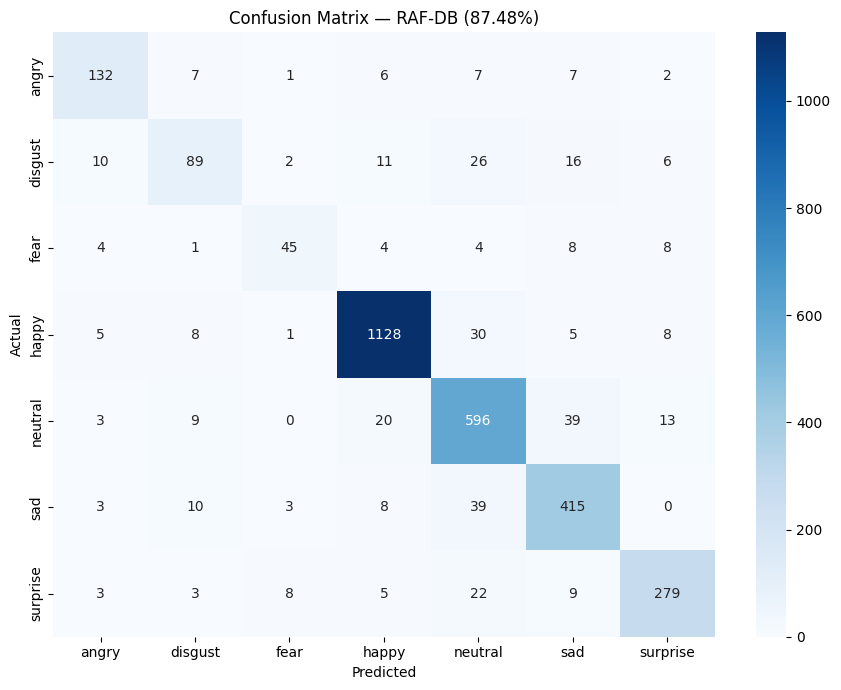


DATASET: FERPlus
Accuracy: 83.60%
+--------------+-------------+----------+------------+-------------+
|              |   precision |   recall |   f1-score |     support |
|--------------+-------------+----------+------------+-------------|
| angry        |    0.796875 | 0.791925 |   0.794393 |  322        |
| disgust      |    0.625    | 0.47619  |   0.540541 |   21        |
| fear         |    0.649123 | 0.377551 |   0.477419 |   98        |
| happy        |    0.927724 | 0.925727 |   0.926724 |  929        |
| neutral      |    0.831378 | 0.89011  |   0.859742 | 1274        |
| sad          |    0.715711 | 0.639198 |   0.675294 |  449        |
| surprise     |    0.827511 | 0.842222 |   0.834802 |  450        |
| accuracy     |    0.836015 | 0.836015 |   0.836015 |    0.836015 |
| macro avg    |    0.767617 | 0.706132 |   0.729845 | 3543        |
| weighted avg |    0.832091 | 0.836015 |   0.832356 | 3543        |
+--------------+-------------+----------+------------+-------------+

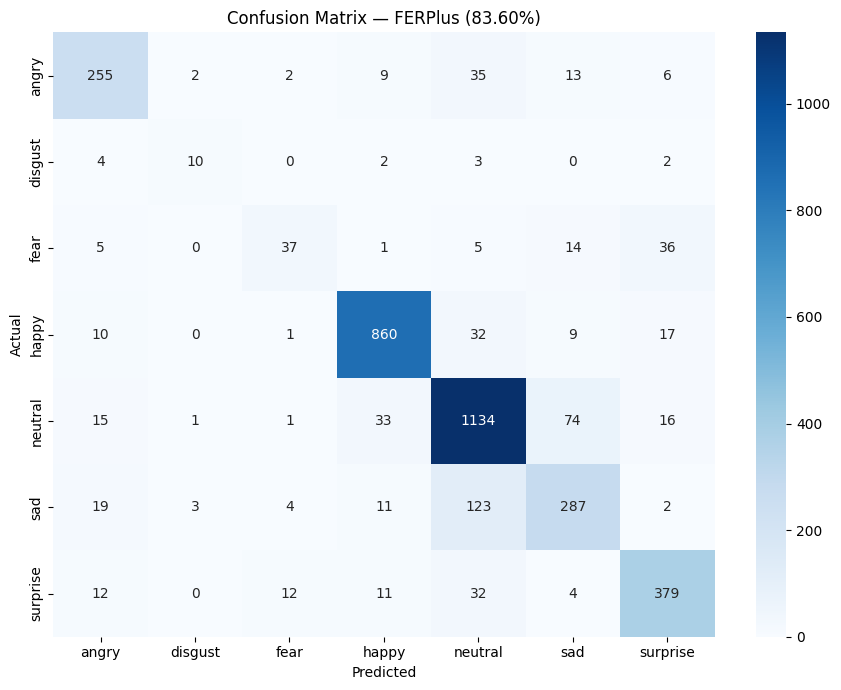


DATASET: FER2013
Accuracy: 59.43%
+--------------+-------------+-----------+------------+-------------+
|              |   precision |    recall |   f1-score |     support |
|--------------+-------------+-----------+------------+-------------|
| angry        |    0.71875  | 0.43215   |   0.539765 |  958        |
| disgust      |    0.707317 | 0.261261  |   0.381579 |  111        |
| fear         |    0.798246 | 0.0888672 |   0.15993  | 1024        |
| happy        |    0.866159 | 0.897407  |   0.881506 | 1774        |
| neutral      |    0.37234  | 0.879968  |   0.52327  | 1233        |
| sad          |    0.516644 | 0.311147  |   0.388388 | 1247        |
| surprise     |    0.706568 | 0.802647  |   0.751549 |  831        |
| accuracy     |    0.594316 | 0.594316  |   0.594316 |    0.594316 |
| macro avg    |    0.669432 | 0.524778  |   0.517998 | 7178        |
| weighted avg |    0.670319 | 0.594316  |   0.562979 | 7178        |
+--------------+-------------+-----------+------------+

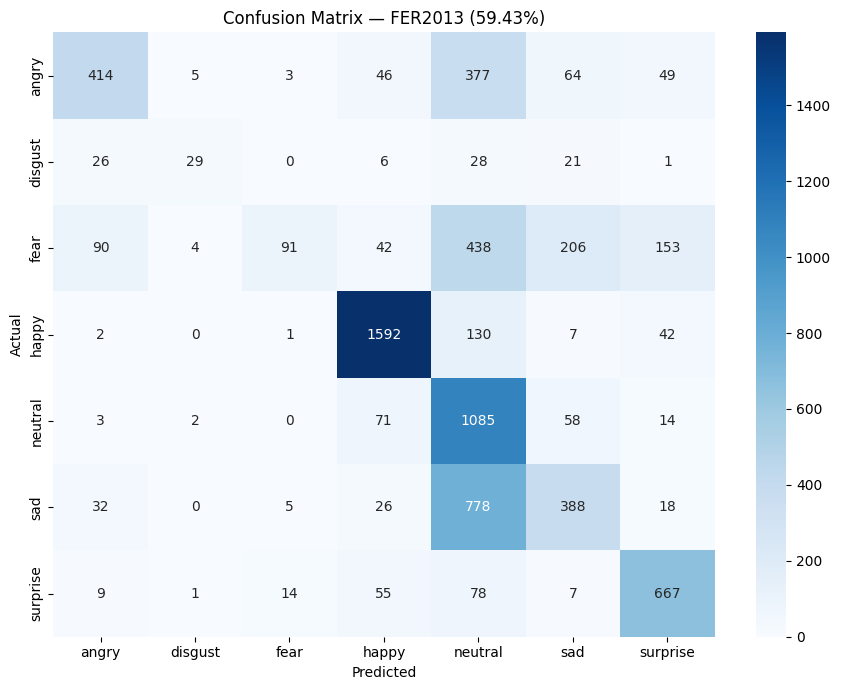


CROSS-DATASET RESULTS — RESEARCH PAPER TABLE
+-----------+------------+--------------------+
| Dataset   | Accuracy   | Role               |
|-----------+------------+--------------------|
| RAF-DB    | 87.48%     | Primary dataset    |
| FERPlus   | 83.60%     | Secondary dataset  |
| FER2013   | 59.43%     | Baseline benchmark |
+-----------+------------+--------------------+


In [27]:
base_model = EmotionModel(num_classes=NUM_CLASSES).to(device)
base_model.load_state_dict(
    torch.load("best_emotion_model.pth", map_location=device)
)
base_model.eval()

def full_evaluation(model, loader, dataset_name):
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            images = gpu_test_transform(images)
            preds  = torch.argmax(model(images), 1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    accuracy   = np.mean(all_preds == all_labels)

    print(f"\n{'='*55}")
    print(f"DATASET: {dataset_name}")
    print(f"{'='*55}")
    print(f"Accuracy: {accuracy*100:.2f}%")

    report = classification_report(
        all_labels, all_preds,
        target_names=CLASSES,
        output_dict=True
    )
    df = pd.DataFrame(report).transpose()
    print(tabulate(df, headers='keys', tablefmt='psql'))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"Confusion Matrix — {dataset_name} ({accuracy*100:.2f}%)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(
        f"cm_{dataset_name.lower().replace('-','').replace(' ','')}.png",
        dpi=150
    )
    plt.show()

    return accuracy

acc_rafdb   = full_evaluation(base_model, rafdb_test_loader,   "RAF-DB")
acc_ferplus = full_evaluation(base_model, ferplus_test_loader, "FERPlus")
acc_fer2013 = full_evaluation(base_model, fer2013_test_loader, "FER2013")

print("\n" + "="*55)
print("CROSS-DATASET RESULTS — RESEARCH PAPER TABLE")
print("="*55)

summary = [
    ["RAF-DB",  f"{acc_rafdb*100:.2f}%",   "Primary dataset"],
    ["FERPlus", f"{acc_ferplus*100:.2f}%", "Secondary dataset"],
    ["FER2013", f"{acc_fer2013*100:.2f}%", "Baseline benchmark"],
]
print(tabulate(summary,
               headers=["Dataset", "Accuracy", "Role"],
               tablefmt='psql'))

In [28]:
base_model.eval()
sample_images, _ = next(iter(rafdb_test_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    sample_images = gpu_test_transform(sample_images)
    embeddings = base_model.get_embedding(sample_images)
    logits = base_model(sample_images)

print("="*55)
print("MULTIMODAL FUSION READINESS")
print("="*55)
print(f"Input shape     : {sample_images.shape}")
print(f"Embedding shape : {embeddings.shape}  <-- for fusion")
print(f"Output shape    : {logits.shape}")
print()
print("Fusion blueprint for next phase:")
print("  emotion_emb  = emotion_model.get_embedding(face)    [B, 768]")
print("  gesture_emb  = gesture_model.get_embedding(hand)    [B, N]")
print("  scene_emb    = scene_model.get_embedding(scene)     [B, M]")
print("  health_emb   = health_model.get_embedding(signal)   [B, K]")
print("  fused        = torch.cat([all embeddings], dim=1)   [B, 768+N+M+K]")
print("  output       = fusion_head(fused)                   [B, 7]")

MULTIMODAL FUSION READINESS
Input shape     : torch.Size([64, 3, 224, 224])
Embedding shape : torch.Size([64, 768])  <-- for fusion
Output shape    : torch.Size([64, 7])

Fusion blueprint for next phase:
  emotion_emb  = emotion_model.get_embedding(face)    [B, 768]
  gesture_emb  = gesture_model.get_embedding(hand)    [B, N]
  scene_emb    = scene_model.get_embedding(scene)     [B, M]
  health_emb   = health_model.get_embedding(signal)   [B, K]
  fused        = torch.cat([all embeddings], dim=1)   [B, 768+N+M+K]
  output       = fusion_head(fused)                   [B, 7]


In [1]:
# Places365

In [25]:
# ============================================================
# CELL 1 — SYSTEM CHECK
# ============================================================
import sys
import torch

print("=" * 60)
print("SYSTEM CHECK")
print("=" * 60)
print(f"Python : {sys.executable}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM   : {vram:.2f} GB")
    x = torch.randn(100, 100, device="cuda")
    _ = x @ x
    print("Compute: PASSED ✅")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

SYSTEM CHECK
Python : /home/btech02_06/pytorch_env/bin/python3
PyTorch: 2.9.1+cu128
CUDA   : True
GPU    : NVIDIA RTX 4000 Ada Generation
VRAM   : 19.54 GB
Compute: PASSED ✅
Device : cuda


In [26]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import kornia.augmentation as K
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from collections import Counter
from tqdm import tqdm
import os
import json
import time

print("All imports successful ✅")

All imports successful ✅


In [27]:
# ============================================================
# CELL 3 — CREATE FILTERED DATASET (RUN ONCE ONLY)
# ============================================================
# Uses symlinks — no disk space wasted, instant creation.
# After running once, skip this cell in future runs.

SOURCE_TRAIN = "/home/btech02_06/emotion_project/datasets/places365/train"
SOURCE_VAL   = "/home/btech02_06/emotion_project/datasets/places365/val"

FILTERED_TRAIN = "/home/btech02_06/emotion_project/datasets/places365_filtered/train"
FILTERED_VAL   = "/home/btech02_06/emotion_project/datasets/places365_filtered/val"

KEEP_CLASSES = [
    # ── Healthcare (direct) ──
    'bathroom', 'bedroom', 'childs_room', 'clean_room', 'corridor',
    'hospital', 'hospital_room', 'kitchen', 'living_room', 'nursery',
    'nursing_home', 'operating_room', 'pharmacy', 'reception', 'shower',
    'staircase', 'utility_room', 'veterinarians_office', 'waiting_room',

    # ── Indoor rooms (patient lives here) ──
    'alcove', 'attic', 'balcony-interior', 'basement', 'bedchamber',
    'bow_window-indoor', 'closet', 'dining_room', 'dorm_room',
    'dressing_room', 'home_office', 'home_theater', 'hotel_room',
    'jacuzzi-indoor', 'locker_room', 'pantry', 'patio', 'playroom',
    'porch', 'recreation_room', 'sauna', 'storage_room',
    'television_room', 'wet_bar', 'yard',

    # ── Building infrastructure (robot navigates) ──
    'atrium-public', 'elevator-door', 'elevator_lobby', 'elevator_shaft',
    'entrance_hall', 'escalator-indoor', 'fire_escape', 'garage-indoor',
    'garage-outdoor', 'lawn', 'lobby', 'mezzanine',
    'parking_garage-indoor', 'parking_garage-outdoor', 'parking_lot',
    'roof_garden', 'street',

    # ── Institutional (patient might visit) ──
    'archive', 'auditorium', 'biology_laboratory', 'bookstore',
    'cafeteria', 'chemistry_lab', 'church-indoor', 'classroom',
    'computer_room', 'conference_center', 'conference_room', 'courthouse',
    'dining_hall', 'drugstore', 'fire_station', 'gymnasium-indoor',
    'kindergarden_classroom', 'lecture_room', 'library-indoor',
    'martial_arts_gym', 'museum-indoor', 'natural_history_museum',
    'office', 'office_building', 'office_cubicles', 'physics_laboratory',
    'schoolhouse', 'science_museum', 'server_room',
    'shopping_mall-indoor', 'subway_station-platform',
    'swimming_pool-indoor',

    # ── Shops / food (daily life) ──
    'bakery-shop', 'beauty_salon', 'butchers_shop', 'candy_store',
    'clothing_store', 'coffee_shop', 'delicatessen', 'department_store',
    'fabric_store', 'fastfood_restaurant', 'florist_shop-indoor',
    'food_court', 'general_store-indoor', 'gift_shop', 'hardware_store',
    'ice_cream_parlor', 'jewelry_shop', 'laundromat', 'market-indoor',
    'pet_shop', 'pizzeria', 'restaurant', 'restaurant_kitchen',
    'shoe_shop', 'shopfront', 'supermarket', 'toyshop',

    # ── Transport (person encounters) ──
    'bus_interior', 'bus_station-indoor', 'car_interior', 'gas_station',
    'train_interior', 'train_station-platform',

    # ── Residential / outdoor (realistic context) ──
    'alley', 'apartment_building-outdoor', 'balcony-exterior',
    'building_facade', 'campus', 'construction_site', 'courtyard',
    'crosswalk', 'doorway-outdoor', 'downtown', 'driveway', 'house',
    'mansion', 'park', 'picnic_area', 'playground', 'plaza',
    'promenade', 'residential_neighborhood', 'skyscraper', 'ticket_booth',
]

print(f"Classes to keep: {len(KEEP_CLASSES)}")

created = 0
skipped = 0
missing = 0

for src_dir, dst_dir in [(SOURCE_TRAIN, FILTERED_TRAIN),
                          (SOURCE_VAL, FILTERED_VAL)]:
    os.makedirs(dst_dir, exist_ok=True)
    for cls in KEEP_CLASSES:
        src = os.path.join(src_dir, cls)
        dst = os.path.join(dst_dir, cls)

        if not os.path.exists(src):
            print(f"  ⚠️  MISSING: {cls}")
            missing += 1
            continue
        if os.path.exists(dst):
            skipped += 1
            continue

        os.symlink(src, dst)
        created += 1

print(f"\nCreated : {created}")
print(f"Skipped : {skipped}")
print(f"Missing : {missing}")

# Verify
t = sorted(os.listdir(FILTERED_TRAIN))
v = sorted(os.listdir(FILTERED_VAL))
print(f"\nFiltered train classes: {len(t)}")
print(f"Filtered val classes  : {len(v)}")
print("✅ Filtered dataset ready!")

Classes to keep: 147

Created : 294
Skipped : 0
Missing : 0

Filtered train classes: 147
Filtered val classes  : 147
✅ Filtered dataset ready!


In [28]:
# ============================================================
# CELL 4 — CONFIGURATION
# ============================================================
PLACES_TRAIN = "/home/btech02_06/emotion_project/datasets/places365_filtered/train"
PLACES_VAL   = "/home/btech02_06/emotion_project/datasets/places365_filtered/val"

print("Train exists:", os.path.exists(PLACES_TRAIN))
print("Val exists  :", os.path.exists(PLACES_VAL))

train_classes = sorted(os.listdir(PLACES_TRAIN))
val_classes   = sorted(os.listdir(PLACES_VAL))

assert train_classes == val_classes, "❌ Train/Val class mismatch!"

NUM_CLASSES   = len(train_classes)
EMBEDDING_DIM = 512
BATCH_SIZE    = 64
EPOCHS        = 40
PATIENCE      = 10

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"\n{'='*60}")
print(f"NUM_CLASSES   : {NUM_CLASSES}")
print(f"EMBEDDING_DIM : {EMBEDDING_DIM}")
print(f"BATCH_SIZE    : {BATCH_SIZE}")
print(f"EPOCHS        : {EPOCHS}")
print(f"PATIENCE      : {PATIENCE}")
print(f"{'='*60}")

print(f"\nAll {NUM_CLASSES} scene classes:")
for i, c in enumerate(train_classes):
    print(f"  {i:3d}: {c}")

Train exists: True
Val exists  : True

NUM_CLASSES   : 147
EMBEDDING_DIM : 512
BATCH_SIZE    : 64
EPOCHS        : 40
PATIENCE      : 10

All 147 scene classes:
    0: alcove
    1: alley
    2: apartment_building-outdoor
    3: archive
    4: atrium-public
    5: attic
    6: auditorium
    7: bakery-shop
    8: balcony-exterior
    9: balcony-interior
   10: basement
   11: bathroom
   12: beauty_salon
   13: bedchamber
   14: bedroom
   15: biology_laboratory
   16: bookstore
   17: bow_window-indoor
   18: building_facade
   19: bus_interior
   20: bus_station-indoor
   21: butchers_shop
   22: cafeteria
   23: campus
   24: candy_store
   25: car_interior
   26: chemistry_lab
   27: childs_room
   28: church-indoor
   29: classroom
   30: clean_room
   31: closet
   32: clothing_store
   33: coffee_shop
   34: computer_room
   35: conference_center
   36: conference_room
   37: construction_site
   38: corridor
   39: courthouse
   40: courtyard
   41: crosswalk
   42: delicatessen

In [29]:
# ============================================================
# CELL 5 — TRANSFORMS & DATASET LOADING
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((256, 256),
        interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256),
        interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

print("Transforms defined")
print("Train: Resize256 → RRC224 → HFlip → ColorJitter → RandGray → Tensor")
print("Val  : Resize256 → CenterCrop224 → Tensor")

print("\nLoading train dataset...")
t0 = time.time()
train_dataset = ImageFolder(PLACES_TRAIN, transform=train_transform)
print(f"  Train: {len(train_dataset)} samples ({time.time()-t0:.1f}s)")

print("Loading val dataset...")
t0 = time.time()
val_dataset = ImageFolder(PLACES_VAL, transform=val_transform)
print(f"  Val  : {len(val_dataset)} samples ({time.time()-t0:.1f}s)")

SCENE_CLASSES = train_dataset.classes

# Quick distribution check
train_counts = Counter(train_dataset.targets)
print(f"\nSamples per class (train): min={min(train_counts.values())}, "
      f"max={max(train_counts.values())}, "
      f"mean={np.mean(list(train_counts.values())):.0f}")

print(f"Total train: {len(train_dataset)}")
print(f"Total val  : {len(val_dataset)}")

Transforms defined
Train: Resize256 → RRC224 → HFlip → ColorJitter → RandGray → Tensor
Val  : Resize256 → CenterCrop224 → Tensor

Loading train dataset...
  Train: 719494 samples (2.2s)
Loading val dataset...
  Val  : 14700 samples (0.1s)

Samples per class (train): min=3068, max=5000, mean=4895
Total train: 719494
Total val  : 14700


Train batches: 11242
Val batches  : 230

Batch check:
  Images: torch.Size([64, 3, 224, 224]) [0.000, 1.000]
  Labels: torch.Size([64])


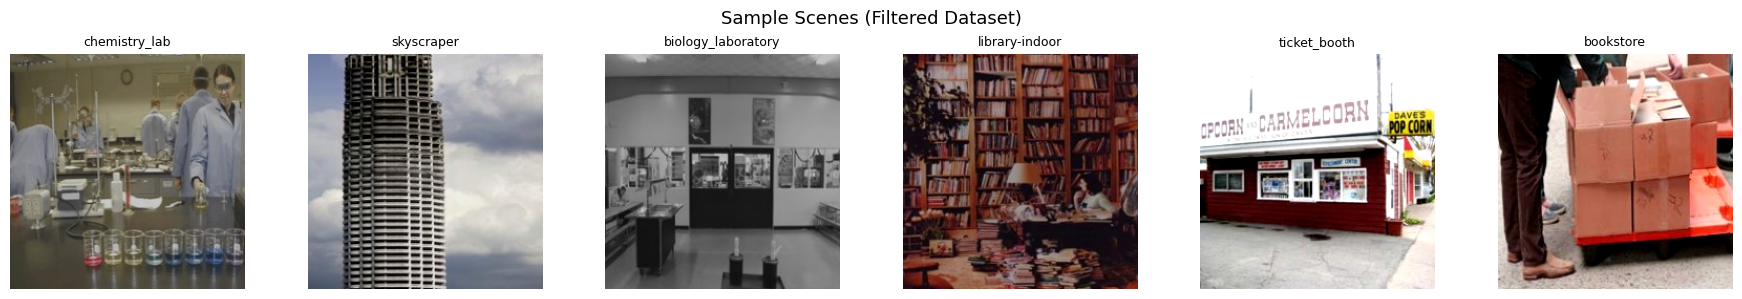

✅ DataLoaders ready


In [30]:
# ============================================================
# CELL 6 — DATALOADERS & VERIFICATION
# ============================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=False,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

images, labels = next(iter(train_loader))
print(f"\nBatch check:")
print(f"  Images: {images.shape} [{images.min():.3f}, {images.max():.3f}]")
print(f"  Labels: {labels.shape}")

# Visualize
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i in range(6):
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(SCENE_CLASSES[labels[i].item()][:20], fontsize=9)
    axes[i].axis('off')
plt.suptitle("Sample Scenes (Filtered Dataset)", fontsize=13)
plt.tight_layout()
plt.savefig("sample_scenes_filtered.png", dpi=150)
plt.show()
print("✅ DataLoaders ready")

In [31]:
# ============================================================
# CELL 7 — MODEL ARCHITECTURE
# ============================================================

class EnvironmentModel(nn.Module):
    """
    Environment / Context Recognition Model v2 (Filtered)

    Backbone  : ResNet-50 (ImageNet V2 pretrained)
    Embedding : 512-d for multimodal fusion
    Freezing  : stem + layer1 only (more adaptation than v1)

    Changes from v1:
        - Filtered to ~140 relevant scene classes
        - Less freezing (stem+layer1 vs stem+layer1+layer2)
        - Deeper embedding head (2048→1024→512)
        - Better regularization

    Usage:
        emb = model.get_embedding(x)  → [B, 512]
        out = model(x)                → [B, num_classes]
    """

    def __init__(self, num_classes, embedding_dim=512):
        super().__init__()

        backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2
        )

        # Everything except final FC
        self.features = nn.Sequential(*list(backbone.children())[:-1])

        # Freeze: conv1 → bn1 → relu → maxpool → layer1
        # Trainable: layer2, layer3, layer4, avgpool
        ct = 0
        for child in self.features.children():
            ct += 1
            if ct <= 5:
                for p in child.parameters():
                    p.requires_grad = False

        # Deeper embedding head: 2048 → 1024 → 512
        self.embedding_head = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(1024, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.GELU(),
            nn.Dropout(0.3),
        )

        # Classifier: 512 → 256 → num_classes
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

        self.embedding_dim = embedding_dim

    def get_embedding(self, x):
        """Extract 512-d embedding for multimodal fusion."""
        x = self.features(x)        # [B, 2048, 1, 1]
        x = torch.flatten(x, 1)     # [B, 2048]
        x = self.embedding_head(x)  # [B, 512]
        return x

    def forward(self, x):
        emb = self.get_embedding(x)
        return self.classifier(emb)


model = EnvironmentModel(
    num_classes=NUM_CLASSES,
    embedding_dim=EMBEDDING_DIM
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

print("=" * 60)
print("ENVIRONMENT MODEL v2 (Filtered)")
print("=" * 60)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Frozen params   : {frozen:,}")
print(f"Freeze ratio    : {frozen/total*100:.1f}%")
print(f"Num classes     : {NUM_CLASSES}")
print(f"Embedding dim   : {model.embedding_dim}")

# Quick test
with torch.no_grad():
    dummy = torch.randn(4, 3, 224, 224).to(device)
    logits = model(dummy)
    emb = model.get_embedding(dummy)

print(f"\nForward pass test:")
print(f"  Input     : {dummy.shape}")
print(f"  Logits    : {logits.shape}")
print(f"  Embedding : {emb.shape}")
assert logits.shape == (4, NUM_CLASSES)
assert emb.shape == (4, EMBEDDING_DIM)
print("  ✅ Verified!")

ENVIRONMENT MODEL v2 (Filtered)
Total params    : 26,303,699
Trainable params: 26,078,355
Frozen params   : 225,344
Freeze ratio    : 0.9%
Num classes     : 147
Embedding dim   : 512

Forward pass test:
  Input     : torch.Size([4, 3, 224, 224])
  Logits    : torch.Size([4, 147])
  Embedding : torch.Size([4, 512])
  ✅ Verified!


In [32]:
# ============================================================
# CELL 8 — GPU TRANSFORMS & TRAINING CONFIG
# ============================================================

gpu_train_transform = K.Normalize(
    mean=torch.tensor(IMAGENET_MEAN),
    std=torch.tensor(IMAGENET_STD)
).to(device)

gpu_val_transform = K.Normalize(
    mean=torch.tensor(IMAGENET_MEAN),
    std=torch.tensor(IMAGENET_STD)
).to(device)

print("GPU transforms: normalize only ✅")

# ── Loss ──
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Optimizer (differential LR) ──
optimizer = torch.optim.AdamW([
    {"params": [p for p in model.features.parameters() if p.requires_grad],
     "lr": 5e-5},
    {"params": model.embedding_head.parameters(), "lr": 3e-4},
    {"params": model.classifier.parameters(),     "lr": 3e-4},
], weight_decay=1e-4)

# ── Scheduler: 3-epoch warmup + cosine decay ──
warmup_epochs = 3
warmup_sched = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, total_iters=warmup_epochs
)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - warmup_epochs, eta_min=1e-6
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_sched, cosine_sched],
    milestones=[warmup_epochs]
)

# ── Mixed precision ──
scaler = torch.amp.GradScaler("cuda")

print(f"\n{'='*60}")
print("TRAINING CONFIG")
print(f"{'='*60}")
print(f"Loss        : CrossEntropyLoss(label_smoothing=0.1)")
print(f"Optimizer   : AdamW (wd=1e-4)")
print(f"Backbone LR : 5e-5 (layer2–4 trainable)")
print(f"Head LR     : 3e-4")
print(f"Scheduler   : LinearWarmup(3ep) → CosineAnnealing")
print(f"Epochs      : {EPOCHS}")
print(f"Patience    : {PATIENCE}")
print(f"AMP         : enabled")
print(f"Grad clip   : 1.0")

GPU transforms: normalize only ✅

TRAINING CONFIG
Loss        : CrossEntropyLoss(label_smoothing=0.1)
Optimizer   : AdamW (wd=1e-4)
Backbone LR : 5e-5 (layer2–4 trainable)
Head LR     : 3e-4
Scheduler   : LinearWarmup(3ep) → CosineAnnealing
Epochs      : 40
Patience    : 10
AMP         : enabled
Grad clip   : 1.0


In [33]:
# ============================================================
# CELL 9 — TRAINING & EVALUATION FUNCTIONS
# ============================================================

def train_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="  Train", leave=True)

    for idx, (images, labels) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        images = gpu_train_transform(images)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (idx + 1) % 100 == 0 or idx == len(loader) - 1:
            pbar.set_postfix(
                loss=f"{running_loss/(idx+1):.4f}",
                acc=f"{correct/total:.4f}"
            )

    return running_loss / len(loader), correct / total


def evaluate(model, loader, desc="  Val"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    top5_correct = 0

    pbar = tqdm(loader, desc=desc, leave=True)

    with torch.no_grad():
        for idx, (images, labels) in enumerate(pbar):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            images = gpu_val_transform(images)

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            _, top5 = outputs.topk(5, dim=1)
            for i in range(labels.size(0)):
                if labels[i] in top5[i]:
                    top5_correct += 1

            pbar.set_postfix(
                loss=f"{running_loss/(idx+1):.4f}",
                top1=f"{correct/total:.4f}",
                top5=f"{top5_correct/total:.4f}"
            )

    return running_loss / len(loader), correct / total, top5_correct / total


print("Functions ready ✅")

Functions ready ✅


In [34]:
# ============================================================
# CELL 10 — TRAINING LOOP
# ============================================================

best_val_acc  = 0.0
best_val_top5 = 0.0
no_improve    = 0

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [], "val_top5": [],
    "lr": []
}

total_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    lr_now = optimizer.param_groups[0]["lr"]

    print(f"\n{'='*70}")
    print(f"EPOCH {epoch+1}/{EPOCHS}  |  LR: {lr_now:.7f}")
    print(f"{'='*70}")

    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc, val_top5 = evaluate(model, val_loader)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_top5"].append(val_top5)
    history["lr"].append(lr_now)

    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc  = val_acc
        best_val_top5 = val_top5
        torch.save(model.state_dict(), "best_environment_model.pth")
        no_improve = 0
    else:
        no_improve += 1

    elapsed   = time.time() - epoch_start
    total_t   = time.time() - total_start
    remaining = (total_t / (epoch + 1)) * (EPOCHS - epoch - 1)

    tag = "🏆 NEW BEST!" if is_best else ""
    print(f"\n📊 Epoch {epoch+1:02d} | "
          f"Train {train_acc*100:.2f}% ({train_loss:.4f}) | "
          f"Val {val_acc*100:.2f}% ({val_loss:.4f}) | "
          f"Top5 {val_top5*100:.2f}% {tag}")
    print(f"⏱️  {elapsed/60:.1f}m this epoch | "
          f"{total_t/60:.1f}m total | "
          f"~{remaining/60:.1f}m left | "
          f"Best {best_val_acc*100:.2f}%")

    if no_improve > 0 and not is_best:
        print(f"⚠️  No improvement {no_improve}/{PATIENCE}")

    if no_improve >= PATIENCE:
        print(f"\n🛑 Early stopping at epoch {epoch+1}")
        break

total_t = time.time() - total_start
print(f"\n{'='*70}")
print(f"🎉 TRAINING COMPLETE!")
print(f"Best Top-1 : {best_val_acc*100:.2f}%")
print(f"Best Top-5 : {best_val_top5*100:.2f}%")
print(f"Total time : {total_t/60:.1f} min ({total_t/3600:.1f} h)")
print(f"{'='*70}")


EPOCH 1/40  |  LR: 0.0000050


  Train: 100%|███| 11242/11242 [41:11<00:00,  4.55it/s, acc=0.3849, loss=3.0083]
  Val: 100%|█| 230/230 [00:13<00:00, 16.69it/s, loss=2.3698, top1=0.5044, top5=0



📊 Epoch 01 | Train 38.49% (3.0083) | Val 50.44% (2.3698) | Top5 83.22% 🏆 NEW BEST!
⏱️  41.4m this epoch | 41.4m total | ~1615.5m left | Best 50.44%

EPOCH 2/40  |  LR: 0.0000200


  Train: 100%|███| 11242/11242 [38:47<00:00,  4.83it/s, acc=0.5050, loss=2.4058]
  Val: 100%|█| 230/230 [00:18<00:00, 12.42it/s, loss=2.2075, top1=0.5538, top5=0



📊 Epoch 02 | Train 50.50% (2.4058) | Val 55.38% (2.2075) | Top5 86.55% 🏆 NEW BEST!
⏱️  39.1m this epoch | 80.5m total | ~1530.1m left | Best 55.38%

EPOCH 3/40  |  LR: 0.0000350


...


📊 Epoch 16 | Train 70.74% (1.7260) | Val 57.51% (2.2027) | Top5 87.41% 
⏱️  38.3m this epoch | 604.6m total | ~906.9m left | Best 58.38%
⚠️  No improvement 8/10

EPOCH 17/40  |  LR: 0.0000365


  Val: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 230/230 [00:13<00:00, 17.11it/s, loss=2.2267, top1=0.5718, top5=0.8720]



📊 Epoch 17 | Train 71.78% (1.6950) | Val 57.18% (2.2267) | Top5 87.20% 
⏱️  37.0m this epoch | 641.6m total | ~868.1m left | Best 58.38%
⚠️  No improvement 9/10

EPOCH 18/40  |  LR: 0.0000346


  Val: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 230/230 [00:18<00:00, 12.68it/s, loss=2.2354, top1=0.5719, top5=0.8705]


📊 Epoch 18 | Train 72.84% (1.6641) | Val 57.19% (2.2354) | Top5 87.05% 
⏱️  35.9m this epoch | 677.5m total | ~828.1m left | Best 58.38%
⚠️  No improvement 10/10

🛑 Early stopping at epoch 18

🎉 TRAINING COMPLETE!
Best Top-1 : 58.38%
Best Top-5 : 87.97%
Total time : 677.5 min (11.3 h)


In [35]:
# ============================================================
# CELL 11 — SAVE ALL FILES
# ============================================================
model.eval()

torch.save(model.state_dict(), "environment_model_final_weights.pth")
torch.save(model, "environment_model_full.pth")

dummy = torch.randn(1, 3, 224, 224).to(device)
traced = torch.jit.trace(model, dummy)
traced.save("environment_model_scripted.pt")

config = {
    "branch": "environment",
    "version": "v2_filtered",
    "classes": SCENE_CLASSES,
    "num_classes": NUM_CLASSES,
    "embedding_dim": EMBEDDING_DIM,
    "input_size": 224,
    "mean": IMAGENET_MEAN,
    "std": IMAGENET_STD,
    "backbone": "resnet50",
    "best_val_top1": best_val_acc,
    "best_val_top5": best_val_top5,
    "epochs_trained": len(history["train_loss"]),
    "dataset": "places365_filtered",
}
with open("environment_model_config.json", "w") as f:
    json.dump(config, f, indent=2)

with open("environment_training_history.json", "w") as f:
    json.dump(history, f, indent=2)

print("All files saved:")
for f in ["best_environment_model.pth",
          "environment_model_final_weights.pth",
          "environment_model_full.pth",
          "environment_model_scripted.pt",
          "environment_model_config.json",
          "environment_training_history.json"]:
    print(f"  ✅ {f}")

All files saved:
  ✅ best_environment_model.pth
  ✅ environment_model_final_weights.pth
  ✅ environment_model_full.pth
  ✅ environment_model_scripted.pt
  ✅ environment_model_config.json
  ✅ environment_training_history.json


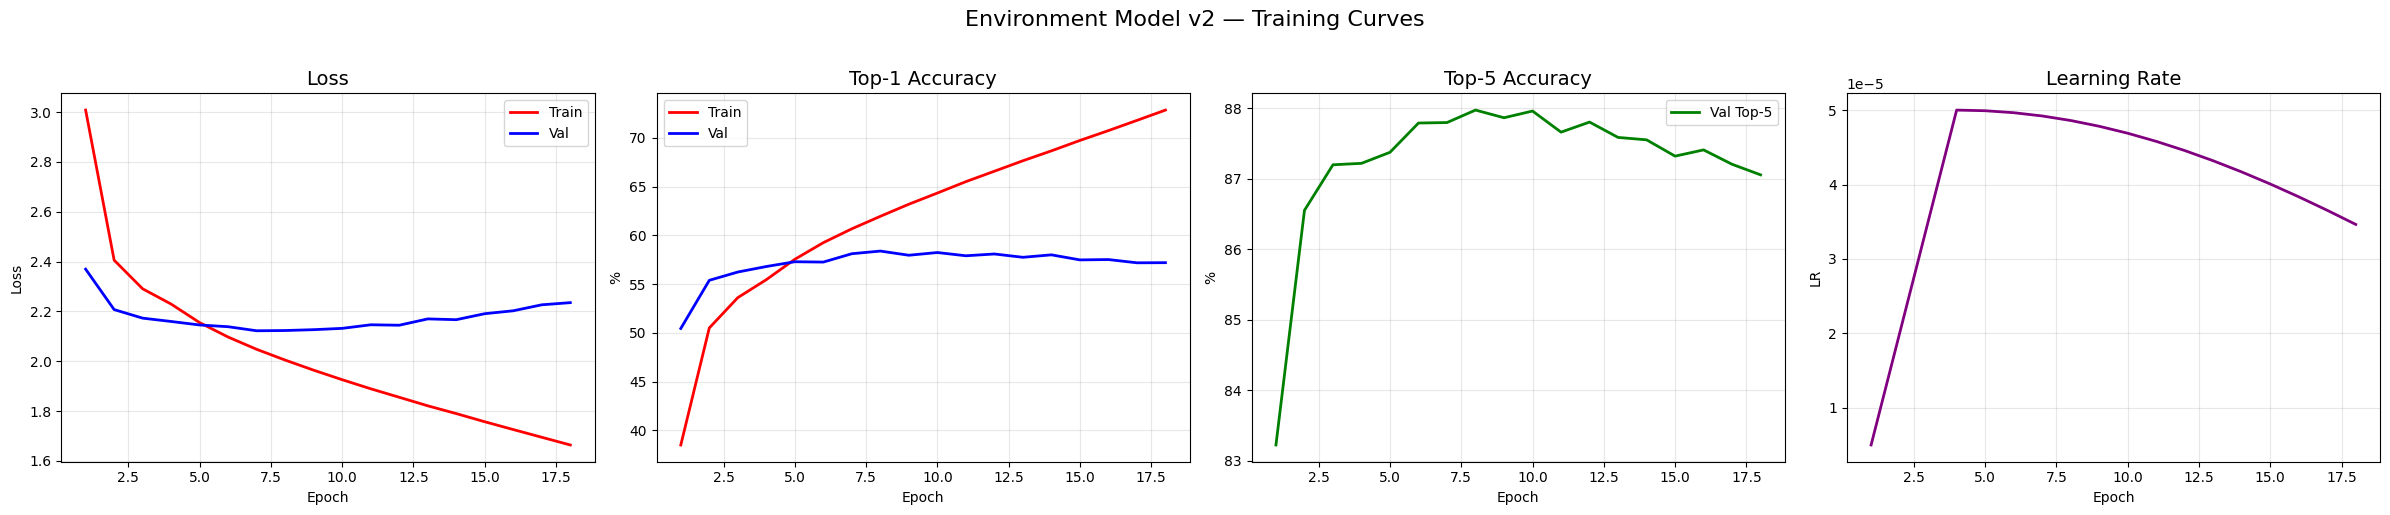

In [36]:
# ============================================================
# CELL 12 — TRAINING CURVES
# ============================================================
ep = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

axes[0].plot(ep, history["train_loss"], 'r-', lw=2, label="Train")
axes[0].plot(ep, history["val_loss"],   'b-', lw=2, label="Val")
axes[0].set_title("Loss", fontsize=14)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, [a*100 for a in history["train_acc"]], 'r-', lw=2, label="Train")
axes[1].plot(ep, [a*100 for a in history["val_acc"]],   'b-', lw=2, label="Val")
axes[1].set_title("Top-1 Accuracy", fontsize=14)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("%")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(ep, [a*100 for a in history["val_top5"]], 'g-', lw=2, label="Val Top-5")
axes[2].set_title("Top-5 Accuracy", fontsize=14)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("%")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

axes[3].plot(ep, history["lr"], 'purple', lw=2)
axes[3].set_title("Learning Rate", fontsize=14)
axes[3].set_xlabel("Epoch"); axes[3].set_ylabel("LR")
axes[3].grid(True, alpha=0.3)

plt.suptitle("Environment Model v2 — Training Curves", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("environment_training_curves_v2.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
# ============================================================
# CELL 13 — FULL EVALUATION (BEST MODEL)
# ============================================================
best_model = EnvironmentModel(
    num_classes=NUM_CLASSES,
    embedding_dim=EMBEDDING_DIM
).to(device)
best_model.load_state_dict(
    torch.load("best_environment_model.pth", map_location=device)
)
best_model.eval()
print("Best model loaded ✅")

all_preds  = []
all_labels = []
top5_hit   = 0
total_n    = 0

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Final Eval"):
        images = images.to(device)
        images = gpu_val_transform(images)
        with torch.amp.autocast("cuda"):
            out = best_model(images)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        _, t5 = out.topk(5, 1)
        lg = labels.to(device)
        for i in range(labels.size(0)):
            if lg[i] in t5[i]:
                top5_hit += 1
        total_n += labels.size(0)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
top1 = np.mean(all_preds == all_labels)
top5 = top5_hit / total_n

print(f"\n{'='*60}")
print(f"ENVIRONMENT MODEL v2 — FINAL RESULTS")
print(f"{'='*60}")
print(f"Top-1 Accuracy : {top1*100:.2f}%")
print(f"Top-5 Accuracy : {top5*100:.2f}%")
print(f"Classes        : {NUM_CLASSES}")
print(f"Embedding      : {EMBEDDING_DIM}")
print(f"Val samples    : {total_n}")

# ── Most confused pairs ──
print(f"\n{'='*60}")
print(f"TOP 15 MOST CONFUSED PAIRS")
print(f"{'='*60}")
cm = confusion_matrix(all_labels, all_preds)
cm2 = cm.copy(); np.fill_diagonal(cm2, 0)
pairs = []
for i in range(len(cm2)):
    for j in range(len(cm2)):
        if cm2[i][j] > 0:
            pairs.append((cm2[i][j], SCENE_CLASSES[i], SCENE_CLASSES[j]))
pairs.sort(reverse=True)
for cnt, tr, pr in pairs[:15]:
    print(f"  {tr:30s} → {pr:30s}  ({cnt}x)")

# ── Per-class accuracy ──
per_cls = {}
for idx in range(NUM_CLASSES):
    mask = all_labels == idx
    if mask.sum() > 0:
        per_cls[SCENE_CLASSES[idx]] = np.mean(all_preds[mask] == idx)

ranked = sorted(per_cls.items(), key=lambda x: x[1])

print(f"\n{'='*60}")
print(f"15 HARDEST CLASSES")
print(f"{'='*60}")
for n, a in ranked[:15]:
    print(f"  {n:30s}: {a*100:.1f}%")

print(f"\n{'='*60}")
print(f"15 EASIEST CLASSES")
print(f"{'='*60}")
for n, a in ranked[-15:]:
    print(f"  {n:30s}: {a*100:.1f}%")

# ── Healthcare-critical classes ──
print(f"\n{'='*60}")
print(f"HEALTHCARE-CRITICAL CLASSES")
print(f"{'='*60}")
hc = ['bathroom', 'bedroom', 'corridor', 'hospital', 'hospital_room',
      'kitchen', 'living_room', 'nursery', 'nursing_home',
      'operating_room', 'pharmacy', 'reception', 'shower',
      'staircase', 'waiting_room']
for c in hc:
    if c in per_cls:
        a = per_cls[c]
        s = "✅" if a >= 0.5 else "⚠️"
        print(f"  {s} {c:25s}: {a*100:.1f}%")

Best model loaded ✅


Final Eval: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 230/230 [00:18<00:00, 12.58it/s]



ENVIRONMENT MODEL v2 — FINAL RESULTS
Top-1 Accuracy : 58.38%
Top-5 Accuracy : 87.97%
Classes        : 147
Embedding      : 512
Val samples    : 14700

TOP 15 MOST CONFUSED PAIRS
  biology_laboratory             → chemistry_lab                   (26x)
  shower                         → bathroom                        (24x)
  laundromat                     → utility_room                    (24x)
  chemistry_lab                  → biology_laboratory              (24x)
  train_interior                 → bus_interior                    (23x)
  science_museum                 → natural_history_museum          (23x)
  classroom                      → lecture_room                    (23x)
  skyscraper                     → downtown                        (21x)
  jacuzzi-indoor                 → swimming_pool-indoor            (20x)
  cafeteria                      → dining_hall                     (20x)
  hardware_store                 → supermarket                     (19x)
  drugstore       

In [38]:
# ============================================================
# CELL 14 — FUSION READINESS CHECK
# ============================================================
best_model.eval()

imgs, _ = next(iter(val_loader))
imgs = imgs.to(device)

with torch.no_grad():
    imgs_n = gpu_val_transform(imgs)
    emb    = best_model.get_embedding(imgs_n)
    logits = best_model(imgs_n)

print("=" * 60)
print("MULTIMODAL FUSION READINESS — ENVIRONMENT BRANCH v2")
print("=" * 60)
print(f"Input shape     : {imgs.shape}")
print(f"Embedding shape : {emb.shape}   ← for fusion")
print(f"Output shape    : {logits.shape}")
print(f"Embedding stats : mean={emb.mean():.4f}  std={emb.std():.4f}")
print()
print("All branches:")
print(f"  emotion_emb = [B, 768]  ✅ ConvNeXt-Small + CBAM")
print(f"  env_emb     = [B, 512]  ✅ ResNet-50, {NUM_CLASSES} filtered scenes")
print(f"  gesture_emb = [B, ???]  ⏳ pending")
print()
print("Fusion:")
print("  fused = torch.cat([emotion_emb, env_emb, gesture_emb], dim=1)")
print(f"  fused = [B, 768 + 512 + ???]")
print()
print("✅ Environment branch v2 complete and fusion-ready!")

MULTIMODAL FUSION READINESS — ENVIRONMENT BRANCH v2
Input shape     : torch.Size([64, 3, 224, 224])
Embedding shape : torch.Size([64, 512])   ← for fusion
Output shape    : torch.Size([64, 147])
Embedding stats : mean=0.1519  std=0.4803

All branches:
  emotion_emb = [B, 768]  ✅ ConvNeXt-Small + CBAM
  env_emb     = [B, 512]  ✅ ResNet-50, 147 filtered scenes
  gesture_emb = [B, ???]  ⏳ pending

Fusion:
  fused = torch.cat([emotion_emb, env_emb, gesture_emb], dim=1)
  fused = [B, 768 + 512 + ???]

✅ Environment branch v2 complete and fusion-ready!


In [42]:
##WESAD

In [1]:
# ============================================================
# CELL 1 — SYSTEM CHECK
# ============================================================
import sys
import torch

print("=" * 60)
print("HEALTH MONITORING BRANCH — SYSTEM CHECK")
print("=" * 60)
print(f"Python : {sys.executable}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM   : {vram:.2f} GB")
    x = torch.randn(100, 100, device="cuda")
    _ = x @ x
    print("Compute: PASSED ✅")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

HEALTH MONITORING BRANCH — SYSTEM CHECK
Python : /home/btech02_06/pytorch_env/bin/python3
PyTorch: 2.9.1+cu128
CUDA   : True
GPU    : NVIDIA RTX 4000 Ada Generation
VRAM   : 19.54 GB
Compute: PASSED ✅
Device : cuda


In [2]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================
import os
import json
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from math import gcd
from scipy.signal import resample_poly
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

print("All imports successful ✅")

All imports successful ✅


In [3]:
# ============================================================
# CELL 3 — CONFIGURATION (UPDATED FINAL)
# ============================================================

WESAD_PATH = "/home/btech02_06/emotion_project/datasets/wesad/WESAD"

# ── Classes ──
HEALTH_CLASSES = ['baseline', 'stress', 'amusement', 'meditation']
NUM_CLASSES    = 4

# WESAD raw label mapping
# 0 = transient, 1 = baseline, 2 = stress,
# 3 = amusement, 4 = meditation
# 5,6,7,8,-1 = unknown protocol labels → ignore
LABEL_MAP    = {1: 0, 2: 1, 3: 2, 4: 3}
VALID_LABELS = {1, 2, 3, 4}

# ── Sampling rates ──
ORIG_HZ = {
    'ACC' : 32,
    'BVP' : 64,
    'EDA' : 4,
    'TEMP': 4,
}
LABEL_HZ  = 700
TARGET_HZ = 4

# ── Windowing (UPDATED) ──
WINDOW_SEC    = 30             # reduced from 60 → more windows
STRIDE_SEC    = 15             # reduced from 30 → more windows
WINDOW_STEPS  = WINDOW_SEC  * TARGET_HZ   # 120
STRIDE_STEPS  = STRIDE_SEC  * TARGET_HZ   # 60
PURITY_THRESH = 0.70           # relaxed from 0.80 → more windows
BOUNDARY_DROP = 8              # reduced from 30 → saves more data
                               # = 2 seconds at 4Hz

# ── Channels ──
# ACCx, ACCy, ACCz, BVP, EDA, TEMP
NUM_CHANNELS  = 6
EMBEDDING_DIM = 512

# ── Training ──
BATCH_SIZE = 256
EPOCHS     = 50
PATIENCE   = 15

# ── Subject split ──
ALL_SUBJECTS   = ['S2','S3','S4','S5','S6','S7',
                  'S8','S9','S10','S11','S13',
                  'S14','S15','S16','S17']

TRAIN_SUBJECTS = ['S2','S3','S4','S5','S6',
                  'S7','S8','S9','S10','S11','S13']
VAL_SUBJECTS   = ['S14','S15','S16','S17']

print("=" * 60)
print("HEALTH MONITORING CONFIG (UPDATED FINAL)")
print("=" * 60)
print(f"Classes       : {HEALTH_CLASSES}")
print(f"Channels      : {NUM_CHANNELS}")
print(f"Target Hz     : {TARGET_HZ}")
print(f"Window        : {WINDOW_SEC}s = {WINDOW_STEPS} steps")
print(f"Stride        : {STRIDE_SEC}s = {STRIDE_STEPS} steps")
print(f"Purity thresh : {PURITY_THRESH}")
print(f"Boundary drop : {BOUNDARY_DROP} steps = "
      f"{BOUNDARY_DROP/TARGET_HZ:.1f}s")
print(f"Embedding dim : {EMBEDDING_DIM}")
print(f"Train subjects: {TRAIN_SUBJECTS}")
print(f"Val subjects  : {VAL_SUBJECTS}")

HEALTH MONITORING CONFIG (UPDATED FINAL)
Classes       : ['baseline', 'stress', 'amusement', 'meditation']
Channels      : 6
Target Hz     : 4
Window        : 30s = 120 steps
Stride        : 15s = 60 steps
Purity thresh : 0.7
Boundary drop : 8 steps = 2.0s
Embedding dim : 512
Train subjects: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13']
Val subjects  : ['S14', 'S15', 'S16', 'S17']


In [4]:
# ============================================================
# CELL 4 — PREPROCESSING FUNCTIONS (UPDATED FINAL)
# ============================================================

def safe_resample(signal, orig_hz, target_hz):
    """
    Resample signal using resample_poly with anti-aliasing.
    Works on 1D or 2D (T, C) arrays.
    """
    g    = gcd(target_hz, orig_hz)
    up   = target_hz // g
    down = orig_hz   // g

    if signal.ndim == 1:
        return resample_poly(signal, up, down).astype(np.float32)
    else:
        cols = [resample_poly(signal[:, i], up, down)
                for i in range(signal.shape[1])]
        return np.stack(cols, axis=1).astype(np.float32)


def load_subject(subject_id):
    """
    Load one subject pkl and extract wrist signals + labels.

    Returns:
        signals : np.ndarray [T, 6]  at TARGET_HZ
        labels  : np.ndarray [T]     at TARGET_HZ
    """
    pkl_path = os.path.join(
        WESAD_PATH, subject_id, f"{subject_id}.pkl"
    )
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    wrist  = data["signal"]["wrist"]
    labels = data["label"]

    # ── Resample each wrist signal to TARGET_HZ ──
    acc  = safe_resample(
        wrist["ACC"], ORIG_HZ["ACC"], TARGET_HZ
    )
    bvp  = safe_resample(
        wrist["BVP"].flatten(), ORIG_HZ["BVP"], TARGET_HZ
    )
    eda  = safe_resample(
        wrist["EDA"].flatten(), ORIG_HZ["EDA"], TARGET_HZ
    )
    temp = safe_resample(
        wrist["TEMP"].flatten(), ORIG_HZ["TEMP"], TARGET_HZ
    )

    # ── Resample labels from 700 Hz to TARGET_HZ ──
    lbl_resampled = safe_resample(
        labels.astype(np.float32), LABEL_HZ, TARGET_HZ
    )
    lbl_resampled = np.round(lbl_resampled).astype(np.int32)

    # ── Align all to shortest length ──
    min_len = min(
        len(acc), len(bvp), len(eda),
        len(temp), len(lbl_resampled)
    )
    acc  = acc[:min_len]
    bvp  = bvp[:min_len]
    eda  = eda[:min_len]
    temp = temp[:min_len]
    lbl  = lbl_resampled[:min_len]

    # ── Stack into [T, 6] ──
    signals = np.concatenate([
        acc,
        bvp.reshape(-1, 1),
        eda.reshape(-1, 1),
        temp.reshape(-1, 1)
    ], axis=1).astype(np.float32)

    return signals, lbl


def find_condition_boundaries(labels):
    """
    Find indices where label changes.
    Returns list of (start, end, label) for each segment.
    """
    boundaries = []
    start   = 0
    current = labels[0]

    for i in range(1, len(labels)):
        if labels[i] != current:
            boundaries.append((start, i, current))
            start   = i
            current = labels[i]
    boundaries.append((start, len(labels), current))
    return boundaries


def extract_windows(signals, labels, subject_id):
    """
    Extract clean windows from one subject.

    Key improvements:
        1. Skip unknown labels (5,6,7,8,-1) entirely
        2. Skip segments shorter than WINDOW_STEPS
        3. Reduced boundary drop (8 steps = 2s)
        4. Relaxed purity threshold (0.70)
        5. Drop windows with any label=0 or unknown
        6. Per-window standardization
    """
    boundaries = find_condition_boundaries(labels)
    windows    = []
    win_labels = []

    for seg_start, seg_end, seg_label in boundaries:

        # Skip unknown/invalid labels
        if seg_label not in VALID_LABELS:
            continue

        # Skip segments too short for even 1 window
        seg_len = seg_end - seg_start
        if seg_len < WINDOW_STEPS:
            continue

        # Drop boundary regions
        safe_start = seg_start + BOUNDARY_DROP
        safe_end   = seg_end   - BOUNDARY_DROP

        # Check enough remains after boundary drop
        if safe_end - safe_start < WINDOW_STEPS:
            continue

        seg_signals = signals[safe_start:safe_end]
        seg_labels  = labels[safe_start:safe_end]

        # Slide window
        pos = 0
        while pos + WINDOW_STEPS <= len(seg_signals):
            w_sig = seg_signals[pos: pos + WINDOW_STEPS]
            w_lbl = seg_labels [pos: pos + WINDOW_STEPS]

            # Drop if any timestep is transient (0)
            if np.any(w_lbl == 0):
                pos += STRIDE_STEPS
                continue

            # Drop if any timestep is unknown label
            if not all(int(l) in VALID_LABELS for l in w_lbl):
                pos += STRIDE_STEPS
                continue

            # Check purity
            counts = Counter(w_lbl.tolist())
            most_common_lbl, most_common_cnt = \
                counts.most_common(1)[0]
            purity = most_common_cnt / WINDOW_STEPS

            if purity < PURITY_THRESH:
                pos += STRIDE_STEPS
                continue

            if most_common_lbl not in LABEL_MAP:
                pos += STRIDE_STEPS
                continue

            # Per-window standardization
            mean  = w_sig.mean(axis=0, keepdims=True)
            std   = w_sig.std(axis=0,  keepdims=True) + 1e-8
            w_sig = (w_sig - mean) / std

            # Transpose to [6, WINDOW_STEPS]
            w_sig = w_sig.T

            windows.append(w_sig)
            win_labels.append(LABEL_MAP[most_common_lbl])

            pos += STRIDE_STEPS

    if len(windows) == 0:
        return (
            np.empty(
                (0, NUM_CHANNELS, WINDOW_STEPS),
                dtype=np.float32
            ),
            np.empty((0,), dtype=np.int64)
        )

    return (
        np.stack(windows).astype(np.float32),
        np.array(win_labels, dtype=np.int64)
    )


def load_all_subjects(subject_list):
    """
    Load and preprocess all subjects.
    Returns concatenated windows and labels.
    """
    all_windows = []
    all_labels  = []

    for sid in subject_list:
        print(f"  Loading {sid}...", end=" ")
        try:
            signals, labels = load_subject(sid)
            windows, win_lbl = extract_windows(
                signals, labels, sid
            )
            all_windows.append(windows)
            all_labels.append(win_lbl)
            counts = Counter(win_lbl.tolist())
            print(
                f"{len(windows)} windows | "
                f"baseline={counts.get(0,0)} "
                f"stress={counts.get(1,0)} "
                f"amusement={counts.get(2,0)} "
                f"meditation={counts.get(3,0)}"
            )
        except Exception as e:
            print(f"FAILED: {e}")

    if len(all_windows) == 0:
        raise RuntimeError("No windows extracted from any subject!")

    all_windows = np.concatenate(all_windows, axis=0)
    all_labels  = np.concatenate(all_labels,  axis=0)
    return all_windows, all_labels


print("Preprocessing functions ready ✅")

Preprocessing functions ready ✅


In [5]:
# ============================================================
# CELL 5 — LOAD DATA (UPDATED FINAL)
# ============================================================

print("Loading TRAIN subjects...")
print("-" * 60)
train_windows, train_labels = load_all_subjects(TRAIN_SUBJECTS)

print(f"\nLoading VAL subjects...")
print("-" * 60)
val_windows, val_labels = load_all_subjects(VAL_SUBJECTS)

print(f"\n{'='*60}")
print(f"DATASET SUMMARY")
print(f"{'='*60}")
print(f"Train windows  : {train_windows.shape}")
print(f"Val windows    : {val_windows.shape}")
print(f"Window shape   : [channels={NUM_CHANNELS}, "
      f"steps={WINDOW_STEPS}] = "
      f"{WINDOW_SEC}s at {TARGET_HZ}Hz")

print(f"\nTrain class distribution:")
train_counts = Counter(train_labels.tolist())
total_train  = len(train_labels)
for i, cls in enumerate(HEALTH_CLASSES):
    n   = train_counts.get(i, 0)
    pct = n / total_train * 100 if total_train > 0 else 0
    bar = "█" * int(pct / 2)
    print(f"  {cls:12s}: {n:4d}  ({pct:5.1f}%)  {bar}")

print(f"\nVal class distribution:")
val_counts = Counter(val_labels.tolist())
total_val  = len(val_labels)
for i, cls in enumerate(HEALTH_CLASSES):
    n   = val_counts.get(i, 0)
    pct = n / total_val * 100 if total_val > 0 else 0
    bar = "█" * int(pct / 2)
    print(f"  {cls:12s}: {n:4d}  ({pct:5.1f}%)  {bar}")

print(f"\nTotal train windows : {total_train}")
print(f"Total val windows   : {total_val}")
print(f"Total windows       : {total_train + total_val}")

Loading TRAIN subjects...
------------------------------------------------------------
  Loading S2... 

/tmp/ipykernel_137511/3829435669.py:34: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


183 windows | baseline=75 stress=39 amusement=22 meditation=47
  Loading S3... 186 windows | baseline=74 stress=41 amusement=23 meditation=48
  Loading S4... 189 windows | baseline=75 stress=41 amusement=23 meditation=50
  Loading S5... 192 windows | baseline=78 stress=41 amusement=23 meditation=50
  Loading S6... 191 windows | baseline=77 stress=42 amusement=23 meditation=49
  Loading S7... 190 windows | baseline=77 stress=41 amusement=23 meditation=49
  Loading S8... 192 windows | baseline=76 stress=43 amusement=23 meditation=50
  Loading S9... 191 windows | baseline=77 stress=41 amusement=23 meditation=50
  Loading S10... 197 windows | baseline=77 stress=47 amusement=23 meditation=50
  Loading S11... 194 windows | baseline=77 stress=44 amusement=23 meditation=50
  Loading S13... 194 windows | baseline=77 stress=43 amusement=24 meditation=50

Loading VAL subjects...
------------------------------------------------------------
  Loading S14... 193 windows | baseline=77 stress=43 amuse

In [6]:
# ============================================================
# CELL 6 — DATASET CLASS & DATALOADERS
# ============================================================

class WESADDataset(Dataset):
    """
    WESAD wrist signal dataset.

    Each sample:
        x : torch.FloatTensor [6, 120]
        y : int class label

    Channel map:
        0: ACCx  → least important → 30% drop
        1: ACCy  → least important → 30% drop
        2: ACCz  → least important → 30% drop
        3: BVP   → very important  → 10% drop
        4: EDA   → most important  → 10% drop
        5: TEMP  → moderate        → 20% drop

    Augmentation (train only):
        Step 1: Simulate missing sensors (channel dropout)
        Step 2: Add noise only to present channels
        Step 3: Random scaling
        Step 4: Group failure simulation
        Step 5: Full device missing simulation
    """

    # Channel drop probabilities
    CHANNEL_DROP_PROB = [
        0.30,  # ACCx  - least important
        0.30,  # ACCy  - least important
        0.30,  # ACCz  - least important
        0.10,  # BVP   - very important
        0.10,  # EDA   - most important
        0.20,  # TEMP  - moderate
    ]

    def __init__(self, windows, labels, augment=False):
        self.windows = torch.FloatTensor(windows)
        self.labels  = torch.LongTensor(labels)
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.windows[idx].clone()
        y = self.labels[idx]

        if self.augment:

            # ── Step 1: Full device missing (5% chance) ──
            # Simulate patient not wearing device at all
            # Must be FIRST before any other augmentation
            if torch.rand(1).item() < 0.05:
                x = torch.zeros_like(x)
                return x, y  # return immediately, no further aug needed

            # ── Step 2: Group failure simulation ──
            # Sometimes related sensors fail together
            # ACC group failure (all 3 acc fail together)
            if torch.rand(1).item() < 0.10:
                x[0] = 0.0
                x[1] = 0.0
                x[2] = 0.0

            # BVP + TEMP failure (same hardware sometimes)
            if torch.rand(1).item() < 0.05:
                x[3] = 0.0
                x[5] = 0.0

            # ── Step 3: Individual channel dropout ──
            # Only drop if not already zeroed by group failure
            for ch, prob in enumerate(self.CHANNEL_DROP_PROB):
                if x[ch].sum() != 0:  # only if channel still active
                    if torch.rand(1).item() < prob:
                        x[ch] = 0.0

            # ── Step 4: Add noise ONLY to present channels ──
            # Missing channels stay zero (realistic)
            present_mask = (x.abs().sum(dim=1) != 0).float()  # [6]
            noise = torch.randn_like(x) * 0.01
            x = x + noise * present_mask.unsqueeze(1)

            # ── Step 5: Random scaling on present channels ──
            scale = 0.9 + torch.rand(1).item() * 0.2
            x = x * scale

        return x, y


# ── Weighted sampler for class balance ──
class_counts          = np.array([train_counts.get(i, 1)
                                   for i in range(NUM_CLASSES)])
class_weights_sampler = 1.0 / class_counts
sample_weights        = class_weights_sampler[train_labels]
sample_weights        = torch.FloatTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ── Datasets ──
train_dataset = WESADDataset(train_windows, train_labels, augment=True)
val_dataset   = WESADDataset(val_windows,   val_labels,   augment=False)

# ── DataLoaders ──
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=False,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=False
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

# ── Quick batch check ──
x_batch, y_batch = next(iter(train_loader))
print(f"Batch x shape : {x_batch.shape}")
print(f"Batch y shape : {y_batch.shape}")
print(f"Label sample  : {y_batch[:8].tolist()}")

# ── Augmentation summary ──
print(f"\nAugmentation Strategy:")
print(f"  Full device missing : 5%  → all zeros, skip aug")
print(f"  ACC group failure   : 10% → ch 0,1,2 = 0")
print(f"  BVP+TEMP failure    : 5%  → ch 3,5 = 0")
print(f"  ACCx  (ch 0)        : 30% individual drop")
print(f"  ACCy  (ch 1)        : 30% individual drop")
print(f"  ACCz  (ch 2)        : 30% individual drop")
print(f"  BVP   (ch 3)        : 10% individual drop")
print(f"  EDA   (ch 4)        : 10% individual drop")
print(f"  TEMP  (ch 5)        : 20% individual drop")
print(f"  Noise on present    : yes (missing stay zero)")
print(f"  Scaling             : 0.9 - 1.1x")
print("DataLoaders ready ✅")

Train batches : 8
Val batches   : 4
Batch x shape : torch.Size([256, 6, 120])
Batch y shape : torch.Size([256])
Label sample  : [0, 2, 3, 1, 3, 2, 0, 1]

Augmentation Strategy:
  Full device missing : 5%  → all zeros, skip aug
  ACC group failure   : 10% → ch 0,1,2 = 0
  BVP+TEMP failure    : 5%  → ch 3,5 = 0
  ACCx  (ch 0)        : 30% individual drop
  ACCy  (ch 1)        : 30% individual drop
  ACCz  (ch 2)        : 30% individual drop
  BVP   (ch 3)        : 10% individual drop
  EDA   (ch 4)        : 10% individual drop
  TEMP  (ch 5)        : 20% individual drop
  Noise on present    : yes (missing stay zero)
  Scaling             : 0.9 - 1.1x
DataLoaders ready ✅


In [7]:
# ============================================================
# CELL 7 — MODEL ARCHITECTURE
# ============================================================

class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7,
                 dilation=1, dropout=0.2, pool=2):
        super().__init__()
        pad = (kernel - 1) * dilation // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch,
                      kernel_size=kernel,
                      dilation=dilation,
                      padding=pad,
                      bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(pool)
        )

    def forward(self, x):
        return self.block(x)


class HealthModel(nn.Module):
    """
    Wrist-based Physiological Internal State Model

    Input  : [B, 6, 120]
    Output : [B, 4]
    Embedding : get_embedding(x) → [B, 512] L2 normalized

    Changes from v1:
        - L2 normalization added to get_embedding
        - Residual connection in embedding head
        - Sensor availability check in forward
        - More robust to missing channels
    """

    def __init__(self, num_classes=4, embedding_dim=512):
        super().__init__()

        # ── Encoder ──
        self.encoder = nn.Sequential(
            ConvBlock1D(6,   64,  kernel=7, dilation=1, dropout=0.2, pool=2),
            ConvBlock1D(64,  128, kernel=7, dilation=1, dropout=0.2, pool=2),
            ConvBlock1D(128, 256, kernel=7, dilation=2, dropout=0.3, pool=2),
            ConvBlock1D(256, 512, kernel=7, dilation=4, dropout=0.3, pool=2),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        # ── Embedding Head with Residual ──
        self.embedding_head = nn.Sequential(
            nn.Linear(512, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.GELU(),
            nn.Dropout(0.3),
        )

        # ── Residual projection ──
        # 512 → 512 so residual works directly
        self.residual_proj = nn.Linear(512, embedding_dim)

        # ── Classifier ──
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

        self.embedding_dim = embedding_dim
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight,
                                        mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def check_input(self, x):
        """
        Check input quality before forward pass.
        Returns confidence score based on active channels.
        """
        # Check which channels are active (not all zeros)
        channel_active = (x.abs().sum(dim=2) != 0)  # [B, 6]
        confidence = channel_active.float().mean(dim=1)  # [B]
        return confidence

    def get_embedding(self, x, normalize=True):
        """
        Extract embedding for multimodal fusion.
        Input  : [B, 6, 120]
        Output : [B, 512] L2 normalized
        """
        # Encoder
        feat = self.encoder(x)        # [B, 512, 7]
        feat = self.pool(feat)        # [B, 512, 1]
        feat = torch.flatten(feat, 1) # [B, 512]

        # Residual connection
        residual = self.residual_proj(feat)  # [B, 512]
        emb = self.embedding_head(feat)      # [B, 512]
        emb = emb + residual                 # [B, 512]

        # L2 normalize for fusion
        if normalize:
            emb = F.normalize(emb, p=2, dim=1)

        return emb

    def forward(self, x):
        emb = self.get_embedding(x, normalize=False)
        return self.classifier(emb)


# ── Build model ──
model = HealthModel(
    num_classes=NUM_CLASSES,
    embedding_dim=EMBEDDING_DIM
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)

print("=" * 60)
print("HEALTH MODEL v2 — UPDATED")
print("=" * 60)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Embedding dim   : {model.embedding_dim}")

# ── Verify forward pass ──
with torch.no_grad():
    dummy = torch.randn(4, NUM_CHANNELS, WINDOW_STEPS).to(device)
    logits = model(dummy)
    emb    = model.get_embedding(dummy)

    # Test with missing channels
    dummy_missing = dummy.clone()
    dummy_missing[:, 0, :] = 0.0  # ACCx missing
    dummy_missing[:, 3, :] = 0.0  # BVP missing
    emb_missing = model.get_embedding(dummy_missing)

    # Test confidence check
    confidence = model.check_input(dummy_missing)

print(f"\nForward pass tests:")
print(f"  Full input    : {dummy.shape} → emb {emb.shape}")
print(f"  Missing input : 2 channels zeroed → emb {emb_missing.shape}")
print(f"  Confidence    : {confidence.mean():.2f} (2 of 6 missing)")
print(f"  L2 norm check : {emb.norm(dim=1).mean():.4f} (should be ~1.0)")
assert logits.shape == (4, NUM_CLASSES)
assert emb.shape    == (4, EMBEDDING_DIM)
assert abs(emb.norm(dim=1).mean().item() - 1.0) < 0.01, "L2 norm failed"
print("✅ All checks passed!")

HEALTH MODEL v2 — UPDATED
Total params    : 1,868,036
Trainable params: 1,868,036
Embedding dim   : 512

Forward pass tests:
  Full input    : torch.Size([4, 6, 120]) → emb torch.Size([4, 512])
  Missing input : 2 channels zeroed → emb torch.Size([4, 512])
  Confidence    : 0.67 (2 of 6 missing)
  L2 norm check : 1.0000 (should be ~1.0)
✅ All checks passed!


In [8]:
# ============================================================
# CELL 8 — TRAINING CONFIG
# ============================================================

# ── Class weighted loss (double protection against imbalance) ──
total_train = len(train_labels)
class_weights_loss = torch.FloatTensor([
    total_train / (NUM_CLASSES * train_counts.get(i, 1))
    for i in range(NUM_CLASSES)
]).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_loss,
    label_smoothing=0.1
)

# ── Optimizer ──
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# ── Scheduler: warmup + cosine ──
warmup_epochs = 3
warmup_sched = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    total_iters=warmup_epochs
)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS - warmup_epochs,
    eta_min=1e-6
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_sched, cosine_sched],
    milestones=[warmup_epochs]
)

# ── Mixed precision ──
scaler = torch.amp.GradScaler("cuda")

print("=" * 60)
print("TRAINING CONFIG")
print("=" * 60)
print(f"Loss        : CrossEntropyLoss(weighted + label_smoothing=0.1)")
print(f"Class weights: {class_weights_loss.cpu().numpy().round(3)}")
print(f"Optimizer   : AdamW(lr=1e-3, wd=1e-4)")
print(f"Scheduler   : LinearWarmup({warmup_epochs}ep) → CosineAnnealing")
print(f"Epochs      : {EPOCHS}")
print(f"Patience    : {PATIENCE}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"AMP         : enabled")
print(f"Grad clip   : 1.0")

TRAINING CONFIG
Loss        : CrossEntropyLoss(weighted + label_smoothing=0.1)
Class weights: [0.625 1.133 2.074 0.966]
Optimizer   : AdamW(lr=1e-3, wd=1e-4)
Scheduler   : LinearWarmup(3ep) → CosineAnnealing
Epochs      : 50
Patience    : 15
Batch size  : 256
AMP         : enabled
Grad clip   : 1.0


In [9]:
# ============================================================
# CELL 9 — TRAIN & EVAL FUNCTIONS
# ============================================================

def train_epoch(model, loader):
    model.train()
    running_loss  = 0.0
    correct       = 0
    total         = 0
    class_correct = np.zeros(NUM_CLASSES)
    class_total   = np.zeros(NUM_CLASSES)
    avg_confidence = 0.0

    pbar = tqdm(loader, desc="  Train", leave=True)

    for idx, (x, y) in enumerate(pbar):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Track confidence (channel availability)
        confidence = model.check_input(x)
        avg_confidence += confidence.mean().item()

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            out  = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds         = out.argmax(dim=1)
        correct      += (preds == y).sum().item()
        total        += y.size(0)

        for c in range(NUM_CLASSES):
            mask             = (y == c)
            class_correct[c] += (preds[mask] == c).sum().item()
            class_total[c]   += mask.sum().item()

        if (idx + 1) % 20 == 0 or idx == len(loader) - 1:
            pbar.set_postfix(
                loss=f"{running_loss/(idx+1):.4f}",
                acc=f"{correct/total:.4f}",
                conf=f"{avg_confidence/(idx+1):.2f}"
            )

    per_class = {HEALTH_CLASSES[i]:
                 class_correct[i]/max(class_total[i], 1)
                 for i in range(NUM_CLASSES)}

    return (running_loss / len(loader),
            correct / total,
            per_class,
            avg_confidence / len(loader))


def evaluate(model, loader, desc="  Val"):
    model.eval()
    running_loss   = 0.0
    correct        = 0
    total          = 0
    all_preds      = []
    all_labels     = []
    class_correct  = np.zeros(NUM_CLASSES)
    class_total    = np.zeros(NUM_CLASSES)
    avg_confidence = 0.0

    pbar = tqdm(loader, desc=desc, leave=True)

    with torch.no_grad():
        for idx, (x, y) in enumerate(pbar):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            confidence = model.check_input(x)
            avg_confidence += confidence.mean().item()

            with torch.amp.autocast("cuda"):
                out  = model(x)
                loss = criterion(out, y)

            running_loss += loss.item()
            preds         = out.argmax(dim=1)
            correct      += (preds == y).sum().item()
            total        += y.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            for c in range(NUM_CLASSES):
                mask             = (y == c)
                class_correct[c] += (preds[mask] == c).sum().item()
                class_total[c]   += mask.sum().item()

            pbar.set_postfix(
                loss=f"{running_loss/(idx+1):.4f}",
                acc=f"{correct/total:.4f}"
            )

    per_class = {HEALTH_CLASSES[i]:
                 class_correct[i]/max(class_total[i], 1)
                 for i in range(NUM_CLASSES)}

    return (running_loss / len(loader),
            correct / total,
            per_class,
            np.array(all_preds),
            np.array(all_labels),
            avg_confidence / len(loader))


print("Functions ready ✅")

Functions ready ✅


In [10]:
# ============================================================
# CELL 10 — TRAINING LOOP
# ============================================================

best_val_acc = 0.0
no_improve   = 0
history = {
    "train_loss"      : [],
    "train_acc"       : [],
    "train_confidence": [],
    "val_loss"        : [],
    "val_acc"         : [],
    "val_confidence"  : [],
    "lr"              : [],
    "train_per_class" : [],
    "val_per_class"   : [],
}

total_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    lr_now      = optimizer.param_groups[0]["lr"]

    print(f"\n{'='*70}")
    print(f"EPOCH {epoch+1}/{EPOCHS} | LR: {lr_now:.7f}")
    print(f"{'='*70}")

    # ── Train ──
    train_loss, train_acc, train_pc, train_conf = train_epoch(
        model, train_loader
    )

    # ── Validate ──
    val_loss, val_acc, val_pc, _, _, val_conf = evaluate(
        model, val_loader
    )

    scheduler.step()

    # ── History ──
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_confidence"].append(train_conf)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_confidence"].append(val_conf)
    history["lr"].append(lr_now)
    history["train_per_class"].append(train_pc)
    history["val_per_class"].append(val_pc)

    # ── Save best ──
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_health_model.pth")
        no_improve = 0
    else:
        no_improve += 1

    elapsed   = time.time() - epoch_start
    total_t   = time.time() - total_start
    remaining = (total_t / (epoch + 1)) * (EPOCHS - epoch - 1)
    tag       = " 🏆 NEW BEST!" if is_best else ""

    print(f"\n  Epoch {epoch+1:02d} | "
          f"Train {train_acc*100:.2f}% ({train_loss:.4f}) | "
          f"Val {val_acc*100:.2f}% ({val_loss:.4f}) {tag}")

    print(f"\n  Avg channel confidence:")
    print(f"    Train: {train_conf:.2f} | Val: {val_conf:.2f}")

    print(f"\n  Per-class Val accuracy:")
    for cls in HEALTH_CLASSES:
        bar = "█" * int(val_pc[cls] * 20)
        print(f"    {cls:12s}: {val_pc[cls]*100:5.1f}% {bar}")

    print(f"\n  ⏱ {elapsed/60:.1f}m this epoch | "
          f"{total_t/60:.1f}m total | "
          f"~{remaining/60:.1f}m left | "
          f"Best {best_val_acc*100:.2f}%")

    if no_improve > 0 and not is_best:
        print(f"  ⚠ No improvement {no_improve}/{PATIENCE}")

    if no_improve >= PATIENCE:
        print(f"\n🔴 Early stopping at epoch {epoch+1}")
        break

total_t = time.time() - total_start
print(f"\n{'='*70}")
print(f"🎉 TRAINING COMPLETE!")
print(f"Best Val Acc : {best_val_acc*100:.2f}%")
print(f"Total time   : {total_t/60:.1f} min")
print(f"{'='*70}")


EPOCH 1/50 | LR: 0.0001000


  Train: 100%|█| 8/8 [00:01<00:00,  7.59it/s, acc=0.3032, conf=0.70, loss=1.6550
  Val: 100%|█████████████| 4/4 [00:00<00:00, 10.36it/s, acc=0.2724, loss=1.4322]



  Epoch 01 | Train 30.32% (1.6550) | Val 27.24% (1.4322)  🏆 NEW BEST!

  Avg channel confidence:
    Train: 0.70 | Val: 1.00

  Per-class Val accuracy:
    baseline    :   0.3% 
    stress      :  58.0% ███████████
    amusement   :   0.0% 
    meditation  :  54.9% ██████████

  ⏱ 0.0m this epoch | 0.0m total | ~1.2m left | Best 27.24%

EPOCH 2/50 | LR: 0.0004000


  Train: 100%|█| 8/8 [00:00<00:00, 14.85it/s, acc=0.3896, conf=0.69, loss=1.4709
  Val: 100%|█████████████| 4/4 [00:00<00:00, 12.08it/s, acc=0.3139, loss=1.5112]



  Epoch 02 | Train 38.96% (1.4709) | Val 31.39% (1.5112)  🏆 NEW BEST!

  Avg channel confidence:
    Train: 0.69 | Val: 1.00

  Per-class Val accuracy:
    baseline    :   5.2% █
    stress      :  56.2% ███████████
    amusement   :   0.0% 
    meditation  :  65.1% █████████████

  ⏱ 0.0m this epoch | 0.0m total | ~1.0m left | Best 31.39%

EPOCH 3/50 | LR: 0.0007000


...


  Epoch 44 | Train 86.43% (0.5322) | Val 56.16% (1.2946) 

  Avg channel confidence:
    Train: 0.70 | Val: 1.00

  Per-class Val accuracy:
    baseline    :  47.1% █████████
    stress      :  65.3% █████████████
    amusement   :  14.1% ██
    meditation  :  82.1% ████████████████

  ⏱ 0.0m this epoch | 0.7m total | ~0.1m left | Best 59.79%
  ⚠ No improvement 13/15

EPOCH 45/50 | LR: 0.0000406


  Train: 100%|█| 8/8 [00:00<00:00, 15.66it/s, acc=0.8643, conf=0.70, loss=0.5479
  Val: 100%|█████████████| 4/4 [00:00<00:00, 11.82it/s, acc=0.5642, loss=1.2812]



  Epoch 45 | Train 86.43% (0.5479) | Val 56.42% (1.2812) 

  Avg channel confidence:
    Train: 0.70 | Val: 1.00

  Per-class Val accuracy:
    baseline    :  44.8% ████████
    stress      :  68.2% █████████████
    amusement   :  17.4% ███
    meditation  :  82.6% ████████████████

  ⏱ 0.0m this epoch | 0.7m total | ~0.1m left | Best 59.79%
  ⚠ No improvement 14/15

EPOCH 46/50 | LR: 0.0000286


  Train: 100%|█| 8/8 [00:00<00:00, 15.64it/s, acc=0.8647, conf=0.69, loss=0.5388
  Val: 100%|█████████████| 4/4 [00:00<00:00, 11.07it/s, acc=0.5681, loss=1.2851]


  Epoch 46 | Train 86.47% (0.5388) | Val 56.81% (1.2851) 

  Avg channel confidence:
    Train: 0.69 | Val: 1.00

  Per-class Val accuracy:
    baseline    :  44.8% ████████
    stress      :  68.8% █████████████
    amusement   :  16.3% ███
    meditation  :  84.1% ████████████████

  ⏱ 0.0m this epoch | 0.7m total | ~0.1m left | Best 59.79%
  ⚠ No improvement 15/15

🔴 Early stopping at epoch 46

🎉 TRAINING COMPLETE!
Best Val Acc : 59.79%
Total time   : 0.7 min


In [11]:
# ============================================================
# CELL 11 — SAVE ALL FILES
# ============================================================

model.eval()

torch.save(model.state_dict(),
           "health_model_final_weights.pth")
torch.save(model,
           "health_model_full.pth")

dummy  = torch.randn(1, NUM_CHANNELS, WINDOW_STEPS).to(device)
traced = torch.jit.trace(model, dummy)
traced.save("health_model_scripted.pt")

config = {
    "branch"           : "health",
    "version"          : "v2_channel_dropout",
    "dataset"          : "WESAD",
    "sensor"           : "wrist",
    "signals"          : ["ACCx","ACCy","ACCz","BVP","EDA","TEMP"],
    "channel_drop_prob": [0.30, 0.30, 0.30, 0.10, 0.10, 0.20],
    "num_channels"     : NUM_CHANNELS,
    "classes"          : HEALTH_CLASSES,
    "num_classes"      : NUM_CLASSES,
    "embedding_dim"    : EMBEDDING_DIM,
    "target_hz"        : TARGET_HZ,
    "window_sec"       : WINDOW_SEC,
    "window_steps"     : WINDOW_STEPS,
    "stride_sec"       : STRIDE_SEC,
    "best_val_acc"     : best_val_acc,
    "train_subjects"   : TRAIN_SUBJECTS,
    "val_subjects"     : VAL_SUBJECTS,
    "improvements"     : [
        "priority based channel dropout",
        "group sensor failure simulation",
        "L2 normalization in embedding",
        "residual connection",
        "noise only on present channels",
        "confidence scoring",
    ]
}

with open("health_model_config.json", "w") as f:
    json.dump(config, f, indent=2)

with open("health_training_history.json", "w") as f:
    json.dump(history, f, indent=2)

print("All files saved:")
for fname in [
    "best_health_model.pth",
    "health_model_final_weights.pth",
    "health_model_full.pth",
    "health_model_scripted.pt",
    "health_model_config.json",
    "health_training_history.json",
]:
    print(f"  ✅ {fname}")

All files saved:
  ✅ best_health_model.pth
  ✅ health_model_final_weights.pth
  ✅ health_model_full.pth
  ✅ health_model_scripted.pt
  ✅ health_model_config.json
  ✅ health_training_history.json


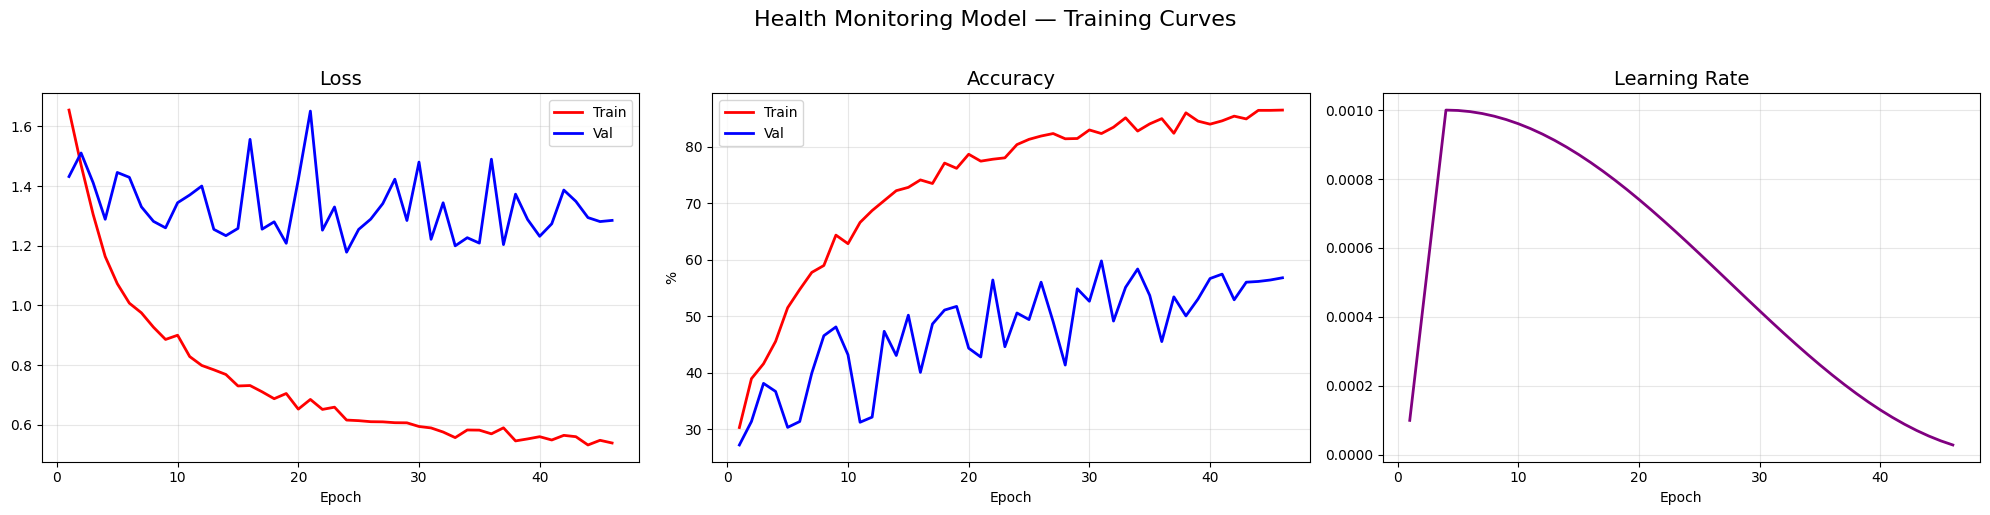

Curves saved ✅


In [12]:
# ============================================================
# CELL 12 — TRAINING CURVES
# ============================================================
ep = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(ep, history["train_loss"], 'r-', lw=2, label="Train")
axes[0].plot(ep, history["val_loss"],   'b-', lw=2, label="Val")
axes[0].set_title("Loss",     fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, [a*100 for a in history["train_acc"]], 'r-', lw=2, label="Train")
axes[1].plot(ep, [a*100 for a in history["val_acc"]],   'b-', lw=2, label="Val")
axes[1].set_title("Accuracy", fontsize=14)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("%")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(ep, history["lr"], color="purple", lw=2)
axes[2].set_title("Learning Rate", fontsize=14)
axes[2].set_xlabel("Epoch")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Health Monitoring Model — Training Curves",
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("health_training_curves.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Curves saved ✅")

Best model loaded ✅


Final Eval: 100%|████████| 4/4 [00:00<00:00, 10.52it/s, acc=0.5979, loss=1.2218]



HEALTH MODEL v2 — FINAL RESULTS
Val Accuracy   : 59.79%
Avg confidence : 1.00
Total classes  : 4
Embedding dim  : 512

Per-class accuracy:
  baseline    :  59.7% █████████████████
  stress      :  61.9% ██████████████████
  amusement   :  20.7% ██████
  meditation  :  76.4% ██████████████████████

CONFUSION MATRIX


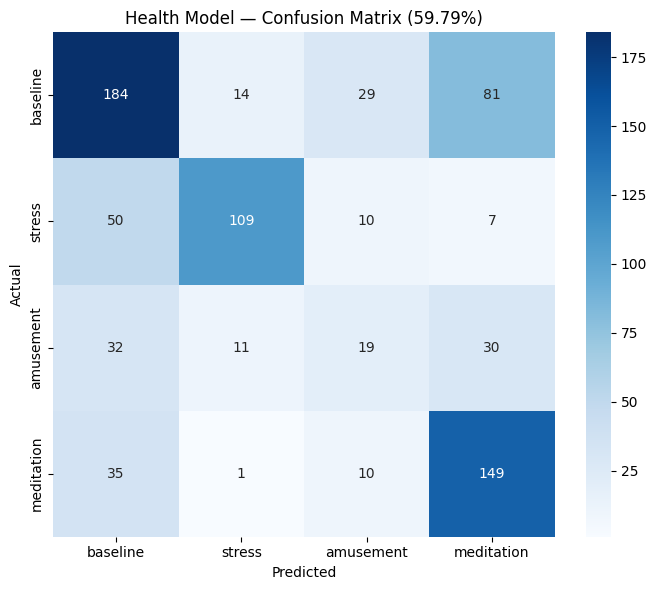


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    baseline       0.61      0.60      0.60       308
      stress       0.81      0.62      0.70       176
   amusement       0.28      0.21      0.24        92
  meditation       0.56      0.76      0.65       195

    accuracy                           0.60       771
   macro avg       0.56      0.55      0.55       771
weighted avg       0.60      0.60      0.59       771


MISSING SENSOR ROBUSTNESS TEST
  ✅ All sensors               (6/6 sensors): 59.8% █████████████████
  ✅ No ACC                    (3/6 sensors): 47.5% ██████████████
  ✅ No BVP                    (5/6 sensors): 51.8% ███████████████
  ✅ No EDA                    (5/6 sensors): 56.0% ████████████████
  ✅ No TEMP                   (5/6 sensors): 62.9% ██████████████████
  ✅ Only EDA+BVP              (2/6 sensors): 47.9% ██████████████
  ⚠️ Only EDA                  (1/6 sensors): 35.8% ██████████
  ⚠️ Full device missing       (0/6 senso

In [13]:
# ============================================================
# CELL 13 — FULL EVALUATION (BEST MODEL)
# ============================================================

best_model = HealthModel(
    num_classes=NUM_CLASSES,
    embedding_dim=EMBEDDING_DIM
).to(device)

best_model.load_state_dict(
    torch.load("best_health_model.pth", map_location=device)
)
best_model.eval()
print("Best model loaded ✅")

_, val_acc, val_pc, all_preds, all_labels, val_conf = evaluate(
    best_model, val_loader, desc="Final Eval"
)

print(f"\n{'='*60}")
print(f"HEALTH MODEL v2 — FINAL RESULTS")
print(f"{'='*60}")
print(f"Val Accuracy   : {val_acc*100:.2f}%")
print(f"Avg confidence : {val_conf:.2f}")
print(f"Total classes  : {NUM_CLASSES}")
print(f"Embedding dim  : {EMBEDDING_DIM}")

print(f"\nPer-class accuracy:")
for cls in HEALTH_CLASSES:
    bar = "█" * int(val_pc[cls] * 30)
    print(f"  {cls:12s}: {val_pc[cls]*100:5.1f}% {bar}")

# ── Confusion matrix ──
print(f"\n{'='*60}")
print("CONFUSION MATRIX")
print(f"{'='*60}")
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=HEALTH_CLASSES,
            yticklabels=HEALTH_CLASSES,
            cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Health Model — Confusion Matrix ({val_acc*100:.2f}%)")
plt.tight_layout()
plt.savefig("cm_health.png", dpi=150)
plt.show()

# ── Classification report ──
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print(f"{'='*60}")
print(classification_report(
    all_labels, all_preds,
    target_names=HEALTH_CLASSES
))

# ── Missing sensor robustness test ──
print(f"\n{'='*60}")
print("MISSING SENSOR ROBUSTNESS TEST")
print(f"{'='*60}")

sensor_scenarios = {
    "All sensors"          : [1, 1, 1, 1, 1, 1],
    "No ACC"               : [0, 0, 0, 1, 1, 1],
    "No BVP"               : [1, 1, 1, 0, 1, 1],
    "No EDA"               : [1, 1, 1, 1, 0, 1],
    "No TEMP"              : [1, 1, 1, 1, 1, 0],
    "Only EDA+BVP"         : [0, 0, 0, 1, 1, 0],
    "Only EDA"             : [0, 0, 0, 0, 1, 0],
    "Full device missing"  : [0, 0, 0, 0, 0, 0],
}

for scenario_name, sensor_mask in sensor_scenarios.items():
    scenario_preds  = []
    scenario_labels = []

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)

            # Apply sensor mask
            for ch_idx, available in enumerate(sensor_mask):
                if not available:
                    x[:, ch_idx, :] = 0.0

            out   = best_model(x)
            preds = out.argmax(dim=1).cpu().numpy()
            scenario_preds.extend(preds)
            scenario_labels.extend(y.numpy())

    scenario_acc = np.mean(
        np.array(scenario_preds) == np.array(scenario_labels)
    )
    sensors_on = sum(sensor_mask)
    bar        = "█" * int(scenario_acc * 30)
    flag       = "✅" if scenario_acc > 0.40 else "⚠️"
    print(f"  {flag} {scenario_name:25s} "
          f"({sensors_on}/6 sensors): "
          f"{scenario_acc*100:.1f}% {bar}")

In [14]:
# ============================================================
# CELL 14 — FUSION READINESS CHECK
# ============================================================
best_model.eval()

x_sample, _ = next(iter(val_loader))
x_sample    = x_sample.to(device)

with torch.no_grad():
    emb    = best_model.get_embedding(x_sample)
    logits = best_model(x_sample)

print("=" * 60)
print("MULTIMODAL FUSION READINESS — HEALTH BRANCH")
print("=" * 60)
print(f"Input shape     : {x_sample.shape}")
print(f"Embedding shape : {emb.shape}   ← for fusion")
print(f"Output shape    : {logits.shape}")
print(f"Embedding stats : mean={emb.mean():.4f}  "
      f"std={emb.std():.4f}")
print()
print("All branches status:")
print(f"  emotion_emb = [B, 768]  ✅ ConvNeXt-Small + CBAM")
print(f"  env_emb     = [B, 512]  ✅ ResNet-50, filtered scenes")
print(f"  health_emb  = [B, 512]  ✅ 1D CNN, WESAD wrist signals")
print()
print("Fusion:")
print("  fused = torch.cat([emotion_emb, env_emb, health_emb], dim=1)")
print(f"  fused shape = [B, 1792]")
print()
print("✅ Health branch complete and fusion-ready!")

MULTIMODAL FUSION READINESS — HEALTH BRANCH
Input shape     : torch.Size([256, 6, 120])
Embedding shape : torch.Size([256, 512])   ← for fusion
Output shape    : torch.Size([256, 4])
Embedding stats : mean=0.0162  std=0.0411

All branches status:
  emotion_emb = [B, 768]  ✅ ConvNeXt-Small + CBAM
  env_emb     = [B, 512]  ✅ ResNet-50, filtered scenes
  health_emb  = [B, 512]  ✅ 1D CNN, WESAD wrist signals

Fusion:
  fused = torch.cat([emotion_emb, env_emb, health_emb], dim=1)
  fused shape = [B, 1792]

✅ Health branch complete and fusion-ready!


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, TensorDataset
import kornia.augmentation as K
import numpy as np
from tqdm import tqdm
import os
import pickle
from math import gcd
from scipy.signal import resample_poly
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ============================================================
# STEP 1 — DEFINE ALL 3 MODEL CLASSES
# ============================================================

import timm

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()
    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class EmotionModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = timm.create_model("convnext_small", pretrained=False, num_classes=0)
        self.cbam = CBAM(768)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(768, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.embedding_dim = 768
    def get_embedding(self, x):
        x = self.backbone.forward_features(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return x
    def forward(self, x):
        return self.classifier(self.get_embedding(x))

class EnvironmentModel(nn.Module):
    def __init__(self, num_classes=147, embedding_dim=512):
        super().__init__()
        backbone = models.resnet50(weights=None)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.embedding_head = nn.Sequential(
            nn.Linear(2048, 1024), nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(1024, embedding_dim), nn.BatchNorm1d(embedding_dim), nn.GELU(), nn.Dropout(0.3),
        )
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )
        self.embedding_dim = embedding_dim
    def get_embedding(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.embedding_head(x)
        return x
    def forward(self, x):
        return self.classifier(self.get_embedding(x))

class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7, dilation=1, dropout=0.2, pool=2):
        super().__init__()
        pad = (kernel - 1) * dilation // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, dilation=dilation, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch), nn.GELU(), nn.Dropout(dropout), nn.MaxPool1d(pool)
        )
    def forward(self, x):
        return self.block(x)

class HealthModel(nn.Module):
    def __init__(self, num_classes=4, embedding_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock1D(6, 64, kernel=7, dilation=1, dropout=0.2, pool=2),
            ConvBlock1D(64, 128, kernel=7, dilation=1, dropout=0.2, pool=2),
            ConvBlock1D(128, 256, kernel=7, dilation=2, dropout=0.3, pool=2),
            ConvBlock1D(256, 512, kernel=7, dilation=4, dropout=0.3, pool=2),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.embedding_head = nn.Sequential(
            nn.Linear(512, embedding_dim), nn.BatchNorm1d(embedding_dim), nn.GELU(), nn.Dropout(0.3),
        )
        # ── Residual projection (required by saved checkpoint) ──
        self.residual_proj = nn.Linear(512, embedding_dim)
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )
        self.embedding_dim = embedding_dim

    def get_embedding(self, x, normalize=False):
        feat = self.encoder(x)
        feat = self.pool(feat)
        feat = torch.flatten(feat, 1)        # [B, 512]
        residual = self.residual_proj(feat)  # [B, 512]
        emb = self.embedding_head(feat)      # [B, 512]
        emb = emb + residual                 # [B, 512]
        if normalize:
            emb = F.normalize(emb, p=2, dim=1)
        return emb

    def forward(self, x):
        return self.classifier(self.get_embedding(x, normalize=False))

print("Model classes defined ✅")

# ============================================================
# STEP 2 — LOAD MODELS
# ============================================================

emotion_model = EmotionModel(num_classes=7).to(device)
emotion_model.load_state_dict(torch.load("best_emotion_model.pth", map_location=device))
emotion_model.eval()
print("Emotion model loaded ✅")

env_model = EnvironmentModel(num_classes=147, embedding_dim=512).to(device)
env_model.load_state_dict(torch.load("best_environment_model.pth", map_location=device))
env_model.eval()
print("Environment model loaded ✅")

health_model = HealthModel(num_classes=4, embedding_dim=512).to(device)
health_model.load_state_dict(torch.load("best_health_model.pth", map_location=device))
health_model.eval()
print("Health model loaded ✅")

# ============================================================
# STEP 3 — EMOTION EMBEDDINGS
# ============================================================

print("\n" + "="*60)
print("EXTRACTING EMOTION EMBEDDINGS")
print("="*60)

class RAFDBDataset(ImageFolder):
    RAFDB_TO_IDX = {'1':6,'2':2,'3':1,'4':3,'5':5,'6':0,'7':4}
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)
        remapped = []
        for path, _ in self.samples:
            folder_name = os.path.basename(os.path.dirname(path))
            new_label = self.RAFDB_TO_IDX[folder_name]
            remapped.append((path, new_label))
        self.samples = remapped
        self.targets = [s[1] for s in remapped]

test_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

RAFDB_TEST = "/home/btech02_06/emotion_project/datasets/raf-db-dataset/DATASET/test"
rafdb_test = RAFDBDataset(RAFDB_TEST, transform=test_transform)
rafdb_loader = DataLoader(rafdb_test, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

gpu_normalize = K.Normalize(mean=torch.tensor(IMAGENET_MEAN), std=torch.tensor(IMAGENET_STD)).to(device)

emotion_embs, emotion_preds, emotion_labels = [], [], []

with torch.no_grad():
    for images, labels in tqdm(rafdb_loader, desc="Emotion"):
        images = images.to(device)
        images = gpu_normalize(images)
        emb = F.normalize(emotion_model.get_embedding(images), p=2, dim=1)
        preds = torch.argmax(emotion_model(images), dim=1)
        emotion_embs.append(emb.cpu())
        emotion_preds.append(preds.cpu())
        emotion_labels.append(labels)

emotion_embs = torch.cat(emotion_embs)
emotion_preds = torch.cat(emotion_preds)
emotion_labels = torch.cat(emotion_labels)

torch.save({
    "embeddings": emotion_embs,
    "preds": emotion_preds,
    "labels": emotion_labels,
    "classes": ['angry','disgust','fear','happy','neutral','sad','surprise']
}, "emotion_embeddings.pt")
print(f"✅ Saved → emotion_embeddings.pt shape={emotion_embs.shape}")

# ============================================================
# STEP 4 — ENVIRONMENT EMBEDDINGS
# ============================================================

print("\n" + "="*60)
print("EXTRACTING ENVIRONMENT EMBEDDINGS")
print("="*60)

val_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

PLACES_VAL = "/home/btech02_06/emotion_project/datasets/places365_filtered/val"
places_val = ImageFolder(PLACES_VAL, transform=val_transform)
places_loader = DataLoader(places_val, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

env_embs, env_preds, env_labels = [], [], []

with torch.no_grad():
    for images, labels in tqdm(places_loader, desc="Environment"):
        images = images.to(device)
        images = gpu_normalize(images)
        emb = F.normalize(env_model.get_embedding(images), p=2, dim=1)
        preds = torch.argmax(env_model(images), dim=1)
        env_embs.append(emb.cpu())
        env_preds.append(preds.cpu())
        env_labels.append(labels)

env_embs = torch.cat(env_embs)
env_preds = torch.cat(env_preds)
env_labels = torch.cat(env_labels)

torch.save({
    "embeddings": env_embs,
    "preds": env_preds,
    "labels": env_labels,
    "classes": places_val.classes
}, "env_embeddings.pt")
print(f"✅ Saved → env_embeddings.pt shape={env_embs.shape}")

# ============================================================
# STEP 5 — HEALTH EMBEDDINGS
# ============================================================

print("\n" + "="*60)
print("EXTRACTING HEALTH EMBEDDINGS")
print("="*60)

HEALTH_CLASSES = ['baseline', 'stress', 'amusement', 'meditation']
LABEL_MAP = {1: 0, 2: 1, 3: 2, 4: 3}
VALID_LABELS = {1, 2, 3, 4}
TARGET_HZ = 4
LABEL_HZ = 700
ORIG_HZ = {'ACC': 32, 'BVP': 64, 'EDA': 4, 'TEMP': 4}
WINDOW_STEPS = 120
STRIDE_STEPS = 60
PURITY_THRESH = 0.70
BOUNDARY_DROP = 8
NUM_CHANNELS = 6
VAL_SUBJECTS = ['S14', 'S15', 'S16', 'S17']
WESAD_PATH = "/home/btech02_06/emotion_project/datasets/wesad/WESAD"

def safe_resample(signal, orig_hz, target_hz):
    g = gcd(target_hz, orig_hz)
    up, down = target_hz // g, orig_hz // g
    if signal.ndim == 1:
        return resample_poly(signal, up, down).astype(np.float32)
    else:
        return np.stack([resample_poly(signal[:, i], up, down) for i in range(signal.shape[1])], axis=1).astype(np.float32)

def load_subject(subject_id):
    pkl_path = os.path.join(WESAD_PATH, subject_id, f"{subject_id}.pkl")
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")
    wrist = data["signal"]["wrist"]
    labels = data["label"]
    acc = safe_resample(wrist["ACC"], ORIG_HZ["ACC"], TARGET_HZ)
    bvp = safe_resample(wrist["BVP"].flatten(), ORIG_HZ["BVP"], TARGET_HZ)
    eda = safe_resample(wrist["EDA"].flatten(), ORIG_HZ["EDA"], TARGET_HZ)
    temp = safe_resample(wrist["TEMP"].flatten(), ORIG_HZ["TEMP"], TARGET_HZ)
    lbl = np.round(safe_resample(labels.astype(np.float32), LABEL_HZ, TARGET_HZ)).astype(np.int32)
    min_len = min(len(acc), len(bvp), len(eda), len(temp), len(lbl))
    signals = np.concatenate([acc[:min_len], bvp[:min_len].reshape(-1,1), eda[:min_len].reshape(-1,1), temp[:min_len].reshape(-1,1)], axis=1)
    return signals.astype(np.float32), lbl[:min_len]

def extract_windows(signals, labels):
    windows, win_labels = [], []
    boundaries = []
    start, current = 0, labels[0]
    for i in range(1, len(labels)):
        if labels[i] != current:
            boundaries.append((start, i, current))
            start, current = i, labels[i]
    boundaries.append((start, len(labels), current))
    for seg_start, seg_end, seg_label in boundaries:
        if seg_label not in VALID_LABELS: continue
        if seg_end - seg_start < WINDOW_STEPS: continue
        safe_start = seg_start + BOUNDARY_DROP
        safe_end = seg_end - BOUNDARY_DROP
        if safe_end - safe_start < WINDOW_STEPS: continue
        seg_signals = signals[safe_start:safe_end]
        seg_labels = labels[safe_start:safe_end]
        pos = 0
        while pos + WINDOW_STEPS <= len(seg_signals):
            w_sig = seg_signals[pos: pos + WINDOW_STEPS]
            w_lbl = seg_labels[pos: pos + WINDOW_STEPS]
            if np.any(w_lbl == 0): pos += STRIDE_STEPS; continue
            if not all(int(l) in VALID_LABELS for l in w_lbl): pos += STRIDE_STEPS; continue
            counts = Counter(w_lbl.tolist())
            most_common_lbl, most_common_cnt = counts.most_common(1)[0]
            if most_common_cnt / WINDOW_STEPS < PURITY_THRESH: pos += STRIDE_STEPS; continue
            if most_common_lbl not in LABEL_MAP: pos += STRIDE_STEPS; continue
            mean = w_sig.mean(axis=0, keepdims=True)
            std = w_sig.std(axis=0, keepdims=True) + 1e-8
            w_sig = ((w_sig - mean) / std).T
            windows.append(w_sig)
            win_labels.append(LABEL_MAP[most_common_lbl])
            pos += STRIDE_STEPS
    if len(windows) == 0:
        return np.empty((0, NUM_CHANNELS, WINDOW_STEPS), dtype=np.float32), np.empty((0,), dtype=np.int64)
    return np.stack(windows).astype(np.float32), np.array(win_labels, dtype=np.int64)

all_windows, all_labels_h = [], []
for sid in VAL_SUBJECTS:
    signals, labels = load_subject(sid)
    windows, win_lbl = extract_windows(signals, labels)
    all_windows.append(windows)
    all_labels_h.append(win_lbl)
    print(f"  {sid}: {len(windows)} windows")

all_windows = np.concatenate(all_windows)
all_labels_h = np.concatenate(all_labels_h)

health_tensor_ds = TensorDataset(torch.FloatTensor(all_windows), torch.LongTensor(all_labels_h))
health_loader = DataLoader(health_tensor_ds, batch_size=256, shuffle=False)

health_embs, health_preds, health_labels = [], [], []

with torch.no_grad():
    for x, labels in tqdm(health_loader, desc="Health"):
        x = x.to(device)
        emb = F.normalize(health_model.get_embedding(x, normalize=False), p=2, dim=1)
        preds = torch.argmax(health_model(x), dim=1)
        health_embs.append(emb.cpu())
        health_preds.append(preds.cpu())
        health_labels.append(labels)

health_embs = torch.cat(health_embs)
health_preds = torch.cat(health_preds)
health_labels = torch.cat(health_labels)

torch.save({
    "embeddings": health_embs,
    "preds": health_preds,
    "labels": health_labels,
    "classes": HEALTH_CLASSES
}, "health_embeddings.pt")
print(f"✅ Saved → health_embeddings.pt shape={health_embs.shape}")

# ============================================================
# VERIFICATION
# ============================================================

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

e = torch.load("emotion_embeddings.pt")
v = torch.load("env_embeddings.pt")
h = torch.load("health_embeddings.pt")

print(f"Emotion      : {e['embeddings'].shape}")
print(f"Environment  : {v['embeddings'].shape}")
print(f"Health       : {h['embeddings'].shape}")

assert not torch.isnan(e['embeddings']).any()
assert not torch.isnan(v['embeddings']).any()
assert not torch.isnan(h['embeddings']).any()

print("\n✅ All embeddings extracted successfully!")
print("✅ Ready for fusion!")

Device: cuda
Model classes defined ✅
Emotion model loaded ✅
Environment model loaded ✅
Health model loaded ✅

EXTRACTING EMOTION EMBEDDINGS


Emotion: 100%|██████████████████████████████████| 48/48 [00:24<00:00,  1.98it/s]


✅ Saved → emotion_embeddings.pt shape=torch.Size([3068, 768])

EXTRACTING ENVIRONMENT EMBEDDINGS


Environment: 100%|████████████████████████████| 230/230 [00:51<00:00,  4.49it/s]
/tmp/ipykernel_137511/2710315962.py:303: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


✅ Saved → env_embeddings.pt shape=torch.Size([14700, 512])

EXTRACTING HEALTH EMBEDDINGS
  S14: 193 windows
  S15: 194 windows
  S16: 193 windows
  S17: 191 windows


Health: 100%|█████████████████████████████████████| 4/4 [00:00<00:00, 87.65it/s]

✅ Saved → health_embeddings.pt shape=torch.Size([771, 512])

FINAL SUMMARY
Emotion      : torch.Size([3068, 768])
Environment  : torch.Size([14700, 512])
Health       : torch.Size([771, 512])

✅ All embeddings extracted successfully!
✅ Ready for fusion!


In [17]:
#Fusion

In [1]:
# ==============================================================
# MULTIMODAL FUSION — COMPLETE PIPELINE
# 5 modalities: emotion | env | health | gesture | speech
# Works with 3 modalities now, plug in 4th & 5th when ready
# ==============================================================
 
# ==============================================================
# CELL 1 — IMPORTS & CONFIG
# ==============================================================
 
import os, json, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from collections import Counter, deque
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
 
warnings.filterwarnings("ignore")
 
# ── REPRODUCIBILITY ───────────────────────────────────────────
SEED = 42
def set_seed(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
 
set_seed(SEED)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
 
# ==============================================================
# ▼▼▼  EDIT ONLY THESE PATHS — NOTHING ELSE BELOW  ▼▼▼
# ==============================================================
EMOTION_EMB_PATH  = "emotion_embeddings.pt"    # ✅ ready
ENV_EMB_PATH      = "env_embeddings.pt"         # ✅ ready
HEALTH_EMB_PATH   = "health_embeddings.pt"      # ✅ ready
GESTURE_EMB_PATH  = "gesture_embeddings.pt"   # set to "gesture_embeddings.pt" when friend is done
SPEECH_EMB_PATH   = "speech_embeddings.pt"   # set to "speech_embeddings.pt"  when friend is done
 
FUSION_SAVE_PATH  = "best_fusion_model.pth"
RESULTS_DIR       = "fusion_results"
# ==============================================================
 
os.makedirs(RESULTS_DIR, exist_ok=True)
 
# ── HYPERPARAMETERS ───────────────────────────────────────────
COMMON_DIM       = 256      # every modality projected to this size
NUM_CLASSES      = 4        # fusion output classes
BATCH_SIZE       = 64
EPOCHS           = 60       # total training epochs
LR               = 1e-3     # learning rate for fusion model
WEIGHT_DECAY     = 1e-4
LABEL_SMOOTH     = 0.1
MODALITY_DROP_P  = 0.15     # per-sample probability of dropping each modality
NUM_PAIRS        = 5000     # synthetic training pairs to generate
VAL_SPLIT        = 0.20     # 20 % validation
PATIENCE         = 12       # early stopping patience
WARMUP_EPOCHS    = 5        # linear warmup before cosine decay
 
# ── CLASS LABELS (DO NOT CHANGE — must match saved .pt files) ─
FUSION_CLASSES   = ['normal', 'needs_attention', 'call_nurse', 'emergency']
EMOTION_CLASSES  = ['angry','disgust','fear','happy','neutral','sad','surprise']
HEALTH_CLASSES   = ['baseline','stress','amusement','meditation']
 
# emotion index shortcuts (for label rules below)
_E = {c: i for i, c in enumerate(EMOTION_CLASSES)}
_H = {c: i for i, c in enumerate(HEALTH_CLASSES)}
 
# modality input dimensions — match your saved embeddings
MODALITY_DIMS  = [768, 512, 512, 512, 512]   # emotion,env,health,gesture,speech
MODALITY_NAMES = ['emotion', 'env', 'health', 'gesture', 'speech']
NUM_MODALITIES = 5
 

Device : cuda


In [2]:
# ==============================================================
# CELL 2 — LOAD & VALIDATE EMBEDDINGS
# ==============================================================
 
def load_embedding_file(path, name, expected_dim):
    """
    Loads a saved embedding .pt file.
    Returns dict with 'embeddings', 'labels', 'classes' or None if unavailable.
    Also re-normalises if somehow not L2-normalised.
    """
    if path is None:
        print(f"  [{name}] Not provided — will use zeros + mask=0 during training")
        return None
    if not os.path.exists(path):
        print(f"  [{name}] File not found: {path} — will use zeros + mask=0")
        return None
 
    data   = torch.load(path, map_location='cpu')
    embs   = data['embeddings'].float()
    labels = data['labels']
 
    # ── shape check ──────────────────────────────────────────
    assert embs.ndim == 2, f"{name}: expected 2D tensor, got {embs.ndim}D"
    assert embs.shape[1] == expected_dim, \
        f"{name}: expected dim {expected_dim}, got {embs.shape[1]}"
 
    # ── NaN / Inf guard ──────────────────────────────────────
    if torch.isnan(embs).any() or torch.isinf(embs).any():
        raise ValueError(f"{name}: NaN or Inf found in embeddings!")
 
    # ── L2 norm check — re-normalise if needed ───────────────
    norms = embs.norm(dim=1)
    max_deviation = (norms - 1.0).abs().max().item()
    if max_deviation > 0.02:
        print(f"  [{name}] WARNING: not L2-normalised (max dev={max_deviation:.4f}). "
              f"Re-normalising now.")
        embs = F.normalize(embs, p=2, dim=1)
    else:
        print(f"  [{name}] ✅ shape={tuple(embs.shape)}  "
              f"norm_ok (max_dev={max_deviation:.4f})")
 
    return {'embeddings': embs, 'labels': labels,
            'classes': data.get('classes', [])}
 
 
print("\nLoading embeddings ...")
emotion_data  = load_embedding_file(EMOTION_EMB_PATH,  'emotion',  768)
env_data      = load_embedding_file(ENV_EMB_PATH,      'env',      512)
health_data   = load_embedding_file(HEALTH_EMB_PATH,   'health',   512)
gesture_data  = load_embedding_file(GESTURE_EMB_PATH,  'gesture',  512)
speech_data   = load_embedding_file(SPEECH_EMB_PATH,   'speech',   512)
 
all_data = [emotion_data, env_data, health_data, gesture_data, speech_data]
 
# availability mask (at modality level, not sample level)
modality_available = [d is not None for d in all_data]
print(f"\nAvailable modalities: "
      f"{[n for n, a in zip(MODALITY_NAMES, modality_available) if a]}")


Loading embeddings ...
  [emotion] ✅ shape=(3068, 768)  norm_ok (max_dev=0.0000)
  [env] ✅ shape=(14700, 512)  norm_ok (max_dev=0.0000)
  [health] ✅ shape=(771, 512)  norm_ok (max_dev=0.0000)
  [gesture] WARNING: not L2-normalised (max dev=431.8635). Re-normalising now.
  [speech] WARNING: not L2-normalised (max dev=20.5041). Re-normalising now.

Available modalities: ['emotion', 'env', 'health', 'gesture', 'speech']


In [3]:
# ==============================================================
# CELL 3 — FUSION LABEL RULES + SYNTHETIC DATASET
# ==============================================================
 
# ── Correlated emotion sampling probabilities ─────────────────
# Reflects realistic co-occurrence of health state + emotion
# health: 0=baseline, 1=stress, 2=amusement, 3=meditation
# emotion:angry disgust fear  happy neutral sad   surprise
HEALTH_TO_EMOTION_PROBS = {
    0: [0.05, 0.05, 0.05, 0.38, 0.35, 0.07, 0.05],  # baseline  → happy/neutral
    1: [0.22, 0.08, 0.25, 0.04, 0.10, 0.22, 0.09],  # stress    → angry/fear/sad
    2: [0.04, 0.03, 0.04, 0.42, 0.14, 0.05, 0.28],  # amusement → happy/surprise
    3: [0.02, 0.02, 0.03, 0.14, 0.70, 0.06, 0.03],  # meditation→ neutral
}
 
def assign_fusion_label(emotion_idx, health_idx):
    """
    Rule-based fusion label assignment.
    emotion: 0=angry 1=disgust 2=fear 3=happy 4=neutral 5=sad 6=surprise
    health:  0=baseline 1=stress 2=amusement 3=meditation
    Returns: 0=normal 1=needs_attention 2=call_nurse 3=emergency
    """
    # EMERGENCY — stress + strong negative emotion
    if health_idx == _H['stress'] and emotion_idx in [_E['angry'], _E['fear'], _E['sad']]:
        return 3  # emergency
 
    # CALL NURSE — stress alone, or fear while not well
    if health_idx == _H['stress']:
        return 2  # call_nurse
    if emotion_idx == _E['fear'] and health_idx not in [_H['baseline'], _H['meditation']]:
        return 2  # call_nurse
 
    # NEEDS ATTENTION — negative emotion OR non-baseline health
    if emotion_idx in [_E['angry'], _E['disgust'], _E['fear'], _E['sad']]:
        return 1  # needs_attention
    if health_idx == _H['stress']:
        return 1  # needs_attention (already covered above but kept for clarity)
 
    # NORMAL — happy/neutral + healthy state
    return 0  # normal
 
 
def build_emotion_class_indices(emotion_data):
    """Returns dict: {class_idx → list of sample indices}"""
    idx_by_class = {}
    for i, lbl in enumerate(emotion_data['labels'].tolist()):
        idx_by_class.setdefault(lbl, []).append(i)
    return idx_by_class
 
def build_health_class_indices(health_data):
    idx_by_class = {}
    for i, lbl in enumerate(health_data['labels'].tolist()):
        idx_by_class.setdefault(lbl, []).append(i)
    return idx_by_class
 
 
class FusionDataset(Dataset):
    """
    Generates synthetic multimodal paired samples.
    Works with 3, 4, or 5 modalities — missing ones use zeros + mask=0.
    """
 
    def __init__(self, all_data, num_pairs, modality_available,
                 modality_drop_p=0.0, augment=False):
        """
        all_data         : list of 5 dicts or None, in order:
                           [emotion, env, health, gesture, speech]
        num_pairs        : how many pairs to generate
        modality_available: bool list, length 5
        modality_drop_p  : probability of randomly masking each available
                           modality per sample (for training robustness)
        augment          : whether to add Gaussian noise to embeddings
        """
        self.all_data          = all_data
        self.modality_available = modality_available
        self.modality_drop_p   = modality_drop_p
        self.augment           = augment
        self.dims              = MODALITY_DIMS
 
        # Build class-grouped indices for correlated sampling
        self.emotion_by_class = build_emotion_class_indices(all_data[0])
        self.health_by_class  = build_health_class_indices(all_data[2])
 
        # Generate pairs
        self.pairs = self._generate_pairs(num_pairs)
 
        # Report class distribution
        labels = [p[-1] for p in self.pairs]
        counts = Counter(labels)
        print(f"\nFusion dataset: {len(self.pairs)} pairs")
        for i, cls in enumerate(FUSION_CLASSES):
            bar = '█' * int(counts.get(i, 0) / len(self.pairs) * 30)
            print(f"  {cls:16s} ({i}): {counts.get(i,0):5d}  {bar}")
 
    def _generate_pairs(self, num_pairs):
        pairs = []
        n_env = len(self.all_data[1]['labels'])
        n_ges = len(self.all_data[3]['labels']) if self.all_data[3] else 0
        n_spe = len(self.all_data[4]['labels']) if self.all_data[4] else 0
 
        # Balanced generation: equal pairs per fusion class
        pairs_per_class = num_pairs // NUM_CLASSES
        health_class_list = list(self.health_by_class.keys())
 
        for target_fusion_label in range(NUM_CLASSES):
            generated = 0
            max_attempts = pairs_per_class * 20
            attempts = 0
            while generated < pairs_per_class and attempts < max_attempts:
                attempts += 1
 
                # ── Sample health ─────────────────────────────────
                h_class = random.choice(health_class_list)
                h_idx   = random.choice(self.health_by_class[h_class])
 
                # ── Sample emotion (correlated with health) ───────
                probs = HEALTH_TO_EMOTION_PROBS[h_class]
                e_class = int(np.random.choice(len(EMOTION_CLASSES), p=probs))
                if e_class not in self.emotion_by_class:
                    continue
                e_idx = random.choice(self.emotion_by_class[e_class])
 
                # ── Check label ───────────────────────────────────
                label = assign_fusion_label(e_class, h_class)
                if label != target_fusion_label:
                    continue
 
                # ── Sample env (random — no correlation needed) ───
                env_idx = random.randint(0, n_env - 1)
 
                # ── Sample gesture / speech if available ──────────
                ges_idx = random.randint(0, n_ges - 1) if n_ges > 0 else -1
                spe_idx = random.randint(0, n_spe - 1) if n_spe > 0 else -1
 
                pairs.append((e_idx, env_idx, h_idx, ges_idx, spe_idx, label))
                generated += 1
 
        random.shuffle(pairs)
        return pairs
 
    def __len__(self):
        return len(self.pairs)
 
    def __getitem__(self, idx):
        e_idx, env_idx, h_idx, ges_idx, spe_idx, label = self.pairs[idx]
 
        sample_indices = [e_idx, env_idx, h_idx, ges_idx, spe_idx]
        embs = []
        mask = []
 
        for i, (avail, s_idx) in enumerate(zip(self.modality_available, sample_indices)):
            dim = self.dims[i]
            if avail and s_idx >= 0:
                emb = self.all_data[i]['embeddings'][s_idx].clone()
                if self.augment:
                    emb = emb + torch.randn_like(emb) * 0.01  # tiny noise
                    emb = F.normalize(emb, p=2, dim=0)
                embs.append(emb)
                mask.append(1.0)
            else:
                embs.append(torch.zeros(dim))
                mask.append(0.0)
 
        mask_tensor = torch.tensor(mask, dtype=torch.float32)
 
        # ── Per-sample modality dropout (training only) ───────────
        if self.modality_drop_p > 0.0:
            for i in range(NUM_MODALITIES):
                if mask_tensor[i] == 1.0:          # only drop available ones
                    if random.random() < self.modality_drop_p:
                        embs[i] = torch.zeros(self.dims[i])
                        mask_tensor[i] = 0.0
            # Safety: never drop ALL modalities
            if mask_tensor.sum() == 0:
                # restore the first available modality
                for i in range(NUM_MODALITIES):
                    if self.modality_available[i]:
                        embs[i] = self.all_data[i]['embeddings'][sample_indices[i]].clone()
                        mask_tensor[i] = 1.0
                        break
 
        return (*embs, mask_tensor, torch.tensor(label, dtype=torch.long))
 
 
def build_dataloaders(all_data, modality_available):
    """Builds train and val DataLoaders with class-balanced sampling."""
 
    full_ds = FusionDataset(all_data, NUM_PAIRS, modality_available,
                            modality_drop_p=MODALITY_DROP_P, augment=True)
 
    n_val   = int(len(full_ds) * VAL_SPLIT)
    n_train = len(full_ds) - n_val
 
    gen = torch.Generator().manual_seed(SEED)
    train_ds, _ = torch.utils.data.random_split(full_ds, [n_train, n_val], generator=gen)
 
    # Val dataset: separate fresh dataset — no modality dropout, no augmentation
    val_full = FusionDataset(all_data, int(NUM_PAIRS * VAL_SPLIT),
                             modality_available, modality_drop_p=0.0, augment=False)
 
    # Class-weighted sampler for training (handles imbalance)
    train_labels = [full_ds.pairs[i][-1] for i in train_ds.indices]
    class_counts = Counter(train_labels)
    class_weights = {c: 1.0 / max(class_counts[c], 1) for c in range(NUM_CLASSES)}
    sample_weights = [class_weights[lbl] for lbl in train_labels]
    sampler = WeightedRandomSampler(
        weights=sample_weights, num_samples=len(sample_weights), replacement=True
    )
 
    train_loader = DataLoader(train_ds,  batch_size=BATCH_SIZE,
                              sampler=sampler, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_full,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
 
    print(f"\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}")
    return train_loader, val_loader
 
 
print("\nBuilding datasets ...")
train_loader, val_loader = build_dataloaders(all_data, modality_available)
 


Building datasets ...

Fusion dataset: 5000 pairs
  normal           (0):  1250  ███████
  needs_attention  (1):  1250  ███████
  call_nurse       (2):  1250  ███████
  emergency        (3):  1250  ███████

Fusion dataset: 1000 pairs
  normal           (0):   250  ███████
  needs_attention  (1):   250  ███████
  call_nurse       (2):   250  ███████
  emergency        (3):   250  ███████

Train batches: 63 | Val batches: 16


In [4]:
# ==============================================================
# CELL 4 — FUSION MODEL ARCHITECTURE
# ==============================================================
 
class ModalityProjection(nn.Module):
    """Projects one modality from its native dim to COMMON_DIM."""
    def __init__(self, input_dim, output_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)
 
 
class MultimodalFusionModel(nn.Module):
    """
    Attention-gated multimodal fusion.
 
    Forward signature:
        forward(emotion, env, health, gesture, speech, mask)
        mask : [B, 5] float — 1 = available, 0 = missing
 
    Works correctly with any subset of modalities.
    """
 
    def __init__(self, modality_dims=MODALITY_DIMS,
                 common_dim=COMMON_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.common_dim      = common_dim
        self.num_modalities  = len(modality_dims)
 
        # ── Projection layers (one per modality) ─────────────────
        self.projections = nn.ModuleList([
            ModalityProjection(d, common_dim, dropout=0.2)
            for d in modality_dims
        ])
 
        # ── Attention: maps flattened projections → per-modality scores ─
        self.attention = nn.Sequential(
            nn.Linear(common_dim * self.num_modalities, common_dim),
            nn.GELU(),
            nn.Linear(common_dim, self.num_modalities),
        )
 
        # ── Fusion head ───────────────────────────────────────────
        # Input: concat of attention-weighted projections [B, common_dim * 5]
        fusion_in = common_dim * self.num_modalities
        self.fusion_head = nn.Sequential(
            nn.Linear(fusion_in, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
 
        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
 
    def forward(self, *args):
        """
        args: emotion [B,768], env [B,512], health [B,512],
              gesture [B,512], speech [B,512], mask [B,5]
        """
        *embs, mask = args               # embs = 5 tensors, mask = [B, 5]
        B = embs[0].shape[0]
 
        # ── 1. Project each modality to common dim ────────────────
        projs = [self.projections[i](embs[i])
                 for i in range(self.num_modalities)]  # each [B, 256]
 
        # ── 2. Stack → [B, 5, 256] and zero-out missing ──────────
        stacked = torch.stack(projs, dim=1)           # [B, 5, 256]
        stacked = stacked * mask.unsqueeze(2)         # zero missing modalities
 
        # ── 3. Compute masked attention weights ───────────────────
        flat        = stacked.view(B, -1)             # [B, 1280]
        attn_logits = self.attention(flat)            # [B, 5]
 
        # set logits of unavailable modalities to -inf before softmax
        attn_logits = attn_logits.masked_fill(mask == 0, float('-inf'))
        attn_weights = F.softmax(attn_logits, dim=1) # [B, 5]
        # edge-case: if all modalities masked (shouldn't happen), avoid NaN
        attn_weights = torch.nan_to_num(attn_weights, nan=0.0)
 
        # ── 4. Scale projections by attention weights ────────────
        # [B, 5, 256] * [B, 5, 1] → [B, 5, 256]
        weighted = stacked * attn_weights.unsqueeze(2)
 
        # ── 5. Flatten and pass through fusion head ───────────────
        fused  = weighted.view(B, -1)                # [B, 1280]
        logits = self.fusion_head(fused)             # [B, num_classes]
 
        return logits, attn_weights                  # return weights for interpretability
 
 
model = MultimodalFusionModel().to(device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nFusion model")
print(f"  Total params    : {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Input dims      : {MODALITY_DIMS}")
print(f"  Common dim      : {COMMON_DIM}")
print(f"  Output classes  : {FUSION_CLASSES}")
 
# ── Quick sanity forward pass ─────────────────────────────────
with torch.no_grad():
    dummy_embs = [torch.randn(2, d).to(device) for d in MODALITY_DIMS]
    dummy_mask = torch.ones(2, NUM_MODALITIES).to(device)
    out, w = model(*dummy_embs, dummy_mask)
    assert out.shape == (2, NUM_CLASSES), f"Unexpected output shape: {out.shape}"
    assert w.shape  == (2, NUM_MODALITIES)
    print("  Sanity check    : ✅ forward pass OK")
 


Fusion model
  Total params    : 1,843,721
  Trainable params: 1,843,721
  Input dims      : [768, 512, 512, 512, 512]
  Common dim      : 256
  Output classes  : ['normal', 'needs_attention', 'call_nurse', 'emergency']
  Sanity check    : ✅ forward pass OK


In [5]:
# ==============================================================
# CELL 5 — LOSS, OPTIMIZER, SCHEDULER
# ==============================================================
 
# ── Class weights from training set ──────────────────────────
def compute_class_weights(train_loader, num_classes):
    all_labels = []
    for batch in train_loader:
        all_labels.extend(batch[-1].tolist())
    counts = Counter(all_labels)
    total  = sum(counts.values())
    weights = torch.tensor(
        [total / (num_classes * max(counts.get(i, 1), 1)) for i in range(num_classes)],
        dtype=torch.float32
    )
    weights = weights / weights.sum() * num_classes   # normalize
    print(f"\nClass weights: { {FUSION_CLASSES[i]: f'{weights[i]:.3f}' for i in range(num_classes)} }")
    return weights.to(device)
 
class_weights = compute_class_weights(train_loader, NUM_CLASSES)
 
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTH
)
 
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
 
# Mixed precision scaler — 30-40% faster on CUDA, no accuracy change
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
 
# Linear warmup → cosine decay
warmup_scheduler  = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine_scheduler  = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=LR * 0.01)
scheduler = SequentialLR(optimizer, [warmup_scheduler, cosine_scheduler],
                          milestones=[WARMUP_EPOCHS])
 


Class weights: {'normal': '1.008', 'needs_attention': '0.939', 'call_nurse': '1.000', 'emergency': '1.052'}


In [6]:
# ==============================================================
# CELL 6 — TRAINING LOOP
# ==============================================================
 
def move_batch_to_device(batch, device):
    """Moves all tensors in batch to device."""
    return [t.to(device) for t in batch]
 
def run_epoch(model, loader, criterion, optimizer, is_train, scaler=None):
    """Runs one epoch. Returns (loss, accuracy, all_preds, all_labels)."""
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
 
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch  = move_batch_to_device(batch, device)
            *embs, mask, labels = batch
 
            if is_train:
                optimizer.zero_grad()
 
            with torch.amp.autocast(device_type=device.type,
                                    enabled=(device.type == 'cuda')):
                logits, _ = model(*embs, mask)
                loss = criterion(logits, labels)
 
            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                pass  # no backward on val
 
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * labels.size(0)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
 
    return total_loss / total, correct / total, all_preds, all_labels
 
 
def train_fusion_model(model, train_loader, val_loader, criterion, optimizer, scheduler):
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  [], 'lr': []}
 
    best_val_acc = 0.0
    patience_ctr = 0
 
    print(f"\n{'='*60}")
    print(f"TRAINING FUSION MODEL  ({EPOCHS} epochs)")
    print(f"{'='*60}")
 
    for epoch in range(1, EPOCHS + 1):
        # ── Train ─────────────────────────────────────────────
        tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer, True, scaler)
 
        # ── Validate ──────────────────────────────────────────
        va_loss, va_acc, va_preds, va_labels = run_epoch(
            model, val_loader, criterion, optimizer=None, is_train=False, scaler=None
        )
 
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
 
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        history['lr'].append(current_lr)
 
        # ── Best model checkpoint ──────────────────────────────
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            torch.save({
                'epoch':       epoch,
                'model_state': model.state_dict(),
                'optimizer':   optimizer.state_dict(),
                'val_acc':     va_acc,
                'val_f1':      f1_score(va_labels, va_preds, average='macro', zero_division=0),
                'fusion_classes': FUSION_CLASSES,
                'modality_dims':  MODALITY_DIMS,
                'common_dim':     COMMON_DIM,
            }, FUSION_SAVE_PATH)
            ckpt_flag = ' ← best'
            patience_ctr = 0
        else:
            ckpt_flag = ''
            patience_ctr += 1
 
        # ── Logging ───────────────────────────────────────────
        if epoch % 5 == 0 or epoch == 1:
            f1 = f1_score(va_labels, va_preds, average='macro', zero_division=0)
            print(f"  Ep {epoch:3d}/{EPOCHS} | "
                  f"TrLoss {tr_loss:.4f} TrAcc {tr_acc*100:.1f}% | "
                  f"VaLoss {va_loss:.4f} VaAcc {va_acc*100:.1f}% "
                  f"F1 {f1:.3f} | LR {current_lr:.2e}{ckpt_flag}")
 
        # ── Early stopping ─────────────────────────────────────
        if patience_ctr >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch} "
                  f"(no improvement for {PATIENCE} epochs)")
            break
 
    print(f"\n  Best val accuracy : {best_val_acc*100:.2f}%")
    print(f"  Saved to          : {FUSION_SAVE_PATH}")
    return history
 
 
history = train_fusion_model(model, train_loader, val_loader, criterion, optimizer, scheduler)


TRAINING FUSION MODEL  (60 epochs)
  Ep   1/60 | TrLoss 1.3359 TrAcc 47.0% | VaLoss 0.9337 VaAcc 71.3% F1 0.711 | LR 2.80e-04 ← best
  Ep   5/60 | TrLoss 0.8846 TrAcc 71.0% | VaLoss 0.7206 VaAcc 82.2% F1 0.822 | LR 1.00e-03 ← best
  Ep  10/60 | TrLoss 0.6649 TrAcc 82.3% | VaLoss 0.5965 VaAcc 88.1% F1 0.881 | LR 9.80e-04
  Ep  15/60 | TrLoss 0.6021 TrAcc 86.1% | VaLoss 0.5340 VaAcc 91.2% F1 0.912 | LR 9.21e-04
  Ep  20/60 | TrLoss 0.5638 TrAcc 88.5% | VaLoss 0.5094 VaAcc 92.9% F1 0.929 | LR 8.29e-04
  Ep  25/60 | TrLoss 0.5465 TrAcc 88.5% | VaLoss 0.5065 VaAcc 93.6% F1 0.936 | LR 7.11e-04 ← best
  Ep  30/60 | TrLoss 0.5370 TrAcc 89.5% | VaLoss 0.4834 VaAcc 94.0% F1 0.940 | LR 5.75e-04 ← best
  Ep  35/60 | TrLoss 0.5145 TrAcc 91.2% | VaLoss 0.4847 VaAcc 94.2% F1 0.942 | LR 4.35e-04
  Ep  40/60 | TrLoss 0.5086 TrAcc 91.5% | VaLoss 0.4782 VaAcc 94.0% F1 0.940 | LR 2.99e-04

  Early stopping at epoch 43 (no improvement for 12 epochs)

  Best val accuracy : 94.50%
  Saved to          : best

In [7]:
# ==============================================================
# CELL 6.5 — SAVE TORCHSCRIPT .pt MODEL
# ==============================================================

def save_torchscript_model(model, save_path="best_fusion_model.pt"):
    model.eval()

    # TorchScript requires concrete example inputs — use full 5-modality dummy
    dummy_embs = [torch.zeros(1, d).to(device) for d in MODALITY_DIMS]
    dummy_mask = torch.ones(1, NUM_MODALITIES).to(device)

    try:
        scripted = torch.jit.trace(model, (*dummy_embs, dummy_mask))
        scripted.save(save_path)
        print(f"TorchScript model saved → {save_path}")
    except Exception as e:
        print(f"TorchScript trace failed ({e}), falling back to torch.save")
        torch.save(model, save_path)
        print(f"Full model saved → {save_path}")

# Load best checkpoint then script it
best_ckpt = torch.load(FUSION_SAVE_PATH, map_location=device)
best_model_for_script = MultimodalFusionModel().to(device)
best_model_for_script.load_state_dict(best_ckpt['model_state'])
best_model_for_script.eval()

save_torchscript_model(best_model_for_script, "best_fusion_model.pt")
print("Both formats saved:")
print("  best_fusion_model.pth  ← use for reloading/continual learning")
print("  best_fusion_model.pt   ← use for deployment/real-time inference")

TorchScript model saved → best_fusion_model.pt
Both formats saved:
  best_fusion_model.pth  ← use for reloading/continual learning
  best_fusion_model.pt   ← use for deployment/real-time inference


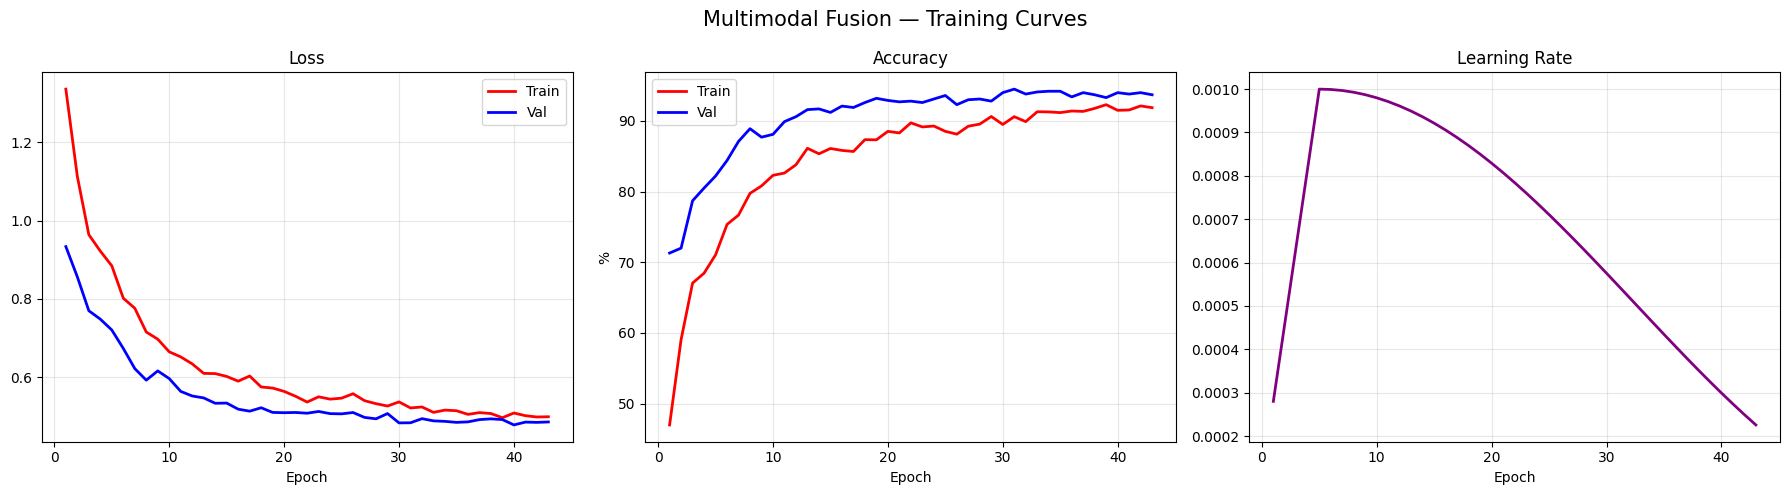

Saved: fusion_results/training_curves.png


In [8]:
# ==============================================================
# CELL 7 — TRAINING CURVES
# ==============================================================
 
def plot_training_curves(history, save_dir):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
    ep = range(1, len(history['train_loss']) + 1)
 
    axes[0].plot(ep, history['train_loss'], 'r-', lw=2, label='Train')
    axes[0].plot(ep, history['val_loss'],   'b-', lw=2, label='Val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
 
    axes[1].plot(ep, [a*100 for a in history['train_acc']], 'r-', lw=2, label='Train')
    axes[1].plot(ep, [a*100 for a in history['val_acc']],   'b-', lw=2, label='Val')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('%'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
 
    axes[2].plot(ep, history['lr'], color='purple', lw=2)
    axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch')
    axes[2].grid(True, alpha=0.3)
 
    plt.suptitle('Multimodal Fusion — Training Curves', fontsize=15)
    plt.tight_layout()
    path = os.path.join(save_dir, 'training_curves.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")
 
plot_training_curves(history, RESULTS_DIR)

Loaded best model  epoch=31  val_acc=94.50%

COMPREHENSIVE EVALUATION

  ALL AVAILABLE modalities : acc=94.50%  f1=0.945

  UNIMODAL BASELINES:
    emotion   : acc=53.20%  f1=0.528
    env       : acc=24.60%  f1=0.233
    health    : acc=51.90%  f1=0.484
    gesture   : acc=24.70%  f1=0.225
    speech    : acc=25.60%  f1=0.243

  MISSING-ONE ROBUSTNESS (remove each in turn):
    without emotion   : acc=49.40%  f1=0.489
    without env       : acc=94.50%  f1=0.945
    without health    : acc=51.20%  f1=0.511
    without gesture   : acc=93.90%  f1=0.939
    without speech    : acc=93.90%  f1=0.939

  CLASSIFICATION REPORT (all available modalities):
                 precision    recall  f1-score   support

         normal       0.96      0.94      0.95       250
needs_attention       0.93      0.92      0.92       250
     call_nurse       0.94      0.94      0.94       250
      emergency       0.95      0.98      0.97       250

       accuracy                           0.94      1000


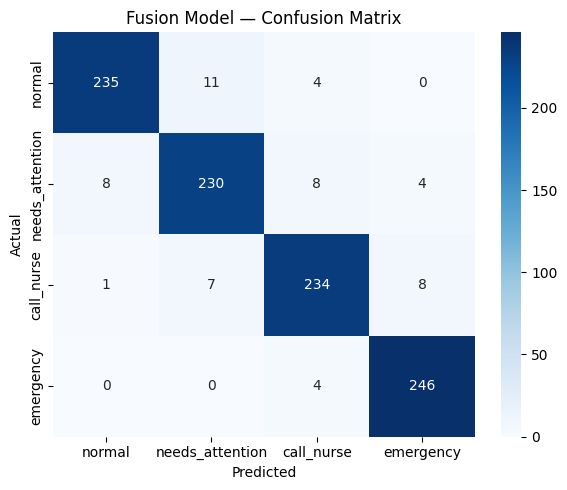

  Saved: fusion_results/confusion_matrix.png


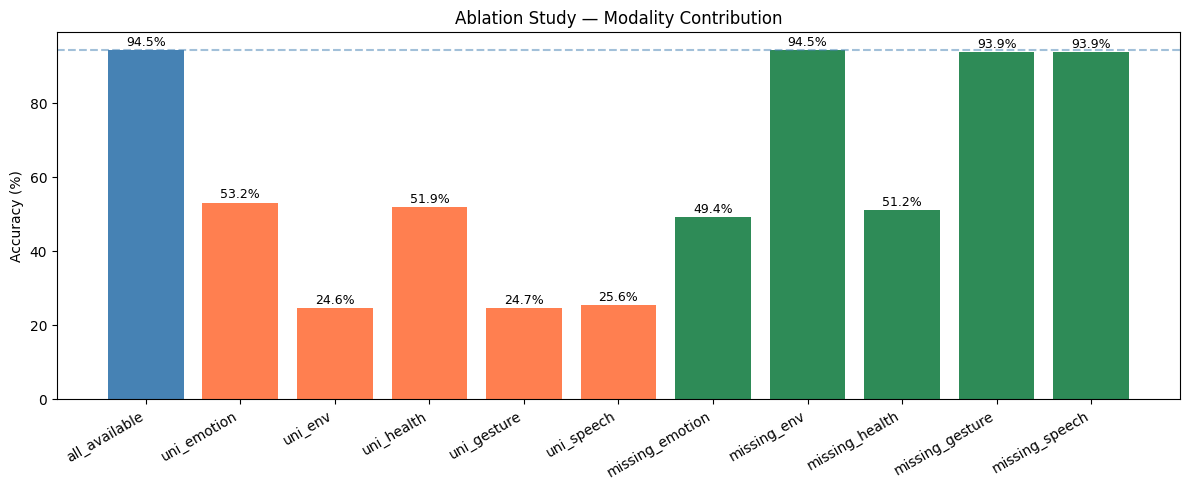

  Saved: fusion_results/ablation_study.png

  Results saved to fusion_results/eval_results.json


In [9]:
# ==============================================================
# CELL 8 — COMPREHENSIVE EVALUATION
# ==============================================================
 
def load_best_model():
    """Loads the best saved checkpoint."""
    ckpt  = torch.load(FUSION_SAVE_PATH, map_location=device)
    m     = MultimodalFusionModel().to(device)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    print(f"Loaded best model  epoch={ckpt['epoch']}  "
          f"val_acc={ckpt['val_acc']*100:.2f}%")
    return m
 
 
def evaluate_with_mask(model, test_loader, mask_override=None):
    """
    Evaluates model on loader.
    mask_override: if given, forces this fixed mask (e.g. to test specific subsets).
                   shape [5] — will be broadcast to every batch.
    """
    model.eval()
    all_preds, all_labels, all_weights = [], [], []
 
    with torch.no_grad():
        for batch in test_loader:
            batch = move_batch_to_device(batch, device)
            *embs, mask, labels = batch
 
            if mask_override is not None:
                # override the mask — zero out embeddings of missing modalities
                mo = mask_override.to(device)
                for i in range(NUM_MODALITIES):
                    if mo[i] == 0:
                        embs[i] = torch.zeros_like(embs[i])
                mask = mo.unsqueeze(0).expand(labels.size(0), -1).float()
 
            logits, weights = model(*embs, mask)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_weights.append(weights.cpu())
 
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1, all_preds, all_labels
 
 
def full_evaluation(model, val_loader):
    print(f"\n{'='*60}")
    print("COMPREHENSIVE EVALUATION")
    print(f"{'='*60}")
 
    results = {}
 
    # ── 1. Full fusion (all available modalities) ─────────────
    acc, f1, preds, labels = evaluate_with_mask(model, val_loader)
    results['all_available'] = (acc, f1)
    print(f"\n  ALL AVAILABLE modalities : acc={acc*100:.2f}%  f1={f1:.3f}")
 
    # ── 2. Unimodal baselines ─────────────────────────────────
    print(f"\n  UNIMODAL BASELINES:")
    for i, name in enumerate(MODALITY_NAMES):
        if not modality_available[i]:
            print(f"    {name:10s}: not available (skipped)")
            continue
        uni_mask = torch.zeros(NUM_MODALITIES)
        uni_mask[i] = 1.0
        acc_u, f1_u, _, _ = evaluate_with_mask(model, val_loader, uni_mask)
        results[f'uni_{name}'] = (acc_u, f1_u)
        print(f"    {name:10s}: acc={acc_u*100:.2f}%  f1={f1_u:.3f}")
 
    # ── 3. Missing-one robustness ─────────────────────────────
    print(f"\n  MISSING-ONE ROBUSTNESS (remove each in turn):")
    for i, name in enumerate(MODALITY_NAMES):
        if not modality_available[i]:
            continue
        miss_mask = torch.tensor([float(modality_available[j] and j != i)
                                   for j in range(NUM_MODALITIES)])
        acc_m, f1_m, _, _ = evaluate_with_mask(model, val_loader, miss_mask)
        results[f'missing_{name}'] = (acc_m, f1_m)
        print(f"    without {name:10s}: acc={acc_m*100:.2f}%  f1={f1_m:.3f}")
 
    # ── 4. Classification report ──────────────────────────────
    print(f"\n  CLASSIFICATION REPORT (all available modalities):")
    _, _, preds, labels = evaluate_with_mask(model, val_loader)
    print(classification_report(labels, preds, target_names=FUSION_CLASSES,
                                  zero_division=0))
 
    # ── 5. Confusion matrix ───────────────────────────────────
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=FUSION_CLASSES, yticklabels=FUSION_CLASSES, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title('Fusion Model — Confusion Matrix')
    plt.tight_layout()
    cm_path = os.path.join(RESULTS_DIR, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150); plt.show()
    print(f"  Saved: {cm_path}")
 
    # ── 6. Ablation bar chart ─────────────────────────────────
    labels_plot = ['all'] + \
                  [f'uni_{n}' for n in MODALITY_NAMES if modality_available[MODALITY_NAMES.index(n)]] + \
                  [f'miss_{n}' for n in MODALITY_NAMES if modality_available[MODALITY_NAMES.index(n)]]
    # filter to keys that exist
    labels_plot = [k for k in
                   (['all_available'] +
                    [f'uni_{n}'     for n in MODALITY_NAMES] +
                    [f'missing_{n}' for n in MODALITY_NAMES])
                   if k in results]
    accs_plot = [results[k][0] * 100 for k in labels_plot]
 
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(labels_plot, accs_plot, color=['steelblue'] + ['coral'] * 5 + ['seagreen'] * 5)
    ax.axhline(results['all_available'][0] * 100, color='steelblue', linestyle='--', alpha=0.5)
    ax.set_ylabel('Accuracy (%)'); ax.set_title('Ablation Study — Modality Contribution')
    ax.set_xticklabels(labels_plot, rotation=30, ha='right')
    for bar, acc in zip(bars, accs_plot):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    abl_path = os.path.join(RESULTS_DIR, 'ablation_study.png')
    plt.savefig(abl_path, dpi=150); plt.show()
    print(f"  Saved: {abl_path}")
 
    # ── Save results JSON ─────────────────────────────────────
    results_json = {k: {'acc': v[0], 'f1': v[1]} for k, v in results.items()}
    with open(os.path.join(RESULTS_DIR, 'eval_results.json'), 'w') as f:
        json.dump(results_json, f, indent=2)
    print(f"\n  Results saved to {RESULTS_DIR}/eval_results.json")
 
    return results
 
 
best_model = load_best_model()
eval_results = full_evaluation(best_model, val_loader)

In [10]:
# ==============================================================
# CELL 10 — INFERENCE PIPELINE
# ==============================================================
 
class FusionInference:
    """
    Production-ready inference pipeline.
 
    Usage (when you have pre-extracted embeddings):
        infer = FusionInference(model_path=FUSION_SAVE_PATH)
        result = infer.predict_from_embeddings(
            emotion_emb = torch.randn(1, 768),
            env_emb     = torch.randn(1, 512),
            health_emb  = torch.randn(1, 512),
            # gesture_emb and speech_emb are optional — omit or pass None
        )
        print(result)
    """
 
    def __init__(self, model_path=FUSION_SAVE_PATH):
        ckpt  = torch.load(model_path, map_location=device)
        self.model = MultimodalFusionModel().to(device)
        self.model.load_state_dict(ckpt['model_state'])
        self.model.eval()
        self.fusion_classes = ckpt.get('fusion_classes', FUSION_CLASSES)
        print(f"Inference pipeline ready ✅  (classes: {self.fusion_classes})")
 
    @torch.no_grad()
    def predict_from_embeddings(self,
                                 emotion_emb=None, env_emb=None, health_emb=None,
                                 gesture_emb=None, speech_emb=None):
        """
        Each argument: [1, D] float tensor, L2-normalised — or None if not available.
        Returns dict with action, confidence, per-class probabilities, attention weights.
        """
        raw = [emotion_emb, env_emb, health_emb, gesture_emb, speech_emb]
        embs = []
        mask = []
 
        for i, emb in enumerate(raw):
            if emb is not None:
                e = emb.float().to(device)
                # re-normalise in case it wasn't done upstream
                e = F.normalize(e, p=2, dim=1)
                embs.append(e)
                mask.append(1.0)
            else:
                embs.append(torch.zeros(1, MODALITY_DIMS[i]).to(device))
                mask.append(0.0)
 
        mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0).to(device)
        logits, attn_w = self.model(*embs, mask_t)
        probs  = F.softmax(logits, dim=1).squeeze(0).cpu()
        pred   = probs.argmax().item()
        conf   = probs[pred].item()
 
        return {
            'action':             self.fusion_classes[pred],
            'action_idx':         pred,
            'confidence':         round(conf, 4),
            'probabilities':      {cls: round(probs[i].item(), 4)
                                   for i, cls in enumerate(self.fusion_classes)},
            'attention_weights':  {MODALITY_NAMES[i]: round(attn_w[0, i].item(), 4)
                                   for i in range(NUM_MODALITIES)},
            'available_modalities': [MODALITY_NAMES[i] for i in range(NUM_MODALITIES)
                                     if mask[i] == 1.0],
        }
 
    def predict_action_text(self, result):
        """Human-readable response for the robot/agent."""
        action    = result['action']
        conf      = result['confidence']
        available = result['available_modalities']
 
        responses = {
            'normal':          "Patient appears calm and stable. Continuing routine monitoring.",
            'needs_attention': "Patient may need attention. Checking in now.",
            'call_nurse':      "Alerting nurse — patient requires assistance.",
            'emergency':       "⚠ EMERGENCY — calling for immediate medical help!",
        }
 
        text = responses.get(action, "Status unclear.")
        text += f" (confidence: {conf*100:.0f}%, using: {', '.join(available)})"
        return text
 
 
# ── Demo ──────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("INFERENCE DEMO")
print(f"{'='*60}")
 
infer = FusionInference(FUSION_SAVE_PATH)
 
# Scenario 1: All 3 modalities available
r1 = infer.predict_from_embeddings(
    emotion_emb = F.normalize(torch.randn(1, 768), p=2, dim=1),
    env_emb     = F.normalize(torch.randn(1, 512), p=2, dim=1),
    health_emb  = F.normalize(torch.randn(1, 512), p=2, dim=1),
)
print(f"\nScenario 1 (3 modalities): {r1['action']} ({r1['confidence']*100:.0f}%)")
print(f"  {infer.predict_action_text(r1)}")
 
# Scenario 2: Only emotion (camera only)
r2 = infer.predict_from_embeddings(
    emotion_emb = F.normalize(torch.randn(1, 768), p=2, dim=1),
)
print(f"\nScenario 2 (emotion only): {r2['action']} ({r2['confidence']*100:.0f}%)")
print(f"  {infer.predict_action_text(r2)}")
 
# Scenario 3: Emotion + health, no environment
r3 = infer.predict_from_embeddings(
    emotion_emb = F.normalize(torch.randn(1, 768), p=2, dim=1),
    health_emb  = F.normalize(torch.randn(1, 512), p=2, dim=1),
)
print(f"\nScenario 3 (emotion+health): {r3['action']} ({r3['confidence']*100:.0f}%)")
print(f"  {infer.predict_action_text(r3)}")
 
print(f"\n{'='*60}")
print("PIPELINE COMPLETE ✅")
print(f"{'='*60}")



INFERENCE DEMO
Inference pipeline ready ✅  (classes: ['normal', 'needs_attention', 'call_nurse', 'emergency'])

Scenario 1 (3 modalities): normal (90%)
  Patient appears calm and stable. Continuing routine monitoring. (confidence: 90%, using: emotion, env, health)

Scenario 2 (emotion only): emergency (54%)
  ⚠ EMERGENCY — calling for immediate medical help! (confidence: 54%, using: emotion)

Scenario 3 (emotion+health): needs_attention (78%)
  Patient may need attention. Checking in now. (confidence: 78%, using: emotion, health)

PIPELINE COMPLETE ✅


Fusion with 8 classes

In [16]:
# ==============================================================
# CELL 1 — IMPORTS & CONFIG
# ==============================================================

import os, json, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ── REPRODUCIBILITY ───────────────────────────────────────────
SEED = 42
def set_seed(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# ==============================================================
# ▼▼▼  EDIT ONLY THESE PATHS — NOTHING ELSE BELOW  ▼▼▼
# ==============================================================
EMOTION_EMB_PATH  = "emotion_embeddings.pt"
ENV_EMB_PATH      = "env_embeddings.pt"
HEALTH_EMB_PATH   = "health_embeddings.pt"
GESTURE_EMB_PATH  = "gesture_embeddings.pt"
SPEECH_EMB_PATH   = "speech_embeddings.pt"

FUSION_SAVE_PATH  = "best_fusion_model_8cls.pth"     # new name — won't overwrite 4-class
RESULTS_DIR       = "fusion_results_8cls"
# ==============================================================

os.makedirs(RESULTS_DIR, exist_ok=True)

# ── HYPERPARAMETERS ───────────────────────────────────────────
COMMON_DIM       = 256
NUM_CLASSES      = 8
BATCH_SIZE       = 64
EPOCHS           = 60
LR               = 1e-3
WEIGHT_DECAY     = 1e-4
LABEL_SMOOTH     = 0.1
MODALITY_DROP_P  = 0.15
NUM_PAIRS        = 8000    # more pairs — 8 classes need more coverage
VAL_SPLIT        = 0.20
PATIENCE         = 12
WARMUP_EPOCHS    = 5

# ── CLASS LABELS ──────────────────────────────────────────────
FUSION_CLASSES  = [
    'normal',           # 0
    'needs_attention',  # 1
    'call_nurse',       # 2
    'emergency',        # 3
    'agitated',         # 4
    'distressed_calm',  # 5
    'sudden_shock',     # 6
    'uncooperative',    # 7
]

EMOTION_CLASSES = ['angry','disgust','fear','happy','neutral','sad','surprise']
HEALTH_CLASSES  = ['baseline','stress','amusement','meditation']

# index shortcuts
_E = {c: i for i, c in enumerate(EMOTION_CLASSES)}
_H = {c: i for i, c in enumerate(HEALTH_CLASSES)}

MODALITY_DIMS  = [768, 512, 512, 512, 512]   # emotion, env, health, gesture, speech
MODALITY_NAMES = ['emotion', 'env', 'health', 'gesture', 'speech']
NUM_MODALITIES = 5

print(f"NUM_CLASSES     : {NUM_CLASSES}")
print(f"FUSION_CLASSES  : {FUSION_CLASSES}")
print(f"MODALITY_DIMS   : {MODALITY_DIMS}")

Device : cuda
NUM_CLASSES     : 8
FUSION_CLASSES  : ['normal', 'needs_attention', 'call_nurse', 'emergency', 'agitated', 'distressed_calm', 'sudden_shock', 'uncooperative']
MODALITY_DIMS   : [768, 512, 512, 512, 512]


In [17]:
# ==============================================================
# CELL 2 — LOAD & VALIDATE EMBEDDINGS
# ==============================================================

def load_embedding_file(path, name, expected_dim):
    if path is None:
        print(f"  [{name}] Not provided — will use zeros + mask=0 during training")
        return None
    if not os.path.exists(path):
        print(f"  [{name}] File not found: {path} — will use zeros + mask=0")
        return None

    data   = torch.load(path, map_location='cpu')
    embs   = data['embeddings'].float()
    labels = data['labels']

    assert embs.ndim == 2, f"{name}: expected 2D tensor, got {embs.ndim}D"
    assert embs.shape[1] == expected_dim, \
        f"{name}: expected dim {expected_dim}, got {embs.shape[1]}"

    if torch.isnan(embs).any() or torch.isinf(embs).any():
        raise ValueError(f"{name}: NaN or Inf found in embeddings!")

    norms = embs.norm(dim=1)
    max_deviation = (norms - 1.0).abs().max().item()
    if max_deviation > 0.02:
        print(f"  [{name}] WARNING: not L2-normalised (max dev={max_deviation:.4f}). Re-normalising.")
        embs = F.normalize(embs, p=2, dim=1)
    else:
        print(f"  [{name}] ✅ shape={tuple(embs.shape)}  norm_ok (max_dev={max_deviation:.4f})")

    return {'embeddings': embs, 'labels': labels,
            'classes': data.get('classes', [])}


print("\nLoading embeddings ...")
emotion_data  = load_embedding_file(EMOTION_EMB_PATH,  'emotion',  768)
env_data      = load_embedding_file(ENV_EMB_PATH,      'env',      512)
health_data   = load_embedding_file(HEALTH_EMB_PATH,   'health',   512)
gesture_data  = load_embedding_file(GESTURE_EMB_PATH,  'gesture',  512)
speech_data   = load_embedding_file(SPEECH_EMB_PATH,   'speech',   512)

all_data = [emotion_data, env_data, health_data, gesture_data, speech_data]

modality_available = [d is not None for d in all_data]
print(f"\nAvailable modalities: "
      f"{[n for n, a in zip(MODALITY_NAMES, modality_available) if a]}")


Loading embeddings ...
  [emotion] ✅ shape=(3068, 768)  norm_ok (max_dev=0.0000)
  [env] ✅ shape=(14700, 512)  norm_ok (max_dev=0.0000)
  [health] ✅ shape=(771, 512)  norm_ok (max_dev=0.0000)
  [gesture] WARNING: not L2-normalised (max dev=431.8635). Re-normalising.
  [speech] WARNING: not L2-normalised (max dev=20.5041). Re-normalising.

Available modalities: ['emotion', 'env', 'health', 'gesture', 'speech']


In [18]:
# ==============================================================
# CELL 3 — FUSION LABEL RULES + SYNTHETIC DATASET
# ==============================================================

HEALTH_TO_EMOTION_PROBS = {
    0: [0.05, 0.05, 0.05, 0.38, 0.35, 0.07, 0.05],  # baseline   → happy/neutral
    1: [0.20, 0.07, 0.22, 0.03, 0.08, 0.20, 0.20],  # stress     → angry/fear/sad
    2: [0.04, 0.03, 0.04, 0.42, 0.14, 0.05, 0.28],  # amusement  → happy/surprise
    3: [0.02, 0.02, 0.03, 0.14, 0.70, 0.06, 0.03],  # meditation → neutral
}

# ── Gesture index shortcuts ───────────────────────────────────
GESTURE_CLASSES = ['help','stop','yes','no','calm','attention','emergency','suspicious','cancel','unknown']
_G = {c: i for i, c in enumerate(GESTURE_CLASSES)}
GESTURE_DISTRESS  = {_G['help'], _G['emergency'], _G['attention']}
GESTURE_REFUSAL   = {_G['stop'], _G['no'], _G['cancel'], _G['suspicious']}
GESTURE_CALM      = {_G['yes'], _G['calm']}

# ── Speech index shortcuts ────────────────────────────────────
SPEECH_CLASSES = ['yes','no','stop','go','left','right','up','down','on','off']
_S = {c: i for i, c in enumerate(SPEECH_CLASSES)}
SPEECH_NEGATIVE = {_S['no'], _S['stop'], _S['off']}
SPEECH_POSITIVE = {_S['yes'], _S['go'], _S['on']}

# ── Environment groupings ─────────────────────────────────────
# env_idx here is the index within KEEP_CLASSES list order
# We group by category rather than exact index since there are 140 classes
# These are passed as the actual Places365 filtered label integer

MEDICAL_ENVS = {
    'hospital', 'hospital_room', 'nursing_home', 'operating_room',
    'waiting_room', 'clean_room', 'reception', 'pharmacy',
    'veterinarians_office'
}
RISKY_ENVS = {
    'staircase', 'corridor', 'street', 'crosswalk', 'construction_site',
    'fire_escape', 'parking_lot', 'parking_garage-indoor',
    'parking_garage-outdoor', 'elevator_shaft', 'alley', 'garage-indoor',
    'garage-outdoor'
}
CALM_ENVS = {
    'bedroom', 'living_room', 'park', 'home_office', 'recreation_room',
    'patio', 'yard', 'bedchamber', 'playroom', 'television_room'
}

# Build index→name lookup from KEEP_CLASSES defined in env notebook
# We pass env_class_name directly so we can do string lookup
def get_env_group(env_class_name):
    if env_class_name in MEDICAL_ENVS: return 'medical'
    if env_class_name in RISKY_ENVS:   return 'risky'
    if env_class_name in CALM_ENVS:    return 'calm'
    return 'neutral'


def assign_fusion_label(emotion_idx, health_idx,
                         gesture_idx=None, speech_idx=None, env_group=None):
    """
    Rule-based fusion label assignment using all 5 modalities.

    emotion  : 0=angry 1=disgust 2=fear 3=happy 4=neutral 5=sad 6=surprise
    health   : 0=baseline 1=stress 2=amusement 3=meditation
    gesture  : 0=help 1=stop 2=yes 3=no 4=calm 5=attention 6=emergency
               7=suspicious 8=cancel 9=unknown  — or None if unavailable
    speech   : 0=yes 1=no 2=stop 3=go 4=left 5=right 6=up 7=down 8=on 9=off
               — or None if unavailable
    env_group: 'medical' | 'risky' | 'calm' | 'neutral' | None

    Returns  : 0=normal  1=needs_attention  2=call_nurse  3=emergency
               4=agitated  5=distressed_calm  6=sudden_shock  7=uncooperative
    """

    # ── Precompute gesture/speech signals ─────────────────────
    ges_distress = (gesture_idx is not None and gesture_idx in GESTURE_DISTRESS)
    ges_refusal  = (gesture_idx is not None and gesture_idx in GESTURE_REFUSAL)
    ges_calm     = (gesture_idx is not None and gesture_idx in GESTURE_CALM)
    spe_negative = (speech_idx is not None and speech_idx in SPEECH_NEGATIVE)
    spe_positive = (speech_idx is not None and speech_idx in SPEECH_POSITIVE)
    in_medical   = (env_group == 'medical')
    in_risky     = (env_group == 'risky')
    in_calm      = (env_group == 'calm')

    # ══════════════════════════════════════════════════════════
    # CLASS 3 — EMERGENCY
    # Core: stress + fear/sad
    # Escalate to emergency faster if gesture/speech/env confirm
    # ══════════════════════════════════════════════════════════
    if health_idx == _H['stress'] and emotion_idx in [_E['fear'], _E['sad']]:
        return 3
    # Gesture alone can escalate call_nurse → emergency
    if ges_distress and health_idx == _H['stress']:
        return 3
    # In risky env: stress + any negative emotion is enough
    if in_risky and health_idx == _H['stress'] and \
       emotion_idx in [_E['fear'], _E['sad'], _E['angry'], _E['surprise']]:
        return 3

    # ══════════════════════════════════════════════════════════
    # CLASS 4 — AGITATED
    # Core: angry + stress
    # ══════════════════════════════════════════════════════════
    if health_idx == _H['stress'] and emotion_idx == _E['angry']:
        return 4
    # Gesture refusal + speech negative + stress → agitated even without angry face
    if health_idx == _H['stress'] and ges_refusal and spe_negative:
        return 4

    # ══════════════════════════════════════════════════════════
    # CLASS 6 — SUDDEN_SHOCK
    # Core: surprise + stress
    # ══════════════════════════════════════════════════════════
    if health_idx == _H['stress'] and emotion_idx == _E['surprise']:
        return 6
    # Risky env + stress + surprise gesture (help/attention) → sudden shock
    if in_risky and health_idx == _H['stress'] and ges_distress:
        return 6

    # ══════════════════════════════════════════════════════════
    # CLASS 2 — CALL_NURSE
    # Core: stress alone (no strong emotion confirmed)
    # Gesture distress alone can also trigger regardless of health
    # ══════════════════════════════════════════════════════════
    if health_idx == _H['stress']:
        return 2
    # Deliberate distress gesture overrides everything — person is asking for help
    if ges_distress:
        return 2
    # Fear + non-calm health state
    if emotion_idx == _E['fear'] and health_idx == _H['amusement']:
        return 2
    # Medical env + any negative emotion + speech negative → escalate to call_nurse
    if in_medical and emotion_idx in [_E['fear'], _E['sad'], _E['angry']] \
       and spe_negative:
        return 2

    # ══════════════════════════════════════════════════════════
    # CLASS 5 — DISTRESSED_CALM
    # Core: fear/sad + body calm
    # Calm env + calm gesture weakens it back to needs_attention
    # ══════════════════════════════════════════════════════════
    if emotion_idx in [_E['fear'], _E['sad']] and \
       health_idx in [_H['baseline'], _H['meditation']]:
        # If person is in calm env AND making calm gesture → probably just sad, needs_attention
        if in_calm and ges_calm:
            return 1
        return 5

    # ══════════════════════════════════════════════════════════
    # CLASS 7 — UNCOOPERATIVE
    # Core: angry/disgust + body calm
    # Medical env strengthens it — refusal of care is more significant there
    # ══════════════════════════════════════════════════════════
    if emotion_idx in [_E['angry'], _E['disgust']] and \
       health_idx in [_H['baseline'], _H['amusement']]:
        return 7
    # Even without emotion confirmed: refusal gesture + speech + medical env
    if in_medical and ges_refusal and spe_negative:
        return 7

    # ══════════════════════════════════════════════════════════
    # CLASS 1 — NEEDS_ATTENTION
    # Any remaining negative signal
    # ══════════════════════════════════════════════════════════
    if emotion_idx in [_E['angry'], _E['disgust'], _E['sad']]:
        return 1
    # Negative speech + negative gesture even without emotion → worth checking
    if spe_negative and ges_refusal:
        return 1
    # Medical env + neutral emotion → still worth flagging
    if in_medical and emotion_idx == _E['neutral']:
        return 1

    # ══════════════════════════════════════════════════════════
    # CLASS 0 — NORMAL
    # ══════════════════════════════════════════════════════════
    return 0


# ── Now FusionDataset needs to pass env_class_name to the label function ──

def build_emotion_class_indices(emotion_data):
    idx_by_class = {}
    for i, lbl in enumerate(emotion_data['labels'].tolist()):
        idx_by_class.setdefault(lbl, []).append(i)
    return idx_by_class

def build_health_class_indices(health_data):
    idx_by_class = {}
    for i, lbl in enumerate(health_data['labels'].tolist()):
        idx_by_class.setdefault(lbl, []).append(i)
    return idx_by_class


# KEEP_CLASSES from env model — must match exactly what env model was trained on
ENV_CLASS_NAMES = [
    'bathroom','bedroom','childs_room','clean_room','corridor',
    'hospital','hospital_room','kitchen','living_room','nursery',
    'nursing_home','operating_room','pharmacy','reception','shower',
    'staircase','utility_room','veterinarians_office','waiting_room',
    'alcove','attic','balcony-interior','basement','bedchamber',
    'bow_window-indoor','closet','dining_room','dorm_room',
    'dressing_room','home_office','home_theater','hotel_room',
    'jacuzzi-indoor','locker_room','pantry','patio','playroom',
    'porch','recreation_room','sauna','storage_room',
    'television_room','wet_bar','yard',
    'atrium-public','elevator-door','elevator_lobby','elevator_shaft',
    'entrance_hall','escalator-indoor','fire_escape','garage-indoor',
    'garage-outdoor','lawn','lobby','mezzanine',
    'parking_garage-indoor','parking_garage-outdoor','parking_lot',
    'roof_garden','street',
    'archive','auditorium','biology_laboratory','bookstore',
    'cafeteria','chemistry_lab','church-indoor','classroom',
    'computer_room','conference_center','conference_room','courthouse',
    'dining_hall','drugstore','fire_station','gymnasium-indoor',
    'kindergarden_classroom','lecture_room','library-indoor',
    'martial_arts_gym','museum-indoor','natural_history_museum',
    'office','office_building','office_cubicles','physics_laboratory',
    'schoolhouse','science_museum','server_room',
    'shopping_mall-indoor','subway_station-platform',
    'swimming_pool-indoor',
    'bakery-shop','beauty_salon','butchers_shop','candy_store',
    'clothing_store','coffee_shop','delicatessen','department_store',
    'fabric_store','fastfood_restaurant','florist_shop-indoor',
    'food_court','general_store-indoor','gift_shop','hardware_store',
    'ice_cream_parlor','jewelry_shop','laundromat','market-indoor',
    'pet_shop','pizzeria','restaurant','restaurant_kitchen',
    'shoe_shop','shopfront','supermarket','toyshop',
    'bus_interior','bus_station-indoor','car_interior','gas_station',
    'train_interior','train_station-platform',
    'alley','apartment_building-outdoor','balcony-exterior',
    'building_facade','campus','construction_site','courtyard',
    'crosswalk','doorway-outdoor','downtown','driveway','house',
    'mansion','park','picnic_area','playground','plaza',
    'promenade','residential_neighborhood','skyscraper','ticket_booth',
]


class FusionDataset(Dataset):
    def __init__(self, all_data, num_pairs, modality_available,
                 modality_drop_p=0.0, augment=False):
        self.all_data           = all_data
        self.modality_available = modality_available
        self.modality_drop_p    = modality_drop_p
        self.augment            = augment
        self.dims               = MODALITY_DIMS

        self.emotion_by_class = build_emotion_class_indices(all_data[0])
        self.health_by_class  = build_health_class_indices(all_data[2])

        self.pairs = self._generate_pairs(num_pairs)

        labels = [p[-1] for p in self.pairs]
        counts = Counter(labels)
        print(f"\nFusion dataset: {len(self.pairs)} pairs")
        for i, cls in enumerate(FUSION_CLASSES):
            bar = '█' * int(counts.get(i, 0) / len(self.pairs) * 30)
            print(f"  {cls:18s} ({i}): {counts.get(i,0):5d}  {bar}")

    def _generate_pairs(self, num_pairs):
        pairs = []
        n_env = len(self.all_data[1]['labels'])
        n_ges = len(self.all_data[3]['labels']) if self.all_data[3] else 0
        n_spe = len(self.all_data[4]['labels']) if self.all_data[4] else 0

        # Build gesture/speech label arrays for sampling
        ges_labels = self.all_data[3]['labels'].tolist() if self.all_data[3] else []
        spe_labels = self.all_data[4]['labels'].tolist() if self.all_data[4] else []
        env_labels = self.all_data[1]['labels'].tolist()

        pairs_per_class   = num_pairs // NUM_CLASSES
        health_class_list = list(self.health_by_class.keys())

        for target_fusion_label in range(NUM_CLASSES):
            generated    = 0
            max_attempts = pairs_per_class * 30
            attempts     = 0

            while generated < pairs_per_class and attempts < max_attempts:
                attempts += 1

                # ── Sample health ──────────────────────────────
                h_class = random.choice(health_class_list)
                h_idx   = random.choice(self.health_by_class[h_class])

                # ── Sample emotion correlated with health ──────
                probs   = HEALTH_TO_EMOTION_PROBS[h_class]
                e_class = int(np.random.choice(len(EMOTION_CLASSES), p=probs))
                if e_class not in self.emotion_by_class:
                    continue
                e_idx = random.choice(self.emotion_by_class[e_class])

                # ── Sample env ─────────────────────────────────
                env_idx        = random.randint(0, n_env - 1)
                env_label_idx  = env_labels[env_idx]
                env_class_name = ENV_CLASS_NAMES[env_label_idx] \
                                 if env_label_idx < len(ENV_CLASS_NAMES) else 'unknown'
                env_group      = get_env_group(env_class_name)

                # ── Sample gesture / speech ────────────────────
                ges_idx   = random.randint(0, n_ges - 1) if n_ges > 0 else -1
                spe_idx   = random.randint(0, n_spe - 1) if n_spe > 0 else -1
                g_class   = ges_labels[ges_idx] if ges_idx >= 0 else None
                s_class   = spe_labels[spe_idx] if spe_idx >= 0 else None

                # ── Compute label using all 5 ──────────────────
                label = assign_fusion_label(
                    e_class, h_class,
                    gesture_idx=g_class,
                    speech_idx=s_class,
                    env_group=env_group
                )

                if label != target_fusion_label:
                    continue

                pairs.append((e_idx, env_idx, h_idx, ges_idx, spe_idx, label))
                generated += 1

            if generated < pairs_per_class:
                print(f"  WARNING: '{FUSION_CLASSES[target_fusion_label]}' "
                      f"only got {generated}/{pairs_per_class} pairs")

        random.shuffle(pairs)
        return pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        e_idx, env_idx, h_idx, ges_idx, spe_idx, label = self.pairs[idx]

        sample_indices = [e_idx, env_idx, h_idx, ges_idx, spe_idx]
        embs = []
        mask = []

        for i, (avail, s_idx) in enumerate(zip(self.modality_available, sample_indices)):
            dim = self.dims[i]
            if avail and s_idx >= 0:
                emb = self.all_data[i]['embeddings'][s_idx].clone()
                if self.augment:
                    emb = emb + torch.randn_like(emb) * 0.01
                    emb = F.normalize(emb, p=2, dim=0)
                embs.append(emb)
                mask.append(1.0)
            else:
                embs.append(torch.zeros(dim))
                mask.append(0.0)

        mask_tensor = torch.tensor(mask, dtype=torch.float32)

        if self.modality_drop_p > 0.0:
            for i in range(NUM_MODALITIES):
                if mask_tensor[i] == 1.0:
                    if random.random() < self.modality_drop_p:
                        embs[i]        = torch.zeros(self.dims[i])
                        mask_tensor[i] = 0.0
            if mask_tensor.sum() == 0:
                for i in range(NUM_MODALITIES):
                    if self.modality_available[i]:
                        embs[i] = self.all_data[i]['embeddings'][sample_indices[i]].clone()
                        mask_tensor[i] = 1.0
                        break

        return (*embs, mask_tensor, torch.tensor(label, dtype=torch.long))


def build_dataloaders(all_data, modality_available):
    full_ds = FusionDataset(all_data, NUM_PAIRS, modality_available,
                            modality_drop_p=MODALITY_DROP_P, augment=True)

    n_val   = int(len(full_ds) * VAL_SPLIT)
    n_train = len(full_ds) - n_val

    gen = torch.Generator().manual_seed(SEED)
    train_ds, _ = torch.utils.data.random_split(full_ds, [n_train, n_val], generator=gen)

    val_full = FusionDataset(all_data, int(NUM_PAIRS * VAL_SPLIT),
                             modality_available, modality_drop_p=0.0, augment=False)

    train_labels   = [full_ds.pairs[i][-1] for i in train_ds.indices]
    class_counts   = Counter(train_labels)
    class_weights  = {c: 1.0 / max(class_counts[c], 1) for c in range(NUM_CLASSES)}
    sample_weights = [class_weights[lbl] for lbl in train_labels]
    sampler = WeightedRandomSampler(
        weights=sample_weights, num_samples=len(sample_weights), replacement=True
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_full, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

    print(f"\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}")
    return train_loader, val_loader


print("\nBuilding datasets ...")
train_loader, val_loader = build_dataloaders(all_data, modality_available)


Building datasets ...

Fusion dataset: 8000 pairs
  normal             (0):  1000  ███
  needs_attention    (1):  1000  ███
  call_nurse         (2):  1000  ███
  emergency          (3):  1000  ███
  agitated           (4):  1000  ███
  distressed_calm    (5):  1000  ███
  sudden_shock       (6):  1000  ███
  uncooperative      (7):  1000  ███

Fusion dataset: 1600 pairs
  normal             (0):   200  ███
  needs_attention    (1):   200  ███
  call_nurse         (2):   200  ███
  emergency          (3):   200  ███
  agitated           (4):   200  ███
  distressed_calm    (5):   200  ███
  sudden_shock       (6):   200  ███
  uncooperative      (7):   200  ███

Train batches: 100 | Val batches: 25


In [19]:
# ==============================================================
# CELL 4 — FUSION MODEL ARCHITECTURE
# ==============================================================

class ModalityProjection(nn.Module):
    def __init__(self, input_dim, output_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class MultimodalFusionModel(nn.Module):
    def __init__(self, modality_dims=MODALITY_DIMS,
                 common_dim=COMMON_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.common_dim     = common_dim
        self.num_modalities = len(modality_dims)

        self.projections = nn.ModuleList([
            ModalityProjection(d, common_dim, dropout=0.2)
            for d in modality_dims
        ])

        self.attention = nn.Sequential(
            nn.Linear(common_dim * self.num_modalities, common_dim),
            nn.GELU(),
            nn.Linear(common_dim, self.num_modalities),
        )

        fusion_in = common_dim * self.num_modalities
        self.fusion_head = nn.Sequential(
            nn.Linear(fusion_in, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, *args):
        *embs, mask = args
        B = embs[0].shape[0]

        projs   = [self.projections[i](embs[i]) for i in range(self.num_modalities)]
        stacked = torch.stack(projs, dim=1)           # [B, 5, 256]
        stacked = stacked * mask.unsqueeze(2)

        flat        = stacked.view(B, -1)
        attn_logits = self.attention(flat)
        attn_logits = attn_logits.masked_fill(mask == 0, float('-inf'))
        attn_weights = F.softmax(attn_logits, dim=1)
        attn_weights = torch.nan_to_num(attn_weights, nan=0.0)

        weighted = stacked * attn_weights.unsqueeze(2)
        fused    = weighted.view(B, -1)
        logits   = self.fusion_head(fused)

        return logits, attn_weights


model = MultimodalFusionModel().to(device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nFusion model (8-class)")
print(f"  Total params    : {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Input dims      : {MODALITY_DIMS}")
print(f"  Common dim      : {COMMON_DIM}")
print(f"  Output classes  : {FUSION_CLASSES}")

with torch.no_grad():
    dummy_embs = [torch.randn(2, d).to(device) for d in MODALITY_DIMS]
    dummy_mask = torch.ones(2, NUM_MODALITIES).to(device)
    out, w = model(*dummy_embs, dummy_mask)
    assert out.shape == (2, NUM_CLASSES), f"Unexpected output shape: {out.shape}"
    assert w.shape   == (2, NUM_MODALITIES)
    print("  Sanity check    : ✅ forward pass OK")


Fusion model (8-class)
  Total params    : 1,844,749
  Trainable params: 1,844,749
  Input dims      : [768, 512, 512, 512, 512]
  Common dim      : 256
  Output classes  : ['normal', 'needs_attention', 'call_nurse', 'emergency', 'agitated', 'distressed_calm', 'sudden_shock', 'uncooperative']
  Sanity check    : ✅ forward pass OK


In [20]:
# ==============================================================
# CELL 5 — LOSS, OPTIMIZER, SCHEDULER
# ==============================================================

def compute_class_weights(train_loader, num_classes):
    all_labels = []
    for batch in train_loader:
        all_labels.extend(batch[-1].tolist())
    counts  = Counter(all_labels)
    total   = sum(counts.values())
    weights = torch.tensor(
        [total / (num_classes * max(counts.get(i, 1), 1)) for i in range(num_classes)],
        dtype=torch.float32
    )
    weights = weights / weights.sum() * num_classes
    print(f"\nClass weights:")
    for i in range(num_classes):
        print(f"  {FUSION_CLASSES[i]:18s}: {weights[i]:.3f}")
    return weights.to(device)

class_weights = compute_class_weights(train_loader, NUM_CLASSES)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler    = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=LR * 0.01)
scheduler = SequentialLR(optimizer, [warmup_scheduler, cosine_scheduler],
                          milestones=[WARMUP_EPOCHS])


Class weights:
  normal            : 1.007
  needs_attention   : 1.028
  call_nurse        : 1.041
  emergency         : 1.017
  agitated          : 0.968
  distressed_calm   : 0.909
  sudden_shock      : 1.017
  uncooperative     : 1.012


In [ ]:
# ==============================================================
# CELL 6 — TRAINING LOOP
# ==============================================================

def move_batch_to_device(batch, device):
    return [t.to(device) for t in batch]

def run_epoch(model, loader, criterion, optimizer, is_train, scaler=None):
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch  = move_batch_to_device(batch, device)
            *embs, mask, labels = batch

            if is_train:
                optimizer.zero_grad()

            with torch.amp.autocast(device_type=device.type,
                                    enabled=(device.type == 'cuda')):
                logits, _ = model(*embs, mask)
                loss = criterion(logits, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            preds = logits.argmax(dim=1)
            total_loss += loss.item() * labels.size(0)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    return total_loss / total, correct / total, all_preds, all_labels


def train_fusion_model(model, train_loader, val_loader, criterion, optimizer, scheduler):
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  [], 'lr': []}

    best_val_acc = 0.0
    best_epoch   = 0
    patience_ctr = 0

    print(f"\n{'='*60}")
    print(f"TRAINING FUSION MODEL 8-CLASS  ({EPOCHS} epochs)")
    print(f"{'='*60}")

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc, _, _ = run_epoch(
            model, train_loader, criterion, optimizer, True, scaler)

        va_loss, va_acc, va_preds, va_labels = run_epoch(
            model, val_loader, criterion, optimizer=None, is_train=False, scaler=None)

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        history['lr'].append(current_lr)

        f1 = f1_score(va_labels, va_preds, average='macro', zero_division=0)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_epoch   = epoch
            torch.save({
                'epoch':          epoch,
                'model_state':    model.state_dict(),
                'optimizer':      optimizer.state_dict(),
                'val_acc':        va_acc,
                'val_f1':         f1,
                'fusion_classes': FUSION_CLASSES,
                'modality_dims':  MODALITY_DIMS,
                'common_dim':     COMMON_DIM,
            }, FUSION_SAVE_PATH)
            ckpt_flag    = ' ← best'
            patience_ctr = 0
        else:
            ckpt_flag    = ''
            patience_ctr += 1

        print(f"  Ep {epoch:3d}/{EPOCHS} | "
              f"TrLoss {tr_loss:.4f} TrAcc {tr_acc*100:.1f}% | "
              f"VaLoss {va_loss:.4f} VaAcc {va_acc*100:.1f}% "
              f"F1 {f1:.3f} | LR {current_lr:.2e}{ckpt_flag}")

        if patience_ctr >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch} "
                  f"(no improvement for {PATIENCE} epochs)")
            break

    print(f"\n  Best val accuracy : {best_val_acc*100:.2f}%  (epoch {best_epoch})")
    print(f"  Saved to          : {FUSION_SAVE_PATH}")
    return history


# ── Reinitialise model, optimizer, scheduler from scratch ─────
model         = MultimodalFusionModel().to(device)
class_weights = compute_class_weights(train_loader, NUM_CLASSES)
criterion     = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)
optimizer     = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler        = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=LR * 0.01)
scheduler     = SequentialLR(optimizer, [warmup_scheduler, cosine_scheduler],
                              milestones=[WARMUP_EPOCHS])

history = train_fusion_model(model, train_loader, val_loader, criterion, optimizer, scheduler)


Class weights:
  normal            : 1.062
  needs_attention   : 1.004
  call_nurse        : 0.986
  emergency         : 0.994
  agitated          : 0.968
  distressed_calm   : 0.973
  sudden_shock      : 1.016
  uncooperative     : 0.998

TRAINING FUSION MODEL 8-CLASS  (60 epochs)
  Ep   1/60 | TrLoss 1.9364 TrAcc 34.6% | VaLoss 1.2779 VaAcc 63.2% F1 0.627 | LR 2.80e-04 ← best
  Ep   2/60 | TrLoss 1.5468 TrAcc 51.4% | VaLoss 1.1349 VaAcc 70.9% F1 0.707 | LR 4.60e-04 ← best
  Ep   3/60 | TrLoss 1.3886 TrAcc 58.6% | VaLoss 1.0573 VaAcc 74.1% F1 0.740 | LR 6.40e-04 ← best
  Ep   4/60 | TrLoss 1.2822 TrAcc 64.1% | VaLoss 0.9593 VaAcc 79.8% F1 0.796 | LR 8.20e-04 ← best


In [ ]:
# ==============================================================
# CELL 6.5 — SAVE TORCHSCRIPT .pt MODEL
# ==============================================================

def save_torchscript_model(model, save_path="best_fusion_model_8cls.pt"):
    model.eval()
    dummy_embs = [torch.zeros(1, d).to(device) for d in MODALITY_DIMS]
    dummy_mask = torch.ones(1, NUM_MODALITIES).to(device)

    try:
        scripted = torch.jit.trace(model, (*dummy_embs, dummy_mask))
        scripted.save(save_path)
        print(f"TorchScript model saved → {save_path}")
    except Exception as e:
        print(f"TorchScript trace failed ({e}), falling back to torch.save")
        torch.save(model, save_path)
        print(f"Full model saved → {save_path}")

best_ckpt = torch.load(FUSION_SAVE_PATH, map_location=device)
best_model_for_script = MultimodalFusionModel().to(device)
best_model_for_script.load_state_dict(best_ckpt['model_state'])
best_model_for_script.eval()

save_torchscript_model(best_model_for_script, "best_fusion_model_8cls.pt")
print("Both formats saved:")
print("  best_fusion_model_8cls.pth  ← reloading / continual learning")
print("  best_fusion_model_8cls.pt   ← deployment / real-time inference")

TorchScript model saved → best_fusion_model_8cls.pt
Both formats saved:
  best_fusion_model_8cls.pth  ← reloading / continual learning
  best_fusion_model_8cls.pt   ← deployment / real-time inference


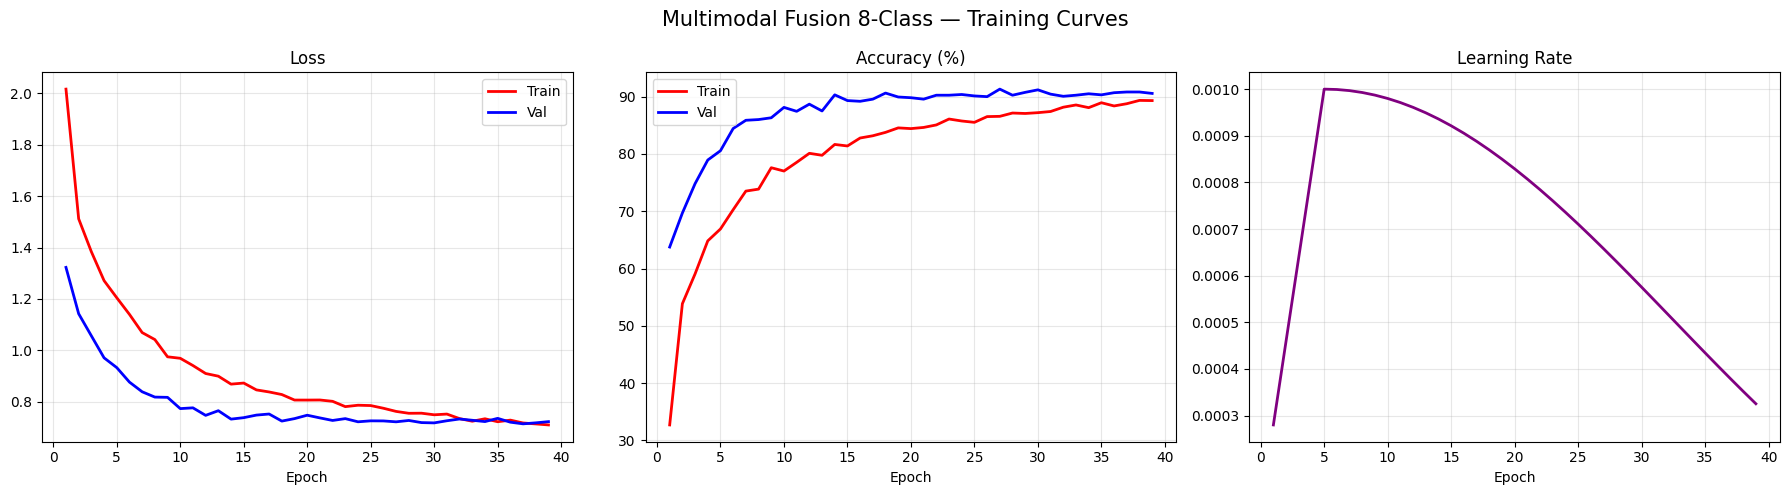

Saved: fusion_results_8cls/training_curves.png


In [ ]:
# ==============================================================
# CELL 7 — TRAINING CURVES
# ==============================================================

def plot_training_curves(history, save_dir):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ep = range(1, len(history['train_loss']) + 1)

    axes[0].plot(ep, history['train_loss'], 'r-', lw=2, label='Train')
    axes[0].plot(ep, history['val_loss'],   'b-', lw=2, label='Val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, [a*100 for a in history['train_acc']], 'r-', lw=2, label='Train')
    axes[1].plot(ep, [a*100 for a in history['val_acc']],   'b-', lw=2, label='Val')
    axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(ep, history['lr'], color='purple', lw=2)
    axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch')
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('Multimodal Fusion 8-Class — Training Curves', fontsize=15)
    plt.tight_layout()
    path = os.path.join(save_dir, 'training_curves.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

plot_training_curves(history, RESULTS_DIR)

Loaded best model  epoch=27  val_acc=91.31%

COMPREHENSIVE EVALUATION — 8-CLASS FUSION

  ALL AVAILABLE modalities : acc=91.31%  f1=0.912

  UNIMODAL BASELINES:
    emotion   : acc=47.62%  f1=0.438
    env       : acc=12.19%  f1=0.115
    health    : acc=28.75%  f1=0.245
    gesture   : acc=21.56%  f1=0.170
    speech    : acc=13.31%  f1=0.080

  MISSING-ONE ROBUSTNESS:
    without emotion   : acc=46.19%  f1=0.465
    without env       : acc=90.50%  f1=0.903
    without health    : acc=63.75%  f1=0.632
    without gesture   : acc=74.44%  f1=0.734
    without speech    : acc=88.12%  f1=0.880

  CLASSIFICATION REPORT:
                 precision    recall  f1-score   support

         normal       0.91      0.85      0.88       200
needs_attention       0.82      0.76      0.79       200
     call_nurse       0.98      0.91      0.94       200
      emergency       0.95      0.92      0.94       200
       agitated       0.94      0.99      0.97       200
distressed_calm       0.89      0

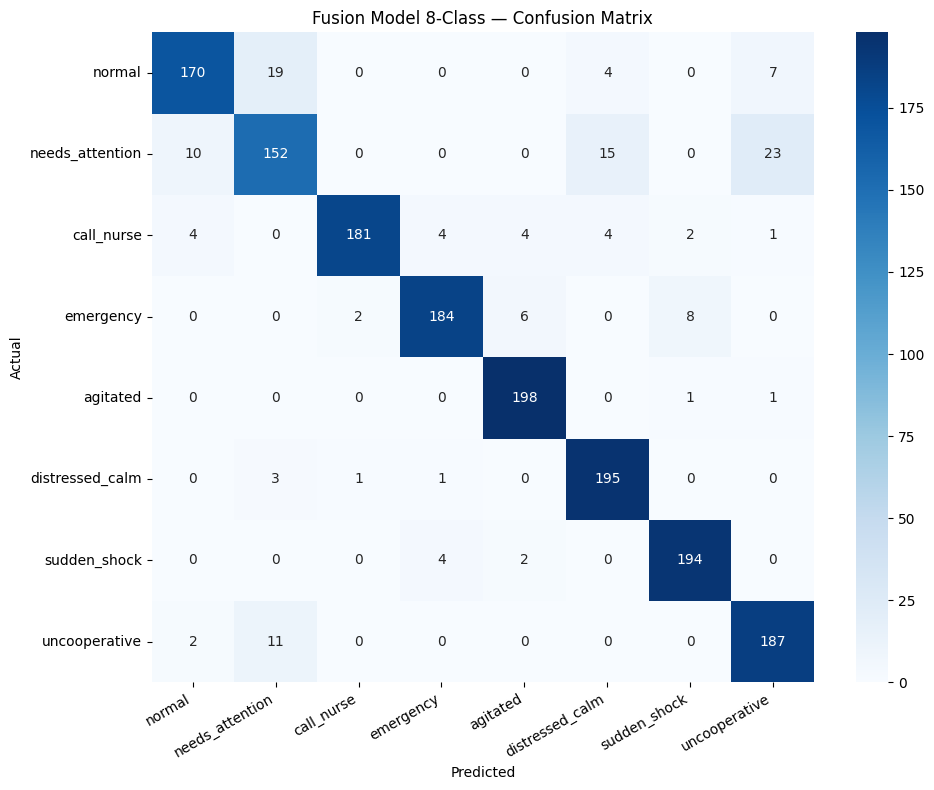

  Saved: fusion_results_8cls/confusion_matrix.png


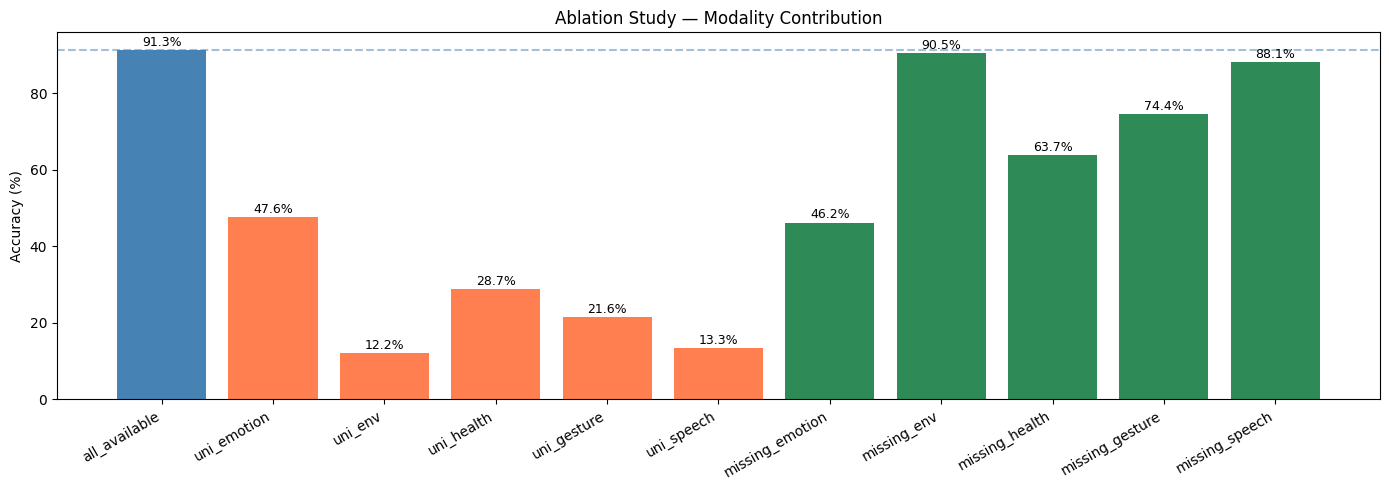

  Saved: fusion_results_8cls/ablation_study.png


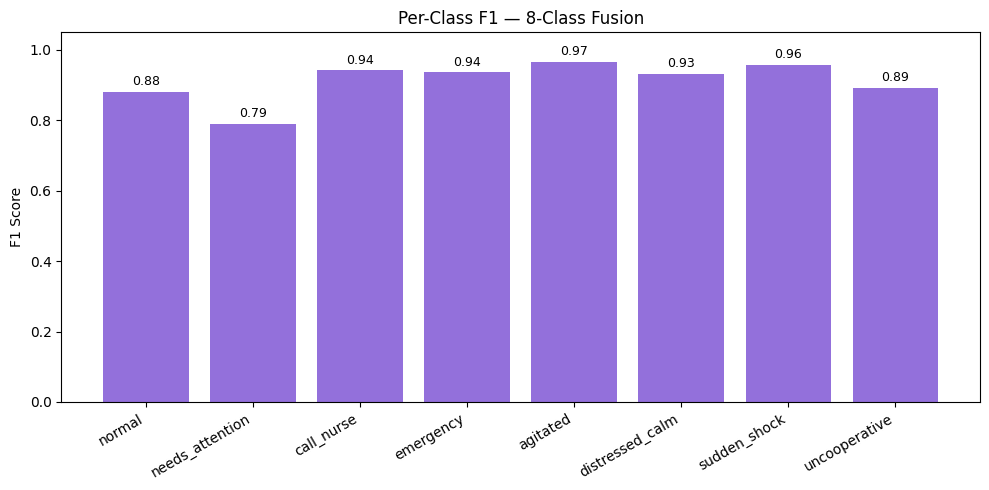

  Saved: fusion_results_8cls/per_class_f1.png

  Results saved to fusion_results_8cls/eval_results.json


In [ ]:
# ==============================================================
# CELL 8 — COMPREHENSIVE EVALUATION
# ==============================================================

def load_best_model():
    ckpt = torch.load(FUSION_SAVE_PATH, map_location=device)
    m    = MultimodalFusionModel().to(device)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    print(f"Loaded best model  epoch={ckpt['epoch']}  "
          f"val_acc={ckpt['val_acc']*100:.2f}%")
    return m


def evaluate_with_mask(model, test_loader, mask_override=None):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            batch = move_batch_to_device(batch, device)
            *embs, mask, labels = batch

            if mask_override is not None:
                mo = mask_override.to(device)
                for i in range(NUM_MODALITIES):
                    if mo[i] == 0:
                        embs[i] = torch.zeros_like(embs[i])
                mask = mo.unsqueeze(0).expand(labels.size(0), -1).float()

            logits, _ = model(*embs, mask)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1, all_preds, all_labels


def full_evaluation(model, val_loader):
    print(f"\n{'='*60}")
    print("COMPREHENSIVE EVALUATION — 8-CLASS FUSION")
    print(f"{'='*60}")

    results = {}

    # ── 1. All available modalities ───────────────────────────
    acc, f1, preds, labels = evaluate_with_mask(model, val_loader)
    results['all_available'] = (acc, f1)
    print(f"\n  ALL AVAILABLE modalities : acc={acc*100:.2f}%  f1={f1:.3f}")

    # ── 2. Unimodal baselines ─────────────────────────────────
    print(f"\n  UNIMODAL BASELINES:")
    for i, name in enumerate(MODALITY_NAMES):
        if not modality_available[i]:
            print(f"    {name:10s}: not available (skipped)")
            continue
        uni_mask = torch.zeros(NUM_MODALITIES)
        uni_mask[i] = 1.0
        acc_u, f1_u, _, _ = evaluate_with_mask(model, val_loader, uni_mask)
        results[f'uni_{name}'] = (acc_u, f1_u)
        print(f"    {name:10s}: acc={acc_u*100:.2f}%  f1={f1_u:.3f}")

    # ── 3. Missing-one robustness ─────────────────────────────
    print(f"\n  MISSING-ONE ROBUSTNESS:")
    for i, name in enumerate(MODALITY_NAMES):
        if not modality_available[i]:
            continue
        miss_mask = torch.tensor([float(modality_available[j] and j != i)
                                   for j in range(NUM_MODALITIES)])
        acc_m, f1_m, _, _ = evaluate_with_mask(model, val_loader, miss_mask)
        results[f'missing_{name}'] = (acc_m, f1_m)
        print(f"    without {name:10s}: acc={acc_m*100:.2f}%  f1={f1_m:.3f}")

    # ── 4. Classification report ──────────────────────────────
    print(f"\n  CLASSIFICATION REPORT:")
    _, _, preds, labels = evaluate_with_mask(model, val_loader)
    print(classification_report(labels, preds, target_names=FUSION_CLASSES,
                                  zero_division=0))

    # ── 5. Confusion matrix ───────────────────────────────────
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(10, 8))   # larger for 8 classes
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=FUSION_CLASSES, yticklabels=FUSION_CLASSES, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title('Fusion Model 8-Class — Confusion Matrix')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    cm_path = os.path.join(RESULTS_DIR, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150); plt.show()
    print(f"  Saved: {cm_path}")

    # ── 6. Ablation bar chart ─────────────────────────────────
    labels_plot = [k for k in
                   (['all_available'] +
                    [f'uni_{n}'     for n in MODALITY_NAMES] +
                    [f'missing_{n}' for n in MODALITY_NAMES])
                   if k in results]
    accs_plot = [results[k][0] * 100 for k in labels_plot]

    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ['steelblue'] + ['coral'] * 5 + ['seagreen'] * 5
    bars = ax.bar(labels_plot, accs_plot, color=colors[:len(labels_plot)])
    ax.axhline(results['all_available'][0] * 100,
               color='steelblue', linestyle='--', alpha=0.5)
    ax.set_ylabel('Accuracy (%)'); ax.set_title('Ablation Study — Modality Contribution')
    ax.set_xticklabels(labels_plot, rotation=30, ha='right')
    for bar, acc in zip(bars, accs_plot):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    abl_path = os.path.join(RESULTS_DIR, 'ablation_study.png')
    plt.savefig(abl_path, dpi=150); plt.show()
    print(f"  Saved: {abl_path}")

    # ── 7. Per-class F1 bar chart (new — 8 classes warrant this) ──
    report = classification_report(labels, preds, target_names=FUSION_CLASSES,
                                    zero_division=0, output_dict=True)
    per_class_f1 = [report[cls]['f1-score'] for cls in FUSION_CLASSES]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(FUSION_CLASSES, per_class_f1, color='mediumpurple')
    ax.set_ylabel('F1 Score'); ax.set_title('Per-Class F1 — 8-Class Fusion')
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(FUSION_CLASSES, rotation=30, ha='right')
    for bar, f1v in zip(bars, per_class_f1):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{f1v:.2f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    f1_path = os.path.join(RESULTS_DIR, 'per_class_f1.png')
    plt.savefig(f1_path, dpi=150); plt.show()
    print(f"  Saved: {f1_path}")

    # ── Save results JSON ─────────────────────────────────────
    results_json = {k: {'acc': v[0], 'f1': v[1]} for k, v in results.items()}
    with open(os.path.join(RESULTS_DIR, 'eval_results.json'), 'w') as f:
        json.dump(results_json, f, indent=2)
    print(f"\n  Results saved to {RESULTS_DIR}/eval_results.json")

    return results


best_model   = load_best_model()
eval_results = full_evaluation(best_model, val_loader)

In [ ]:
# ==============================================================
# CELL 9 — INFERENCE PIPELINE
# ==============================================================

class FusionInference:
    def __init__(self, model_path=FUSION_SAVE_PATH):
        ckpt  = torch.load(model_path, map_location=device)
        self.model = MultimodalFusionModel().to(device)
        self.model.load_state_dict(ckpt['model_state'])
        self.model.eval()
        self.fusion_classes = ckpt.get('fusion_classes', FUSION_CLASSES)
        print(f"Inference pipeline ready ✅  (classes: {self.fusion_classes})")

    @torch.no_grad()
    def predict_from_embeddings(self,
                                 emotion_emb=None, env_emb=None, health_emb=None,
                                 gesture_emb=None, speech_emb=None):
        raw  = [emotion_emb, env_emb, health_emb, gesture_emb, speech_emb]
        embs = []
        mask = []

        for i, emb in enumerate(raw):
            if emb is not None:
                e = emb.float().to(device)
                e = F.normalize(e, p=2, dim=1)
                embs.append(e)
                mask.append(1.0)
            else:
                embs.append(torch.zeros(1, MODALITY_DIMS[i]).to(device))
                mask.append(0.0)

        mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0).to(device)
        logits, attn_w = self.model(*embs, mask_t)
        probs  = F.softmax(logits, dim=1).squeeze(0).cpu()
        pred   = probs.argmax().item()
        conf   = probs[pred].item()

        return {
            'action':             self.fusion_classes[pred],
            'action_idx':         pred,
            'confidence':         round(conf, 4),
            'probabilities':      {cls: round(probs[i].item(), 4)
                                   for i, cls in enumerate(self.fusion_classes)},
            'attention_weights':  {MODALITY_NAMES[i]: round(attn_w[0, i].item(), 4)
                                   for i in range(NUM_MODALITIES)},
            'available_modalities': [MODALITY_NAMES[i] for i in range(NUM_MODALITIES)
                                     if mask[i] == 1.0],
        }

    def predict_action_text(self, result):
        action = result['action']
        conf   = result['confidence']
        available = result['available_modalities']

        responses = {
            'normal':           "Patient appears calm and stable. Continuing routine monitoring.",
            'needs_attention':  "Patient may need a check-in. Approaching now.",
            'call_nurse':       "Alerting nurse — patient requires assistance.",
            'emergency':        "EMERGENCY — calling for immediate medical help!",
            'agitated':         "Patient is agitated. Alerting staff for de-escalation.",
            'distressed_calm':  "Patient shows emotional distress without physical stress. Flagging for mental health check-in.",
            'sudden_shock':     "Sudden change detected — checking on patient immediately.",
            'uncooperative':    "Patient appears to be refusing care. Notifying staff.",
        }

        text  = responses.get(action, "Status unclear.")
        text += f" (confidence: {conf*100:.0f}%, using: {', '.join(available)})"
        return text


# ── Demo ──────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("INFERENCE DEMO — 8-CLASS FUSION")
print(f"{'='*60}")

infer = FusionInference(FUSION_SAVE_PATH)

# Scenario 1: All 5 modalities
r1 = infer.predict_from_embeddings(
    emotion_emb = F.normalize(torch.randn(1, 768), p=2, dim=1),
    env_emb     = F.normalize(torch.randn(1, 512), p=2, dim=1),
    health_emb  = F.normalize(torch.randn(1, 512), p=2, dim=1),
    gesture_emb = F.normalize(torch.randn(1, 512), p=2, dim=1),
    speech_emb  = F.normalize(torch.randn(1, 512), p=2, dim=1),
)
print(f"\nScenario 1 (all 5): {r1['action']} ({r1['confidence']*100:.0f}%)")
print(f"  {infer.predict_action_text(r1)}")

# Scenario 2: Only emotion + health (camera + wearable, no gesture/speech)
r2 = infer.predict_from_embeddings(
    emotion_emb = F.normalize(torch.randn(1, 768), p=2, dim=1),
    health_emb  = F.normalize(torch.randn(1, 512), p=2, dim=1),
)
print(f"\nScenario 2 (emotion+health only): {r2['action']} ({r2['confidence']*100:.0f}%)")
print(f"  {infer.predict_action_text(r2)}")

# Scenario 3: Only gesture (robot sees a hand signal, nothing else)
r3 = infer.predict_from_embeddings(
    gesture_emb = F.normalize(torch.randn(1, 512), p=2, dim=1),
)
print(f"\nScenario 3 (gesture only): {r3['action']} ({r3['confidence']*100:.0f}%)")
print(f"  {infer.predict_action_text(r3)}")


INFERENCE DEMO — 8-CLASS FUSION
Inference pipeline ready ✅  (classes: ['normal', 'needs_attention', 'call_nurse', 'emergency', 'agitated', 'distressed_calm', 'sudden_shock', 'uncooperative'])

Scenario 1 (all 5): emergency (41%)
  EMERGENCY — calling for immediate medical help! (confidence: 41%, using: emotion, env, health, gesture, speech)

Scenario 2 (emotion+health only): call_nurse (70%)
  Alerting nurse — patient requires assistance. (confidence: 70%, using: emotion, health)

Scenario 3 (gesture only): emergency (47%)
  EMERGENCY — calling for immediate medical help! (confidence: 47%, using: gesture)
